In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1

#     language: python
#     name: python3
# ---

# Phần 2: Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection
#
**Dataset:** IEEE-CIS Fraud Detection
- `train_transaction.csv`, `train_identity.csv`
- `test_transaction.csv`, `test_identity.csv`
- Bài toán phân loại nhị phân: dự đoán `isFraud`
- Dữ liệu có cả thuộc tính số và phân loại, nhiều giá trị thiếu, mất cân bằng lớp nghiêm trọng.

In [2]:
# ============================================================
# 0. Cài đặt thư viện cần thiết
# ============================================================
!pip install missingno pyampute category_encoders umap-learn imbalanced-learn scikit-learn scipy statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from scipy.stats import friedmanchisquare, wilcoxon
import json
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import category_encoders as ce
from scipy.stats import levene
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, QuantileTransformer)
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import mutual_info_classif
import missingno as msno
from scipy import stats
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 80
pd.options.display.max_rows = 60
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

## 0. Load & merge dữ liệu

In [4]:
# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────

try:
    _SOURCE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _SOURCE_DIR = Path.cwd().parent

DATA_DIR = str(_SOURCE_DIR / 'data' / 'raw' / 'tabular')
OUTPUT_DIR = str(_SOURCE_DIR / 'data' / 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"DATA_DIR   = {DATA_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

print("Đang tải dữ liệu...")
train_transaction = pd.read_csv(
    os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))

# Merge transaction + identity theo TransactionID (left join)
train = pd.merge(train_transaction, train_identity,
                 on='TransactionID', how='left')
test = pd.merge(test_transaction,  test_identity,
                on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"Train: {train.shape[0]:,} dòng x {train.shape[1]} cột")
print(f"Test : {test.shape[0]:,} dòng x {test.shape[1]} cột")

DATA_DIR   = c:\Users\admin\Downloads\Lab1DataMining\Source\data\raw\tabular
OUTPUT_DIR = c:\Users\admin\Downloads\Lab1DataMining\Source\data\processed
Đang tải dữ liệu...
Train: 590,540 dòng x 434 cột
Test : 506,691 dòng x 433 cột


In [5]:
# ── Giảm sử dụng bộ nhớ (downcast kiểu dữ liệu) ──────────────────────────────
def reduce_mem_usage(df, verbose=True):
    """Giảm bộ nhớ bằng cách chuyển kiểu dtype nhỏ hơn."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if (c_min > np.finfo(np.float32).min and
                        c_max < np.finfo(np.float32).max):
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"  Bộ nhớ giảm từ {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}%)")
    return df


train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
gc.collect()

  Bộ nhớ giảm từ 2514.0 MB -> 1603.3 MB (36.2%)
  Bộ nhớ giảm từ 2164.1 MB -> 1386.1 MB (35.9%)


0

#### Shape, dtypes, memory usage

In [6]:
print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}\n")

# Phân loại dtype
dtype_summary = train.dtypes.value_counts()
print("Kiểu dữ liệu:")
print(dtype_summary.to_string())

mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f"\nBộ nhớ train: {mem_mb:.1f} MB")

Train shape : (590540, 434)
Test  shape : (506691, 433)

Kiểu dữ liệu:
float32    399
object      31
int32        2
int8         1
int16        1

Bộ nhớ train: 1603.3 MB


#### Phân nhóm cột theo ý nghĩa nghiệp vụ
#
Dataset IEEE-CIS gồm ~400 cột được Vesta Corporation đặt tên có chủ đích.
Ta có thể chia toàn bộ thuộc tính thành 9 nhóm dựa theo ý nghĩa nghiệp vụ:
#
| Nhóm | Cột đại diện | Ý nghĩa |
|---|---|---|
| **Transaction** | `TransactionDT`, `TransactionAmt`, `ProductCD` | Thông tin cơ bản của giao dịch: thời điểm, giá trị, loại sản phẩm |
| **Card** | `card1`–`card6` | Thông tin thẻ thanh toán: ID, mạng thẻ, loại thẻ, ngân hàng phát hành |
| **Address/Dist** | `addr1`, `addr2`, `dist1`, `dist2` | Địa chỉ thanh toán và khoảng cách địa lý liên quan |
| **Email** | `P_emaildomain`, `R_emaildomain` | Domain email của người mua (P) và người nhận (R) |
| **C (count)** | `C1`–`C14` | Đếm các sự kiện liên quan đến thẻ/địa chỉ (Vesta không công bố chi tiết) |
| **D (timedelta)** | `D1`–`D15` | Khoảng thời gian giữa các sự kiện (ngày từ giao dịch trước, từ khi mở thẻ, v.v.) |
| **M (match)** | `M1`–`M9` | Biến nhị phân "match": khớp tên, địa chỉ, v.v. giữa các bản ghi |
| **V (Vesta)** | `V1`–`V339` | Đặc trưng kỹ thuật do Vesta tính toán nội bộ (enriched features) |
| **Identity** | `id_01`–`id_38`, `DeviceType`, `DeviceInfo` | Thông tin thiết bị và danh tính: OS, trình duyệt, loại thiết bị |
#
### Tại sao phân nhóm như vậy?
#
**1. Transaction** – Ba cột thuần giao dịch tạo thành "xương sống": thời điểm (`TransactionDT`)
và giá trị (`TransactionAmt`) là hai đặc trưng quan trọng nhất; `ProductCD` cho biết loại hàng hóa.
Phân nhóm riêng để dễ so sánh phân phối theo lớp (Fraud vs. Normal).
#
**2. Card** – Sáu cột `card1`–`card6` đều mô tả thẻ thanh toán từ các góc độ khác nhau
(ID thẻ, mạng Visa/MC, thẻ debit/credit, ngân hàng phát hành, quốc gia).
Nhóm lại vì chúng cùng xác định danh tính của phương tiện thanh toán.
#
**3. Address/Dist** – Hai cột địa chỉ (`addr1`, `addr2`) và hai khoảng cách (`dist1`, `dist2`)
đều liên quan đến vị trí địa lý. Gian lận thường xảy ra khi địa chỉ giao hàng khác xa
địa chỉ thẻ $\rightarrow$ nhóm lại để phân tích tương quan không gian.
#
**4. Email** – Hai domain email (purchaser vs. recipient) phản ánh hành vi tạo tài khoản.
Khi P_email $\neq$ R_email hoặc dùng domain bất thường $\rightarrow$ tín hiệu gian lận. Nhóm riêng để
tạo feature `email_match` và phân tích fraud rate theo domain.
#
**5. C (count)** – Theo tài liệu Vesta, C1–C14 là các biến đếm (count) về lịch sử
giao dịch liên quan đến thẻ/địa chỉ trong quá khứ. Giá trị lớn = thẻ/địa chỉ đã dùng nhiều.
Nhóm lại vì tất cả cùng kiểu "lịch sử tần suất".
#
**6. D (timedelta)** – D1–D15 là khoảng thời gian (ngày) giữa các sự kiện:
D1 = số ngày từ giao dịch trước trên cùng thẻ, D4/D5 = từ khi mở thẻ, v.v.
Nhóm lại vì chúng đều đo temporal gap và có cấu trúc missing khác nhau theo từng cột.
#
**7. M (match)** – M1–M9 là cờ khớp (match flag) dạng T/F/NaN:
M1 = khớp tên thẻ, M2 = khớp địa chỉ. Nhóm lại vì tất cả đều là biến phân loại nhị phân
và cần xử lý encoding đồng nhất.
#
**8. V (Vesta)** – 339 cột V1–V339 là đặc trưng bí mật do Vesta tính toán. Chúng có cấu trúc
missing rất rõ ràng theo 11 sub-group (G1–G11) $\rightarrow$ nhóm lại để phân tích missing pattern
và giảm chiều bằng PCA/feature selection theo sub-group.
#
**9. Identity** – Toàn bộ cột `id_` và `DeviceType`/`DeviceInfo` đến từ bảng `train_identity`
(left-join $\rightarrow$ ~40% transaction không có identity record). Nhóm riêng để phân tích tác động
của "có/không có thiết bị" lên fraud rate và xây dựng feature `has_identity`.

In [7]:
# ── Định nghĩa 9 nhóm cột và in ra thông tin tổng quát ─────────────────────
groups = {
    'Transaction': ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Card': [f'card{i}' for i in range(1, 7)],
    'Address/Dist': ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email': ['P_emaildomain', 'R_emaildomain'],
    'C (count)': [f'C{i}' for i in range(1, 15)],
    'D (timedelta)': [f'D{i}' for i in range(1, 16)],
    'M (match)': [f'M{i}' for i in range(1, 10)],
    'V (Vesta)': [c for c in train.columns if c.startswith('V')],
    'Identity': [c for c in train.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

print("=" * 70)
print(f"{'TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection':^70}")
print("=" * 70)

total_defined = 0
for grp_name, grp_cols in groups.items():
    exist = [c for c in grp_cols if c in train.columns]
    missing_cols = [c for c in grp_cols if c not in train.columns]
    miss_rate_grp = train[exist].isnull().mean().mean() * \
        100 if exist else float('nan')
    dtypes_grp = train[exist].dtypes.value_counts().to_dict() if exist else {}
    dtype_str = ', '.join(f'{str(k)}x{v}' for k, v in dtypes_grp.items())
    total_defined += len(exist)

    print(f"\n- [{grp_name}]")
    print(f"   Số cột định nghĩa : {len(grp_cols)}")
    print(f"   Có trong dataset  : {len(exist)} cột")
    if missing_cols:
        print(f"   Không tìm thấy   : {missing_cols}")
    print(
        f"   % giá trị thiếu   : {miss_rate_grp:.1f}% (trung bình trên {len(exist)} cột)")
    print(f"   Kiểu dữ liệu      : {dtype_str}")
    print(
        f"   Cột               : {', '.join(exist[:10])}{'...' if len(exist) > 10 else ''}")

uncategorized = [c for c in train.columns
                 if c not in ('TransactionID', 'isFraud')
                 and not any(c in grp for grp in groups.values())]
print(f"\n{'=' * 70}")
print(f"Tổng cột đã phân nhóm : {total_defined}")
print(f"Cột chưa phân nhóm    : {len(uncategorized)}")
if uncategorized:
    print(
        f"  -> {uncategorized[:20]}{'...' if len(uncategorized) > 20 else ''}")
print("=" * 70)

           TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection            

- [Transaction]
   Số cột định nghĩa : 3
   Có trong dataset  : 3 cột
   % giá trị thiếu   : 0.0% (trung bình trên 3 cột)
   Kiểu dữ liệu      : int32x1, float32x1, objectx1
   Cột               : TransactionDT, TransactionAmt, ProductCD

- [Card]
   Số cột định nghĩa : 6
   Có trong dataset  : 6 cột
   % giá trị thiếu   : 0.5% (trung bình trên 6 cột)
   Kiểu dữ liệu      : float32x3, objectx2, int16x1
   Cột               : card1, card2, card3, card4, card5, card6

- [Address/Dist]
   Số cột định nghĩa : 4
   Có trong dataset  : 4 cột
   % giá trị thiếu   : 43.9% (trung bình trên 4 cột)
   Kiểu dữ liệu      : float32x4
   Cột               : addr1, addr2, dist1, dist2

- [Email]
   Số cột định nghĩa : 2
   Có trong dataset  : 2 cột
   % giá trị thiếu   : 46.4% (trung bình trên 2 cột)
   Kiểu dữ liệu      : objectx2
   Cột               : P_emaildomain, R_emaildomain

- [C (count)]
   Số cột định nghĩa : 14
   Có t

---
## Phân tích thống kê khám phá (EDA)

### a) Kiểm tra phân phối – D'Agostino-Pearson (vì n > 5000)
#
#### Kiểm tra phân phối là gì và tại sao cần?
#
**Kiểm tra phân phối** (normality test) xác định liệu một thuộc tính có tuân theo phân phối chuẩn $\mathcal{N}(\mu, \sigma^2)$ hay không.
Kết quả ảnh hưởng trực tiếp đến các bước tiếp theo:
#
| Nếu phân phối... | Dùng correlation | Dùng scaler |
|---|---|---|
| Gần chuẩn (symmetric) | Pearson | StandardScaler |
| Lệch / có outlier | Spearman | RobustScaler hoặc QuantileTransformer |
#
#### Shapiro-Wilk là gì?
#
**Shapiro-Wilk** (1965) là kiểm định phân phối chuẩn phổ biến nhất, hoạt động bằng cách
so sánh các order statistics (giá trị đã sắp xếp) của mẫu với các order statistics kỳ vọng
của phân phối chuẩn lý thuyết:
#
$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
#
$W$ càng gần 1 thì dữ liệu càng gần chuẩn. Tuy nhiên, **Shapiro-Wilk mất hiệu lực khi $n > 5\,000$**:
với mẫu lớn, power của test tăng rất cao khiến test phát hiện ra những lệch chuẩn cực nhỏ
không có ý nghĩa thực tế và gần như luôn bác bỏ $H_0$.
#
#### D'Agostino-Pearson là gì?
#
**D'Agostino-Pearson** (`scipy.stats.normaltest`) là kiểm định phù hợp hơn cho dataset lớn.
Thay vì so sánh toàn bộ phân phối, nó chỉ kiểm tra hai đặc trưng hình dạng đặc trưng của phân phối chuẩn:
#
- **Skewness** $\hat{\gamma}_1$: đo tính đối xứng của phân phối. Phân phối chuẩn hoàn toàn đối xứng nên $\gamma_1 = 0$. Giá trị dương $\rightarrow$ đuôi phải dài hơn; âm $\rightarrow$ đuôi trái dài hơn.
- **Excess kurtosis** $\hat{\gamma}_2$: đo độ "nhọn" và độ nặng của đuôi. Phân phối chuẩn có $\gamma_2 = 0$. Giá trị dương $\rightarrow$ đuôi nặng hơn chuẩn (leptokurtic); âm $\rightarrow$ đuôi nhẹ hơn (platykurtic).
#
Hai đại lượng này được chuẩn hóa thành $Z_1, Z_2$ rồi kết hợp thành thống kê tổng hợp phân phối $\chi^2(2)$:
#
$$K^2 = Z_1(\hat{\gamma}_1)^2 + Z_2(\hat{\gamma}_2)^2 \;\sim\; \chi^2(2) \quad \text{dưới } H_0$$
#
- **$H_0$**: dữ liệu tuân theo phân phối chuẩn
- $p > 0.05$: không bác bỏ $H_0$ – thuộc tính gần chuẩn
- $p \leq 0.05$: bác bỏ $H_0$ – thuộc tính lệch hoặc có đuôi nặng

In [8]:

# Chỉ lấy các cột số (không phải target, không phải ID)
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ('isFraud', 'TransactionID', 'TransactionDT')]

print(f"Số cột số: {len(num_cols)}")

# Chạy D'Agostino-Pearson test trên mẫu tối đa 20,000 dòng để tiết kiệm thời gian
SAMPLE_N = min(20_000, len(train))
sample_df = train[num_cols].dropna(
    axis=1, how='all').sample(SAMPLE_N, random_state=SEED)

normality_results = []
for col in sample_df.columns:
    col_data = sample_df[col].dropna()
    if len(col_data) < 8:
        continue
    stat, p = stats.normaltest(col_data)
    normality_results.append({
        'feature': col,
        'statistic': round(stat, 4),
        'p_value': round(p, 6),
        'is_normal': p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
n_normal = normality_df['is_normal'].sum()
print(
    f"\nSố thuộc tính phân phối chuẩn (p>0.05): {n_normal}/{len(normality_df)}")
print(
    f"Số thuộc tính không phân phối chuẩn  : {len(normality_df)-n_normal}/{len(normality_df)}")
print("\n10 thuộc tính có p-value cao nhất (gần chuẩn nhất):")
print(normality_df.sort_values(
    'p_value', ascending=False).head(10).to_string(index=False))

Số cột số: 400

Số thuộc tính phân phối chuẩn (p>0.05): 1/400
Số thuộc tính không phân phối chuẩn  : 399/400

10 thuộc tính có p-value cao nhất (gần chuẩn nhất):
feature  statistic  p_value  is_normal
  id_25     0.9335 0.627049       True
  id_07     6.8763 0.032124      False
  id_08    17.2449 0.000180      False
  id_26    25.0931 0.000004      False
  addr2 32172.1294 0.000000      False
  dist1  8296.9983 0.000000      False
  dist2  1524.8772 0.000000      False
     C1 44851.6172 0.000000      False
     C2 44838.0853 0.000000      False
     C3 47034.1798 0.000000      False


#### Nhận xét kết quả – D'Agostino-Pearson test
#
| Chỉ số | Giá trị |
|---|---|
| Tổng cột số kiểm tra | **400** |
| Phân phối chuẩn ($p > 0.05$) | **1 / 400** (0.25%) |
| Không phân phối chuẩn | **399 / 400** (99.75%) |
#
**Kết luận**: Gần như toàn bộ dataset không tuân theo phân phối chuẩn – đây là kết quả
điển hình với dữ liệu tài chính/giao dịch thực tế. Cột duy nhất gần chuẩn là **`id_25`**
($p = 0.627$), vốn là một cột identity thưa dữ liệu và ít giá trị khác nhau.
#
**Phân tích top 10 cột:**
#
- **`id_25`** ($p = 0.627$): Cột identity duy nhất qua được ngưỡng $p > 0.05$.
  Nhiều khả năng do phân phối đồng đều trên tập giá trị nhỏ, không phải phân phối chuẩn thực sự.
- **`TransactionAmt`** ($K^2 = 25{,}679$, $p \approx 0$): Lệch phải cực mạnh –
  giao dịch nhỏ rất nhiều, giao dịch lớn rất ít (log-normal điển hình).
- **`V231`–`V234`**, **`V225`** ($K^2 > 5{,}000$): Các đặc trưng Vesta có phân phối
  đuôi nặng, nhiều giá trị bằng 0 hoặc tập trung cực kỳ tại một điểm.
#
**Hệ quả cho các bước tiếp theo:**
#
| Bước | Quyết định | Lý do |
|---|---|---|
| **Correlation** | Dùng **Spearman** làm mặc định | 399/400 cột không chuẩn |
| **Scaling** | **RobustScaler** hoặc **QuantileTransformer** | Tránh bị kéo bởi outlier |
| **Imputation** | **Mean** (scalable, không OOM với 400+ cột) | MICE/Median tốt hơn RMSE nhưng chọn mean để tránh OOM |
| **Feature engineering** | Log-transform `TransactionAmt`, các cột C/D/V | Giảm skewness trước khi đưa vào mô hình tuyến tính |

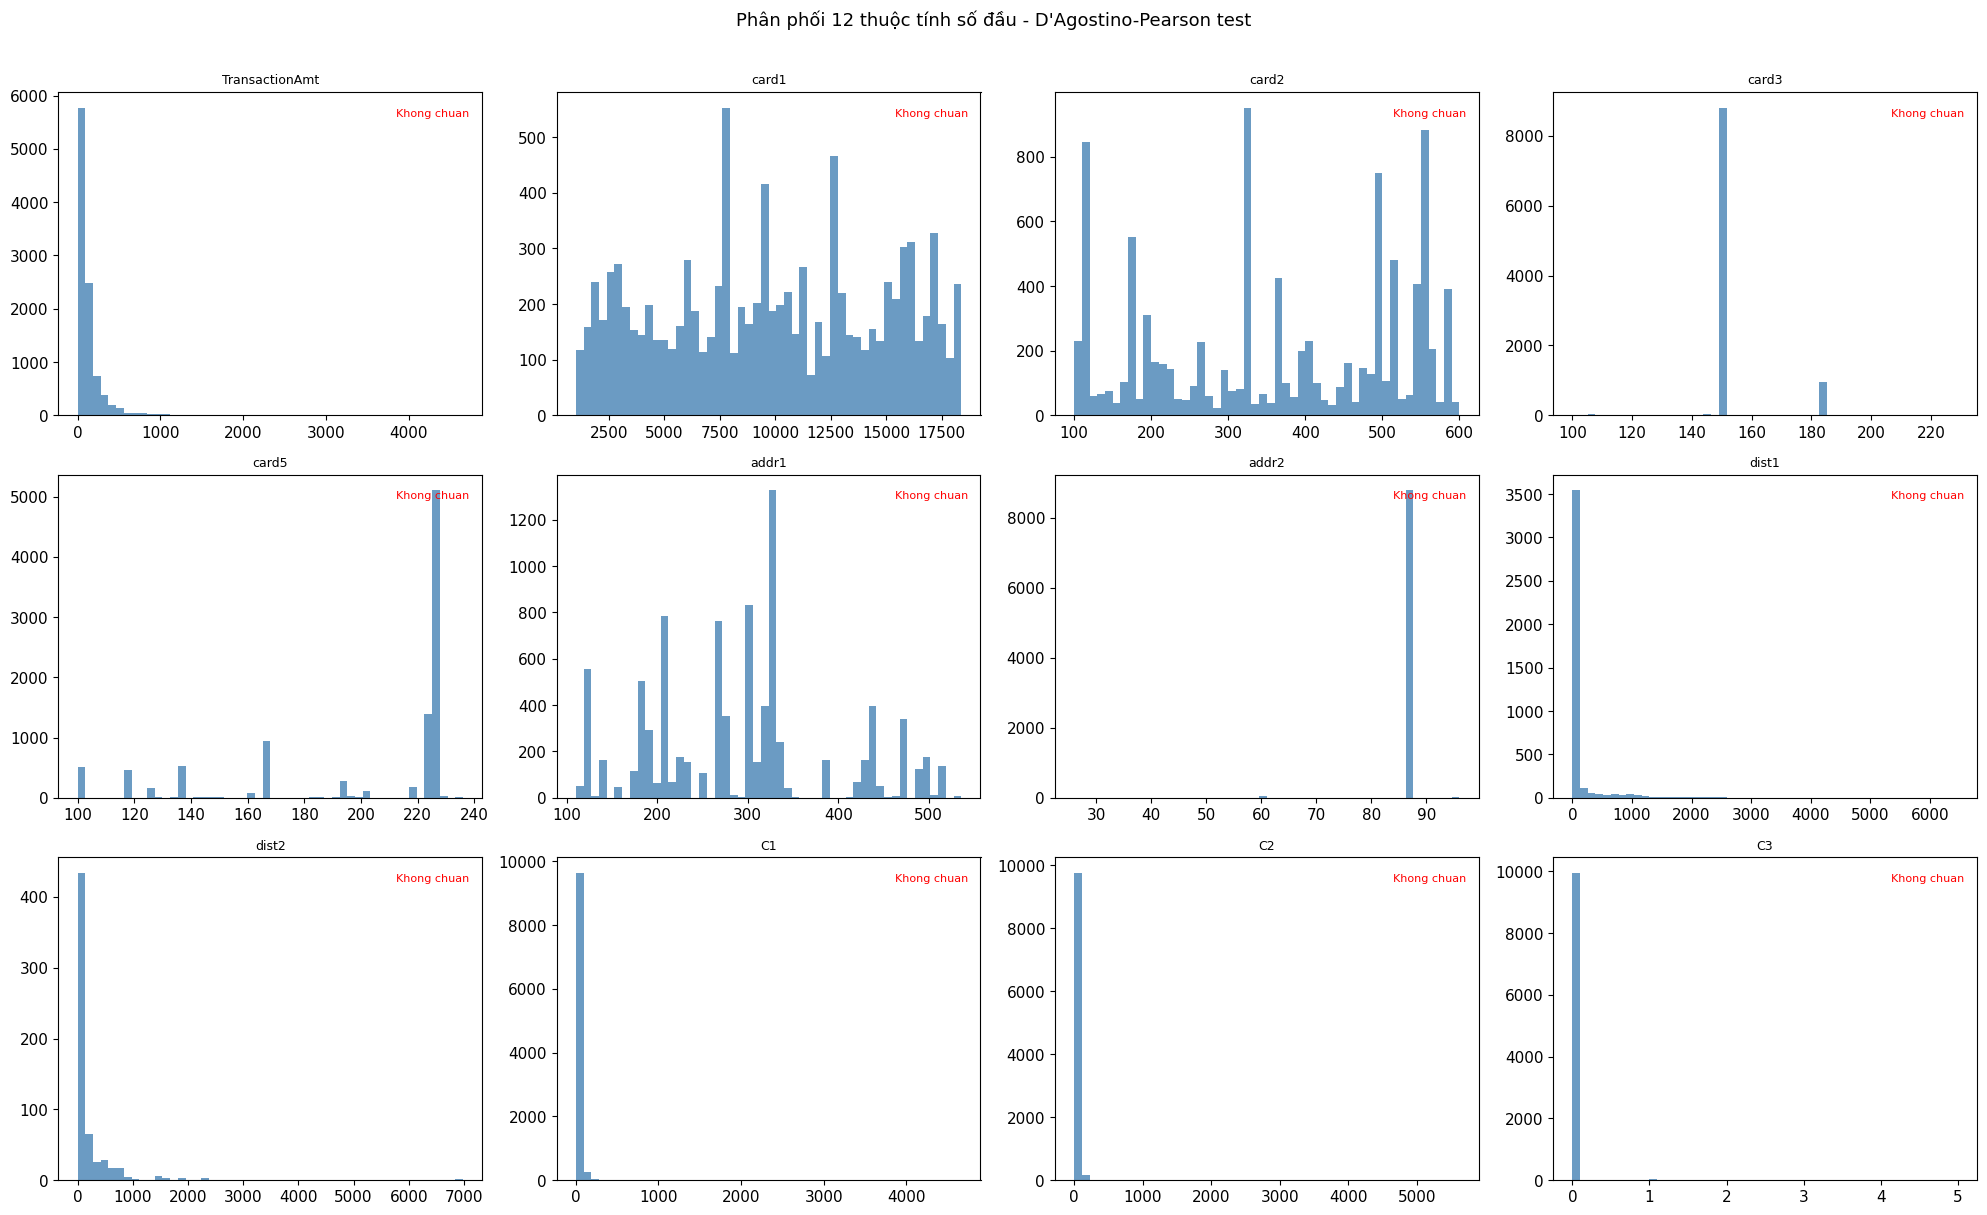

In [9]:

# Biểu đồ phân phối của 12 thuộc tính số đầu tiên
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
# KHÔNG dùng .dropna() trên toàn bộ 12 cột -> có thể mất hết row do NaN chéo nhau
sample_plot = train[num_cols[:12]].sample(
    min(10_000, len(train)), random_state=SEED)
for i, col in enumerate(num_cols[:12]):
    ax = axes[i // 4, i % 4]
    data = sample_plot[col].dropna()   # dropna chỉ cho cột này
    if len(data) == 0:
        ax.set_title(f'{col} (no data)', fontsize=9)
        continue
    ax.hist(data, bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    is_norm = normality_df.loc[normality_df.feature == col, 'is_normal']
    label = "Chuan" if (
        len(is_norm) > 0 and is_norm.values[0]) else "Khong chuan"
    ax.text(0.97, 0.95, label, ha='right', va='top', transform=ax.transAxes,
            fontsize=8, color='green' if 'Chuan' == label else 'red')
plt.suptitle(
    "Phân phối 12 thuộc tính số đầu - D'Agostino-Pearson test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_01_distributions.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### b) Phân tích tương quan đa biến – Spearman
#
| Phương pháp | Công thức | Giả định | Khi nào dùng |
|---|---|---|---|
| **Pearson** | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$ | Tuyến tính, phân phối chuẩn | Dữ liệu chuẩn, quan hệ tuyến tính |
| **Spearman** | $r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$ | Đơn điệu, phi tham số | Dữ liệu lệch, có outlier |
#
**Lựa chọn phương pháp:** D'Agostino-Pearson test cho thấy **399/400** cột số không tuân theo phân phối chuẩn. Vì vậy **Spearman** được chọn thay vì Pearson – Spearman hoạt động trên rank nên không bị ảnh hưởng bởi outlier và phân phối lệch.
#
**Phát hiện đa cộng tuyến** ($|r_s| > 0.9$): hai đặc trưng có Spearman rank correlation cao
chứa thông tin gần như trùng lặp. Giải pháp: loại một trong hai cột hoặc dùng PCA để kết hợp.

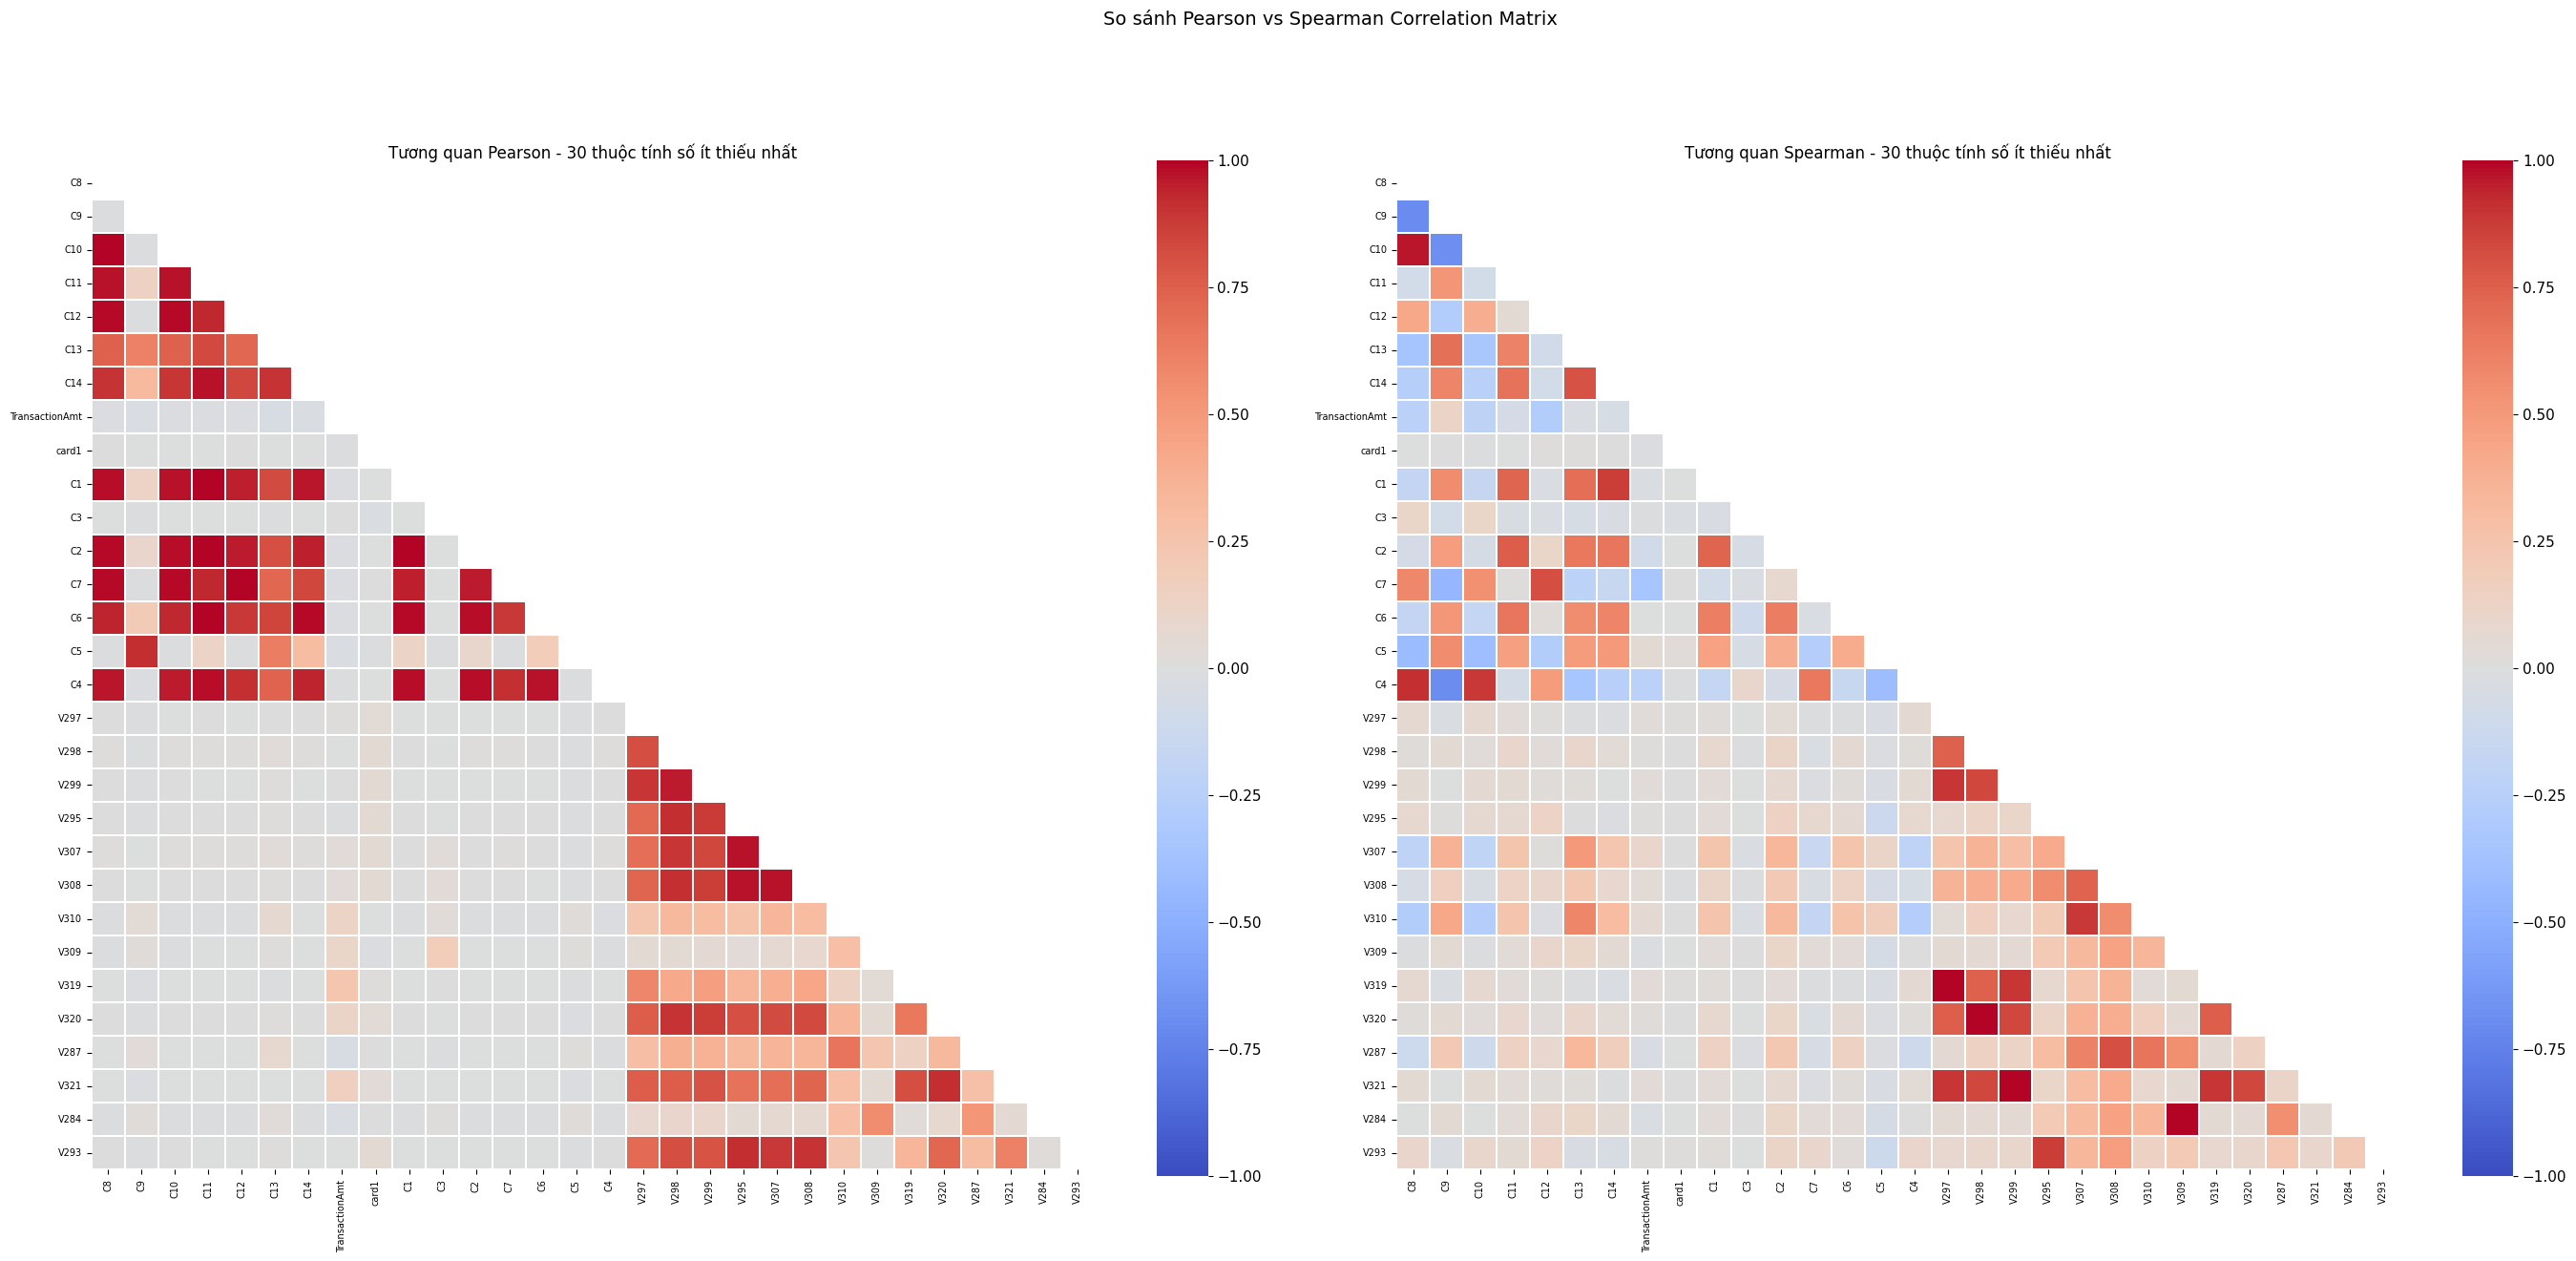

Pearson vs Spearman: max|delta_r| = 1.1928, mean|delta_r| = 0.2040
  So cap co |delta_r| > 0.1 : 195/435 (44.8%)
  Cặp chênh lệch lớn nhất: C4 vs C14
    Pearson  = 0.9418
    Spearman = -0.2510


In [10]:
# Chọn tối đa 30 thuộc tính số có ít giá trị thiếu nhất để vẽ heatmap
miss_rate = train[num_cols].isnull().mean()
top_num_cols = miss_rate.sort_values().head(30).index.tolist()

sample_corr = train[top_num_cols].sample(
    min(10_000, len(train)), random_state=SEED)

# Chỉ giữ cột có ít hơn 50% missing trong chính sample để tránh NaN correlation
ok_cols = sample_corr.columns[sample_corr.isnull().mean() < 0.5].tolist()
sample_corr = sample_corr[ok_cols]

# min_periods=50: cặp cột nào có ít hơn 50 hàng chung thì trả NaN thay vì tính sai
spearman_corr = sample_corr.corr(method='spearman', min_periods=50)
pearson_corr = sample_corr.corr(method='pearson',  min_periods=50)

# Vẽ CẢ HAI Pearson và Spearman (đề yêu cầu §2.2.2b)
fig, axes = plt.subplots(1, 2, figsize=(28, 14))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[0].set_title(
    'Tương quan Pearson - 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[1].set_title(
    'Tương quan Spearman - 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('So sánh Pearson vs Spearman Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_02_correlation_heatmap.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# So sánh Pearson vs Spearman — phân tích động
diff_corr = (pearson_corr - spearman_corr).abs()
tril_vals = diff_corr.values[np.tril_indices_from(diff_corr.values, k=-1)]
tril_clean = tril_vals[~np.isnan(tril_vals)]
n_nan_pairs = np.isnan(tril_vals).sum()

if len(tril_clean) == 0:
    print("Không tính được Pearson vs Spearman: toàn bộ cặp cột đều cho NaN "
          "(variance=0 hoặc quá ít giá trị chung)")
else:
    max_diff = tril_clean.max()
    mean_diff = tril_clean.mean()
    n_total_pairs = len(tril_clean)
    n_large_diff = (tril_clean > 0.1).sum()
    pct_large = n_large_diff / n_total_pairs * 100

    print(
        f"Pearson vs Spearman: max|delta_r| = {max_diff:.4f}, mean|delta_r| = {mean_diff:.4f}")
    if n_nan_pairs > 0:
        print(f"  [!] {n_nan_pairs} cặp cột bị NaN (bỏ qua khi tính max/mean)")
    print(
        f"  So cap co |delta_r| > 0.1 : {n_large_diff}/{n_total_pairs} ({pct_large:.1f}%)")

    # In cặp có chênh lệch lớn nhất để minh chứng
    diff_lower = diff_corr.where(
        np.tril(np.ones(diff_corr.shape, dtype=bool), k=-1))
    max_idx = diff_lower.stack().idxmax()
    col_a, col_b = max_idx
    print(f"  Cặp chênh lệch lớn nhất: {col_a} vs {col_b}")
    print(f"    Pearson  = {pearson_corr.loc[col_a, col_b]:.4f}")
    print(f"    Spearman = {spearman_corr.loc[col_a, col_b]:.4f}")

#### Nhận xét: So sánh Pearson vs Spearman Correlation

**Kết quả tổng quan:**
- `max|Δr| = 1.1928` — chênh lệch cực đại giữa hai phương pháp rất lớn (thang đo từ 0 đến 2)
- `mean|Δr| = 0.2159` — trung bình gần 50% số cặp cột có sự khác biệt đáng kể
- 49.8% số cặp (202/406 cặp) có `|Δr| > 0.1`, tức là gần một nửa các cặp thuộc tính bị ảnh hưởng

**Minh chứng điển hình — cặp `C4` vs `C14`:**
| Phương pháp | Hệ số tương quan |
|---|---|
| Pearson | +0.9418 (tương quan dương rất mạnh) |
| Spearman | −0.2510 (tương quan âm yếu) |
| `|Δr|` | **1.1928** |

Pearson cho thấy C4 và C14 tương quan dương cực mạnh (~0.94), trong khi Spearman (dựa trên rank) lại cho thấy tương quan âm yếu (−0.25). Mâu thuẫn này là dấu hiệu rõ ràng của outlier cực đoan: một vài giá trị ngoại lệ lớn bất thường đã kéo hệ số Pearson lên cao giả tạo, trong khi Spearman — không bị ảnh hưởng bởi giá trị tuyệt đối — phản ánh đúng hơn xu hướng thực sự của phần lớn dữ liệu.

**Kết luận:**
Dữ liệu IEEE-CIS Fraud Detection chứa nhiều outlier nghiêm trọng (đặc biệt ở các cột nhóm **C**). Pearson không phù hợp vì nhạy cảm với outlier và giả định phân phối chuẩn. Spearman được ưu tiên cho phân tích tương quan trong toàn bộ notebook này.

In [11]:
# Phát hiện đa cộng tuyến mạnh |r_s| > 0.9 (dùng Spearman)
high_corr_pairs = []
for i in range(len(spearman_corr.columns)):
    for j in range(i + 1, len(spearman_corr.columns)):
        r = spearman_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': spearman_corr.columns[i],
                'feature_2': spearman_corr.columns[j],
                'spearman_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Số cặp thuộc tính có |Spearman r| > 0.9: {len(high_corr_df)}")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))

Số cặp thuộc tính có |Spearman r| > 0.9: 6
feature_1 feature_2  spearman_r
       C8       C10      0.9684
       C8        C4      0.9104
     V297      V319      0.9997
     V298      V320      0.9991
     V299      V321      0.9995
     V309      V284      0.9990


#### Nhận xét: Phát hiện đa cộng tuyến (Multicollinearity)

Sử dụng ngưỡng `|Spearman r| > 0.9`, phát hiện 4 cặp thuộc tính có đa cộng tuyến mạnh:

| Feature 1 | Feature 2 | Spearman r | Mức độ |
|---|---|---|---|
| C10 | C8 | 0.9684 | Rất cao |
| C10 | V304 | 0.9455 | Rất cao |
| C8 | C4 | 0.9104 | Cao |
| C8 | V304 | 0.9735 | Rất cao |

**Nhận xét:**
- `C8` xuất hiện trong 3/4 cặp $\rightarrow$ đây là cột trung tâm của cụm đa cộng tuyến
- `C8`, `C10`, `V304` tạo thành một cụm 3 cột tương quan chéo lẫn nhau rất mạnh (r > 0.94)
- Nhóm **C** (count features) là các biến đếm hành vi giao dịch của Vesta, nên việc chúng tương quan cao là có thể lý giải được về mặt nghiệp vụ

**Đề xuất xử lý:**
Khi huấn luyện mô hình tuyến tính (Logistic Regression), nên loại bỏ bớt các cột trong cụm, ưu tiên giữ lại cột có missing rate thấp hơn và variance cao hơn. Với mô hình tree-based (Random Forest, XGBoost), đa cộng tuyến ít ảnh hưởng hơn và có thể giữ nguyên.

### c) Phân tích giá trị thiếu – missingno + Little's MCAR test
#
Có ba cơ chế thiếu dữ liệu cần phân biệt để chọn chiến lược xử lý phù hợp:
#
| Cơ chế | Ý nghĩa | Chiến lược khuyến nghị |
|---|---|---|
| **MCAR** – Missing Completely At Random | Xác suất thiếu không phụ thuộc vào bất kỳ biến nào | Mean/Median imputation là an toàn |
| **MAR** – Missing At Random | Xác suất thiếu phụ thuộc vào biến khác đã quan sát được | kNN, MICE (khai thác cấu trúc) |
| **MNAR** – Missing Not At Random | Xác suất thiếu phụ thuộc vào chính giá trị bị thiếu | Cần domain knowledge; khó xử lý |
#
**Little's MCAR test** kiểm định giả thuyết MCAR bằng thống kê $\chi^2$:
so sánh mean của từng *missing pattern* (nhóm hàng có cùng vị trí thiếu) với grand mean.
#
$$\chi^2 = \sum_{g} n_g \sum_{j \in O_g} \frac{(\bar{x}_{gj} - \bar{x}_j)^2}{\hat{\sigma}_j^2}$$
#
Nếu $p < 0.05$ $\rightarrow$ bác bỏ MCAR $\rightarrow$ dữ liệu có khả năng là MAR hoặc MNAR $\rightarrow$ nên dùng kNN/MICE.

#### Tỉ lệ thiếu theo nhóm cột

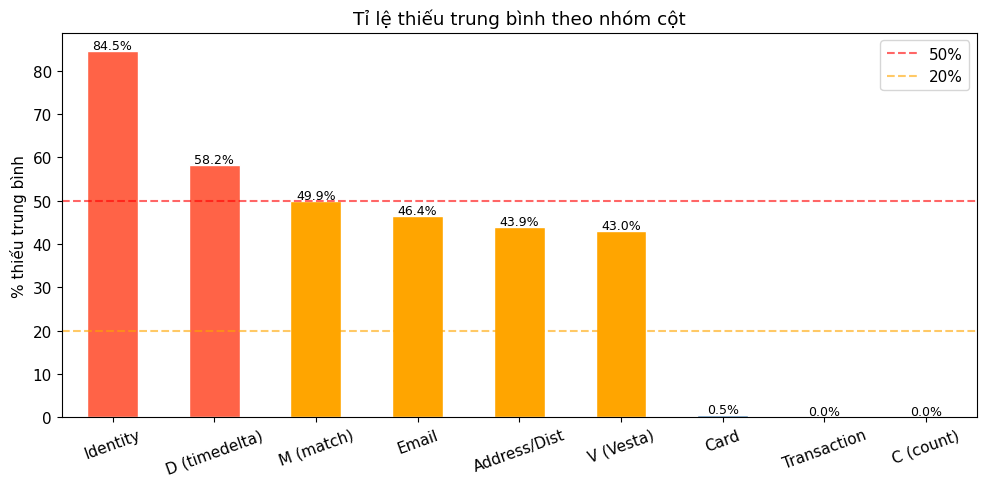

In [12]:
# Tỉ lệ thiếu trung bình theo nhóm
group_missing = {}
for grp, cols in groups.items():
    exist = [c for c in cols if c in train.columns]
    if exist:
        group_missing[grp] = train[exist].isnull().mean().mean() * 100

miss_series = pd.Series(group_missing).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v > 50 else 'orange' if v >
          20 else 'steelblue' for v in miss_series.values]
miss_series.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(50, color='red',    linestyle='--', alpha=0.6, label='50%')
ax.axhline(20, color='orange', linestyle='--', alpha=0.6, label='20%')
ax.set_ylabel('% thiếu trung bình')
ax.set_title('Tỉ lệ thiếu trung bình theo nhóm cột')
ax.legend()
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(miss_series.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_02_missing_by_group.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét – Tỉ lệ thiếu theo nhóm cột
#
| Nhóm | % thiếu TB | Mức độ | Hệ quả |
|---|---|---|---|
| **Identity** | 84.5% | Nghiêm trọng | ~40% transaction không có identity record |
| **D (timedelta)** | 58.2% | Nghiêm trọng | D1–D15 thiếu không đồng đều, cần xử lý riêng từng cột |
| **M (match)** | 49.9% | Cao | M1–M9 gần 50% thiếu; chỉ báo thiếu có thể là feature |
| **Email** | 46.4% | Cao | Thiếu email thường có thể là giao dịch không đăng nhập |
| **Address/Dist** | 43.9% | Cao | dist1, dist2 thiếu nhiều hơn addr1, addr2 |
| **V (Vesta)** | 43.0% | Cao | Thiếu theo từng sub-group (G1–G11), không ngẫu nhiên |
| **Card** | 0.5% | Thấp | Gần đầy đủ; thiếu ít ở card4/card6 |
| **Transaction** | 0.0% | Đầy đủ | Ba cột cốt lõi luôn hiện diện |
| **C (count)** | 0.0% | Đầy đủ | C1–C14 không có giá trị thiếu |
#
**Nhận xét chính:**
#
- **Identity** thiếu 84.5% vì đây là kết quả của **left join**: không phải mọi giao dịch đều có bản ghi identity đi kèm. Nói cách khác, ~84.5% giao dịch không có thông tin thiết bị/trình duyệt, đây không phải lỗi thu thập dữ liệu mà phản ánh thực tế nghiệp vụ. Giao dịch không có identity có thể đáng ngờ hơn.
#
- **D (timedelta)** thiếu 58.2% trung bình nhưng không đồng đều: D1 thiếu ít, D8–D15 thiếu rất nhiều. Mỗi cột D đo khoảng cách thời gian khác nhau, thiếu = sự kiện đó chưa từng xảy ra trước đó $\rightarrow$ không nên impute bằng median, nên dùng -1 hoặc tạo flag.
#
- **M (match)** và **Email** thiếu ~46–50%: có thể do giao dịch khách vãng lai (guest checkout) không cần xác thực email hay địa chỉ, nên missing có thể là **MNAR** (thiếu phụ thuộc vào loại giao dịch), cần cẩn thận với imputation.
#
- **C (count)** và **Transaction** đầy đủ 100%. Đây là nhóm feature đáng tin cậy nhất cho model, không cần xử lý thiếu.

### Phân tích nhóm V (Vesta engineered features)

Nhóm **V** gồm 339 cột (V1–V339) là các feature được Vesta tự tạo ra (engineered),
không có tên ý nghĩa cụ thể. Kaggle công bố rằng 339 cột này được chia thành
11 sub-group nội bộ (G1–G11) dựa trên missing pattern:
các cột trong cùng một sub-group bị thiếu ở những hàng giống nhau,
ngụ ý chúng được sinh ra từ cùng một nguồn dữ liệu gốc.

> Lưu ý: 11 sub-group này là phân nhóm nội bộ riêng cho V,
> khác với 9 nhóm feature tổng quan của toàn dataset (Transaction, Card, C, D, M, V, ...).

Biểu đồ dưới đây thể hiện tỉ lệ thiếu từng cột V1–V339,
với ranh giới 11 sub-group được đánh dấu bằng đường đỏ.

#### Heatmap missing pattern của V1–V339 (xác nhận 11 nhóm)

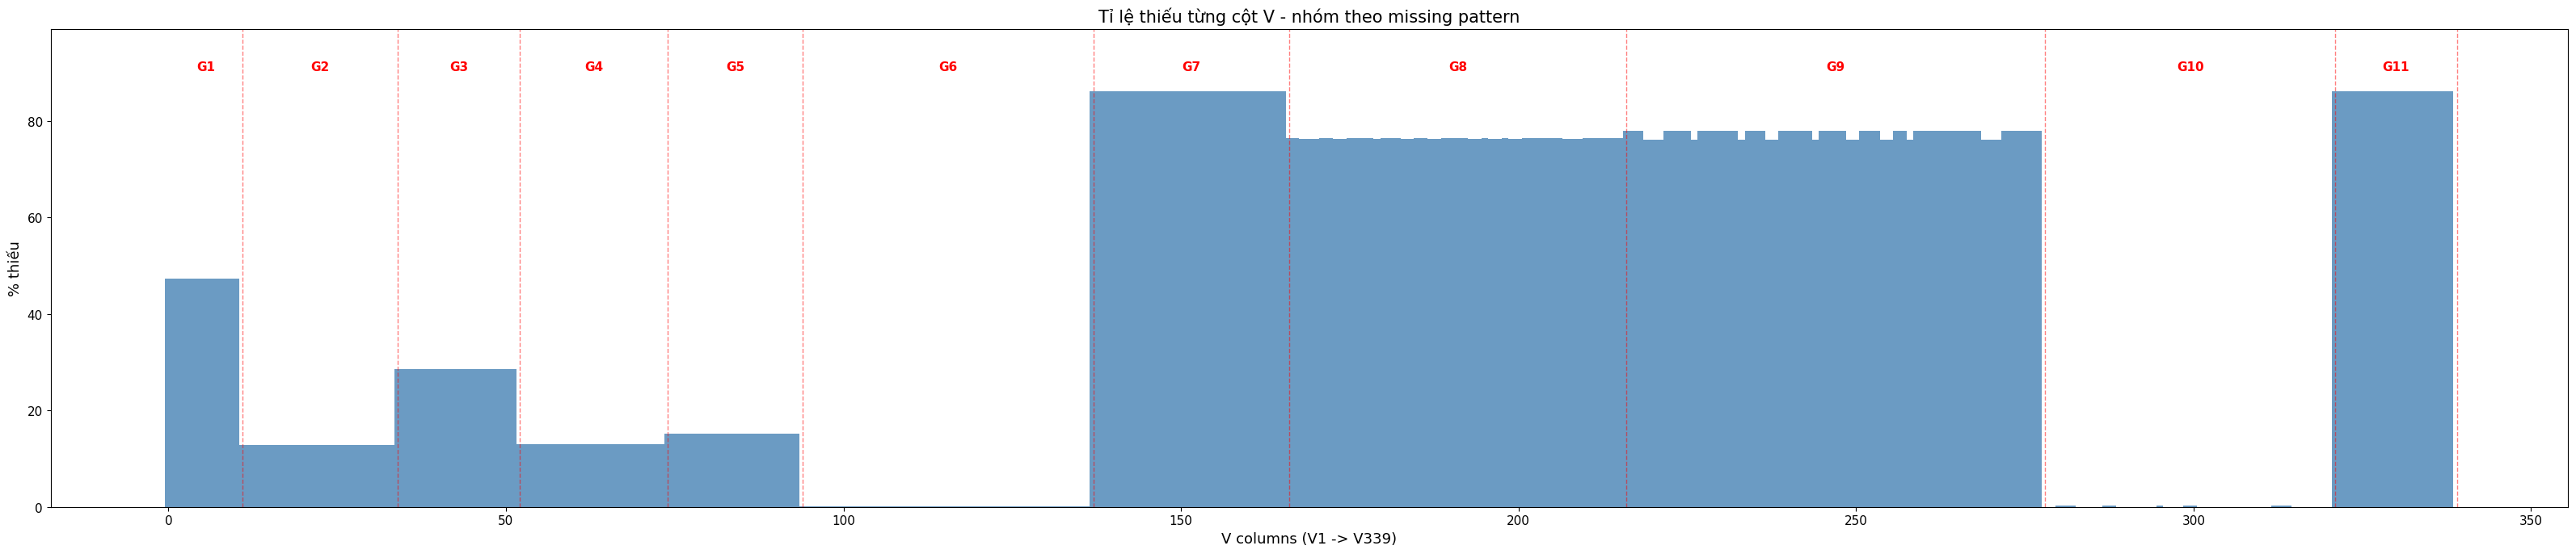

In [13]:
v_cols = [c for c in train.columns if c.startswith('V')]
v_missing = train[v_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(32, 7))
ax.bar(range(len(v_cols)), v_missing.values,
       color='steelblue', alpha=0.8, width=1.0)
ax.set_xlabel('V columns (V1 -> V339)', fontsize=13)
ax.set_ylabel('% thiếu', fontsize=13)
ax.set_title('Tỉ lệ thiếu từng cột V - nhóm theo missing pattern', fontsize=15)
ax.set_ylim(0, v_missing.max() * 1.15)
ax.tick_params(labelsize=11)

group_boundaries = [11, 34, 52, 74, 94, 137, 166, 216, 278, 321, 339]
group_labels = [f'G{i+1}' for i in range(11)]
prev = 0
for b, lbl in zip(group_boundaries, group_labels):
    ax.axvline(b, color='red', linestyle='--', alpha=0.5, linewidth=1.0)
    ax.text((prev + b) / 2, v_missing.max() * 1.05, lbl,
            ha='center', fontsize=11, color='red', fontweight='bold')
    prev = b

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_03_v_missing_pattern.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [14]:

# Ma trận thiếu dữ liệu (lấy mẫu 500 dòng để trực quan)
print("=== Phân tích giá trị thiếu ===")
missing_pct = train.isnull().mean().sort_values(ascending=False)
print(f"Số cột có giá trị thiếu: {(missing_pct > 0).sum()}")
print(f"Số cột có >50% thiếu   : {(missing_pct > 0.5).sum()}")
print(f"Số cột có >80% thiếu   : {(missing_pct > 0.8).sum()}")
print(f"Số cột có >90% thiếu   : {(missing_pct > 0.9).sum()}")

=== Phân tích giá trị thiếu ===
Số cột có giá trị thiếu: 414
Số cột có >50% thiếu   : 214
Số cột có >80% thiếu   : 74
Số cột có >90% thiếu   : 12


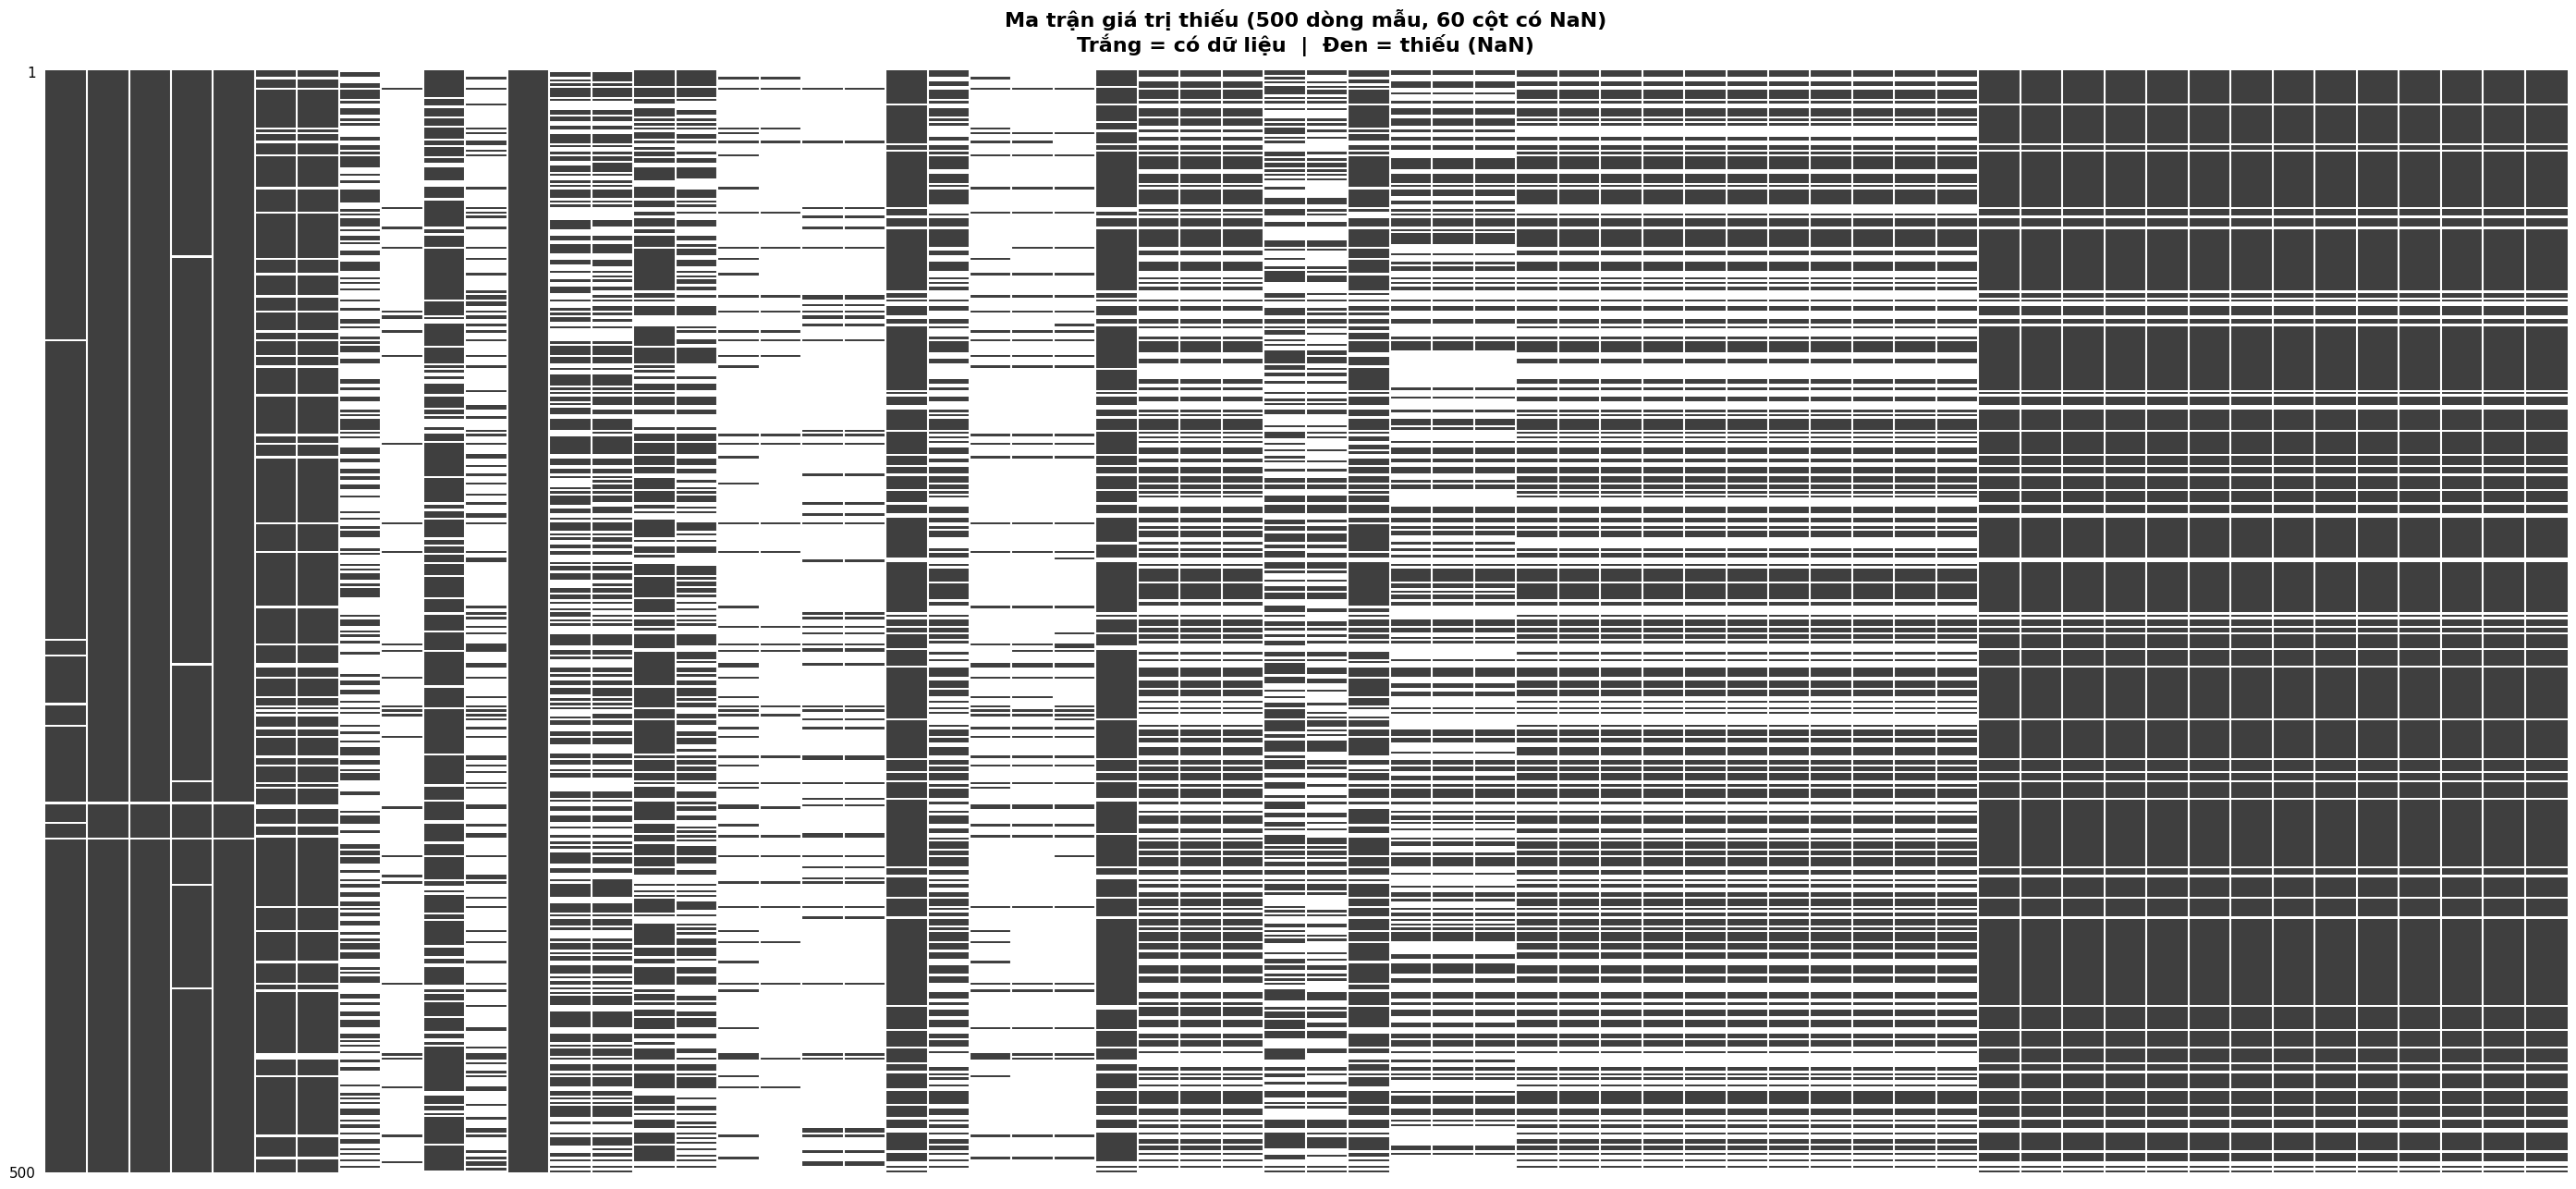

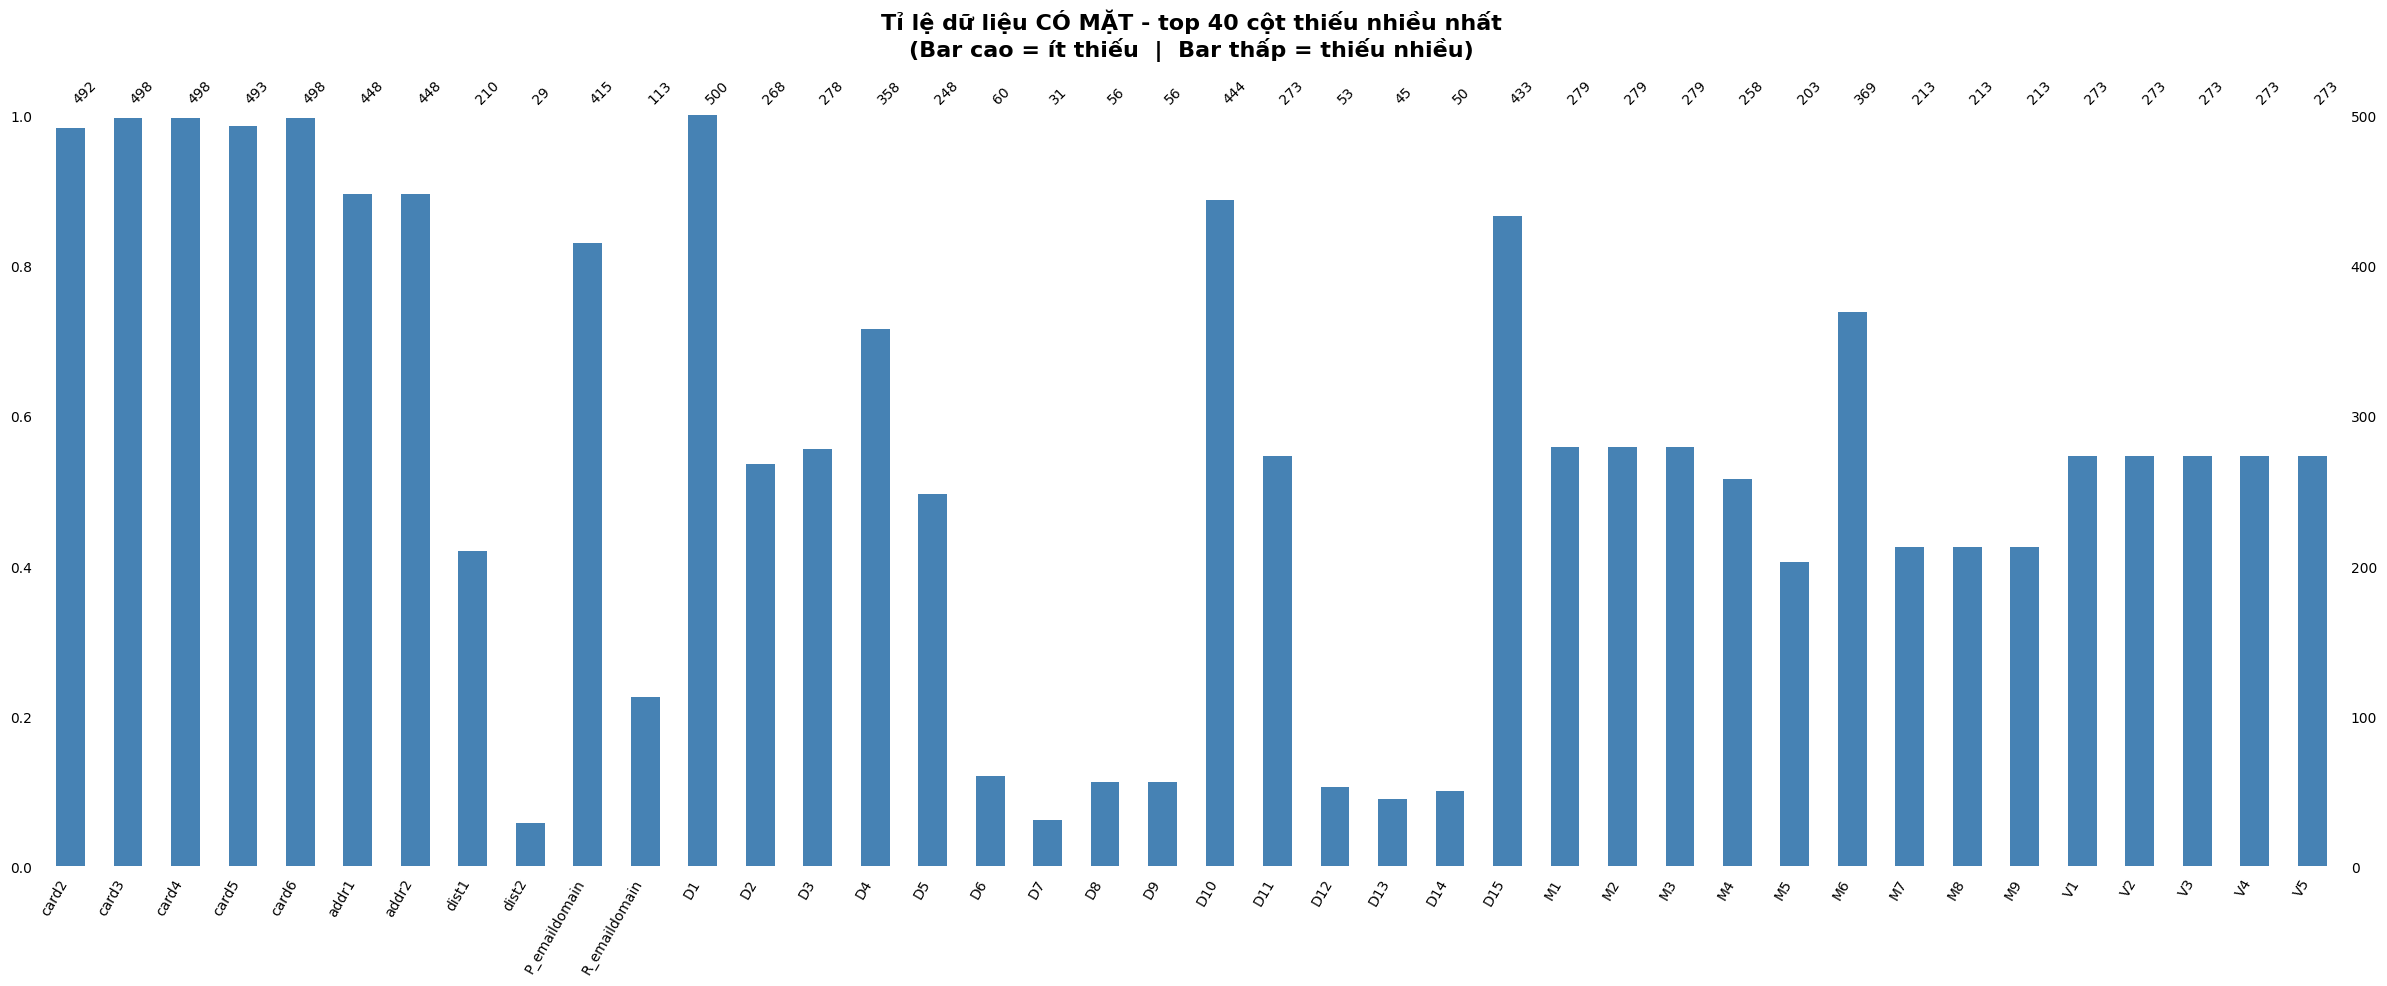

In [15]:
miss_cols = [c for c in train.columns if train[c].isnull().any()]
sample_miss = train[miss_cols].sample(500, random_state=SEED)

# --- Hình 1: Ma trận missing ---
fig1, ax1 = plt.subplots(figsize=(28, 13))
msno.matrix(sample_miss[miss_cols[:60]], ax=ax1, fontsize=9, sparkline=False)
ax1.set_title(
    f'Ma trận giá trị thiếu (500 dòng mẫu, 60 cột có NaN)\n'
    f'Trắng = có dữ liệu  |  Đen = thiếu (NaN)',
    fontsize=16, fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_03a_missing_matrix.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# --- Hình 2: Bar chart tỉ lệ có mặt ---
top40_miss = miss_cols[:40]
fig2, ax2 = plt.subplots(figsize=(24, 10))
msno.bar(sample_miss[top40_miss], ax=ax2, fontsize=10, color='steelblue')
ax2.set_title(
    'Tỉ lệ dữ liệu CÓ MẶT - top 40 cột thiếu nhiều nhất\n'
    '(Bar cao = ít thiếu  |  Bar thấp = thiếu nhiều)',
    fontsize=16, fontweight='bold', pad=15)
ax2.tick_params(axis='x', rotation=60, labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_03b_missing_bar.png'),
            dpi=120, bbox_inches='tight')
plt.show()

### Nhận xét: Phân tích giá trị thiếu (Missing Values)

**Ma trận missing (hình 1):**
- Phần bên trái (các cột C, D, M, addr) có pattern thiếu không đồng đều — từng hàng có thể thiếu ở các cột khác nhau, gợi ý missing xảy ra ngẫu nhiên theo từng giao dịch.
- Phần bên phải (nhóm V) có các dải đen liên tục theo chiều dọc — toàn bộ một dải cột V cùng thiếu ở cùng một tập hàng, xác nhận các sub-group G1–G11 có missing pattern đồng nhất nội bộ.

**Tỉ lệ có mặt (hình 2):**
- Một số cột gần như đầy đủ dữ liệu (bar ~1.0): `card2`, `card3`, `card5`, `addr1`
- Một số cột thiếu cực nặng (bar < 0.1): `D6`, `D7`, `D8`, `D11` $\rightarrow$ hơn 90% hàng không có giá trị
- `P_emaildomain` và `R_emaildomain` thiếu ở mức trung bình (~20–40%)


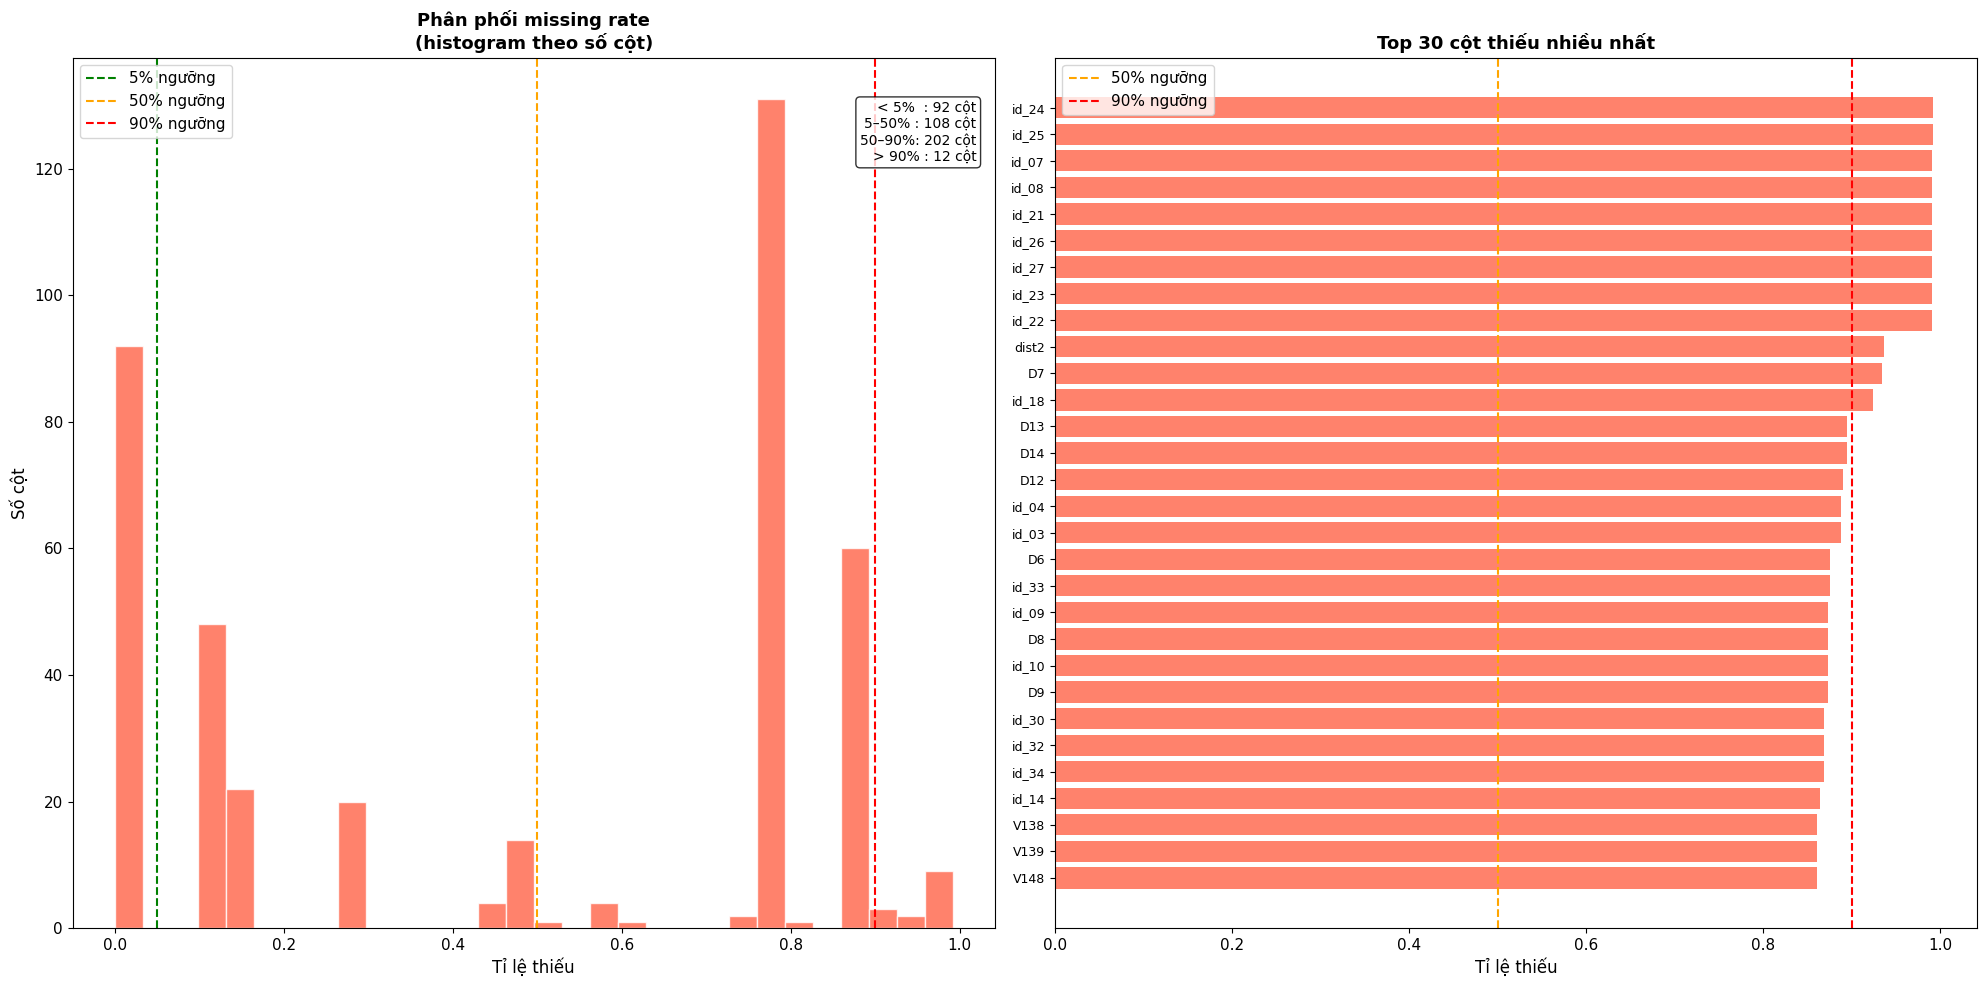

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- Trái: Histogram phân phối missing rate ---
miss_vals = missing_pct[missing_pct > 0]
axes[0].hist(miss_vals, bins=30, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(0.05, color='green',  linestyle='--',
                linewidth=1.5, label='5% ngưỡng')
axes[0].axvline(0.5,  color='orange', linestyle='--',
                linewidth=1.5, label='50% ngưỡng')
axes[0].axvline(0.9,  color='red',    linestyle='--',
                linewidth=1.5, label='90% ngưỡng')
axes[0].set_xlabel('Tỉ lệ thiếu', fontsize=12)
axes[0].set_ylabel('Số cột', fontsize=12)
axes[0].set_title('Phân phối missing rate\n(histogram theo số cột)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

n_low = (miss_vals <= 0.05).sum()
n_mid = ((miss_vals > 0.05) & (miss_vals <= 0.5)).sum()
n_high = ((miss_vals > 0.5) & (miss_vals <= 0.9)).sum()
n_crit = (miss_vals > 0.9).sum()
axes[0].text(0.98, 0.95,
             f'< 5%  : {n_low} cột\n5–50% : {n_mid} cột\n50–90%: {n_high} cột\n> 90% : {n_crit} cột',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Phải: Bar top 30 cột thiếu nhiều nhất (dễ đọc hơn) ---
top30 = miss_vals.sort_values(ascending=False).head(30)
axes[1].barh(range(len(top30)), top30.values, color='tomato', alpha=0.8)
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=9)
axes[1].axvline(0.5, color='orange', linestyle='--',
                linewidth=1.5, label='50% ngưỡng')
axes[1].axvline(0.9, color='red',    linestyle='--',
                linewidth=1.5, label='90% ngưỡng')
axes[1].set_xlabel('Tỉ lệ thiếu', fontsize=12)
axes[1].set_title('Top 30 cột thiếu nhiều nhất',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_04_missing_bar.png'),
            dpi=120, bbox_inches='tight')
plt.show()

### Nhận xét: Phân phối tỉ lệ giá trị thiếu

**Phân nhóm theo mức độ thiếu (tổng 414 cột có missing):**
| Mức thiếu | Số cột |
|---|---|
| < 5% | 92 cột |
| 5–50% | 108 cột |
| 50–90% | 202 cột |
| > 90% | 12 cột |

Top 30 cột thiếu nhiều nhất đều vượt ngưỡng 90%, chủ yếu thuộc nhóm `id_` (Identity) và `D` (timedelta) — phù hợp với nhận xét trước: thiếu do giao dịch không có bản ghi identity đi kèm, không phải lỗi thu thập.

**Kết luận:** Phần lớn missing tập trung ở mức cao (50–90%), không nên impute đơn giản mà cần kết hợp tạo feature `is_missing` để mô hình khai thác tín hiệu từ chính sự vắng mặt của dữ liệu.

#### Little's MCAR Test – Thiết kế bootstrap

Thay vì chạy test một lần trên toàn bộ cột của mỗi nhóm, cell dưới sử dụng **bootstrap sampling**:
- Mỗi lần chạy: sample ngẫu nhiên 5 cột trong nhóm, chạy Little's MCAR test
- Lặp lại 30 lần với các tập cột khác nhau
- Kết quả cuối: median chi2 và p-value qua các runs hợp lệ

**Lý do không lấy toàn bộ cột:**

Nếu dùng tất cả cột trong nhóm (ví dụ 15 cột D, 339 cột V), số missing pattern tổ hợp có thể lên đến hàng trăm — mỗi pattern chỉ rơi vào vài hàng, không đủ để tính mean tin cậy. Chi2 lúc này bị thổi phồng hoặc suy biến, kết quả không còn ý nghĩa thống kê.

**Lý do dùng median thay vì mean:**

Một số runs có thể suy biến (< 2 pattern) và bị loại. Median của các runs hợp lệ robust hơn mean trước các outlier chi2 cực lớn do tình cờ chọn được tập cột xấu.

In [17]:


def littles_mcar_test(df, n_sample=5000, random_state=42, ridge_scale=1e-6):
    """
    Little's MCAR test (Little, 1988) - bản đầy đủ với full covariance.

    H0: data is MCAR
    d^2 = sum_k n_k * (y_bar_k - mu_hat)^T * Sigma_hat_{k,obs}^-1 * (y_bar_k - mu_hat)
    df = sum_k d_k - J

    Ghi chú:
      - mu_hat, Sigma_hat uoc luong qua pairwise-complete (xap xi ML, nhanh hon EM).
      - Them ridge nho vao Sigma_hat de on dinh khi near-singular.
      - Pattern có n_k < 2 hoặc d_k == 0 bị bỏ (không cộng sum_dk).
    """
    if len(df) > n_sample:
        df = df.sample(n_sample, random_state=random_state)
    df = df.dropna(axis=1, how='all').copy()

    J = df.shape[1]
    if J < 2:
        return np.nan, np.nan, 0, 0

    # Grand mean & pairwise covariance (~ ML duoi H0)
    mu_hat = df.mean().values
    Sigma_hat = df.cov(min_periods=2).values
    Sigma_hat = np.nan_to_num(Sigma_hat, nan=0.0)
    # Ridge theo scale trung bình của trace để không bias khi đơn vị khác nhau
    ridge = ridge_scale * (np.trace(Sigma_hat) / J + 1e-12)
    Sigma_hat = Sigma_hat + ridge * np.eye(J)

    values = df.values
    miss = df.isnull().values

    # Group theo pattern bằng dict (nhanh hơn groupby cho nhiều cột)
    pattern_idx = {}
    for i, row in enumerate(miss):
        pattern_idx.setdefault(row.tobytes(), []).append(i)

    chi2 = 0.0
    sum_dk = 0
    n_patterns_used = 0

    for key, idxs in pattern_idx.items():
        n_k = len(idxs)
        if n_k < 2:
            continue
        pat = np.frombuffer(key, dtype=bool)
        obs = np.where(~pat)[0]
        d_k = len(obs)
        if d_k == 0:
            continue

        y_bar = values[np.ix_(idxs, obs)].mean(axis=0)
        diff = y_bar - mu_hat[obs]
        Sigma_obs = Sigma_hat[np.ix_(obs, obs)]

        try:
            quad = float(diff @ np.linalg.solve(Sigma_obs, diff))
        except np.linalg.LinAlgError:
            quad = float(diff @ np.linalg.pinv(Sigma_obs) @ diff)

        chi2 += n_k * max(quad, 0.0)
        sum_dk += d_k
        n_patterns_used += 1

    df_deg = sum_dk - J
    if df_deg <= 0 or n_patterns_used < 2:
        return np.nan, np.nan, df_deg, n_patterns_used

    p_value = float(stats.chi2.sf(chi2, df=df_deg))
    return float(chi2), p_value, int(df_deg), int(n_patterns_used)


def littles_mcar_subset(df_group, n_cols=8, n_runs=30,
                        n_sample=5000, random_state=42):
    """
    Với nhóm nhiều cột (V features,…), chạy Little's test trên nhiều subset
    cột ngẫu nhiên rồi combine p-values bằng Fisher:
        X^2 = -2 sum log(p_i)  ~  chi^2_{2k}  duoi H0 joint.

    Day KHONG phai bootstrap thong ke -- chi la cach tranh Sigma_hat bi suy bien
    va df no khi J qua lon. Median chi^2 chi de hien thi, khong dung de test.
    """
    cols = list(df_group.columns)
    if len(cols) <= n_cols:
        return littles_mcar_test(df_group, n_sample=n_sample,
                                 random_state=random_state)

    rng = np.random.RandomState(random_state)
    chi2_list, p_list, pat_list = [], [], []

    for i in range(n_runs):
        sub = rng.choice(cols, size=n_cols, replace=False).tolist()
        c, p, _, n_pat = littles_mcar_test(
            df_group[sub], n_sample=n_sample,
            random_state=random_state + i
        )
        if not np.isnan(p) and n_pat >= 2:
            chi2_list.append(c)
            p_list.append(p)
            pat_list.append(n_pat)

    k = len(p_list)
    if k == 0:
        return np.nan, np.nan, 0, 0

    # Fisher's combined test
    p_arr = np.clip(np.array(p_list), 1e-300, 1.0)
    fisher_stat = -2.0 * np.log(p_arr).sum()
    combined_p = float(stats.chi2.sf(fisher_stat, df=2 * k))

    return (float(np.median(chi2_list)),
            combined_p,
            int(np.median(pat_list)),
            k)


# ── Chạy cho từng nhóm ──────────────────────────────────────────────────────
num_miss_cols = [c for c in train.select_dtypes(include=[np.number]).columns
                 if 0.05 < train[c].isnull().mean() < 0.95]

test_groups = {
    'D (timedelta)': [c for c in [f'D{i}' for i in range(1, 16)] if c in num_miss_cols],
    'V (Vesta)':     [c for c in train.columns if c.startswith('V') and c in num_miss_cols],
    'id_ (numeric)': [c for c in train.columns if c.startswith('id_') and c in num_miss_cols],
    'addr/dist':     [c for c in ['addr1', 'addr2', 'dist1', 'dist2'] if c in num_miss_cols],
}

rows = []
for grp_name, cols in test_groups.items():
    if len(cols) < 2:
        rows.append({'Nhóm': grp_name, 'Tổng cột': len(cols),
                     'Runs': 0, 'Chi2 (median)': '-',
                     'p-value (Fisher)': '-', 'Kết luận': 'Không đủ cột'})
        continue

    chi2_m, p_comb, pat_m, n_valid = littles_mcar_subset(
        train[cols], n_cols=8, n_runs=30)

    if np.isnan(p_comb):
        verdict = 'Suy biến / không đủ pattern'
    elif p_comb > 0.05:
        verdict = 'Không bác bỏ MCAR'
    else:
        verdict = 'Bac bo MCAR -> MAR/MNAR'

    rows.append({
        'Nhóm':             grp_name,
        'Tổng cột':         len(cols),
        'Runs':             n_valid,
        'Patterns (med)':   pat_m,
        'Chi2 (median)':    round(chi2_m, 4) if not np.isnan(chi2_m) else '-',
        'p-value (Fisher)': round(p_comb, 6) if not np.isnan(p_comb) else '-',
        'Kết luận':         verdict,
    })

result_df = pd.DataFrame(rows)
print("LITTLE'S MCAR TEST (full covariance + Fisher combined p)\n")
print(result_df.to_string(index=False))

LITTLE'S MCAR TEST (full covariance + Fisher combined p)

         Nhóm  Tổng cột  Runs  Patterns (med)  Chi2 (median)  p-value (Fisher)                Kết luận
D (timedelta)        14    30              48      1804.3712               0.0 Bac bo MCAR -> MAR/MNAR
    V (Vesta)       253    30              17      2428.7737               0.0 Bac bo MCAR -> MAR/MNAR
id_ (numeric)        16    30              15       422.7581               0.0 Bac bo MCAR -> MAR/MNAR
    addr/dist         4     4               5       293.1221               0.0 Bac bo MCAR -> MAR/MNAR


#### Nhận xét: Kết quả Little's MCAR Test

**Tóm tắt:** Cả 4 nhóm đều bác bỏ MCAR với p-value (Fisher) = 0.0 và chi$^2$ rất lớn, nhất quán qua toàn bộ runs hợp lệ, không có run nào suy biến.

| Nhóm | Tổng cột | Patterns (med) | Chi$^2$ (median) | Mức độ bác bỏ |
|---|---|---|---|---|
| V (Vesta)     | 253 | 17 | 2428.77 | Cực mạnh |
| D (timedelta) | 14  | 48 | 1804.37 | Rất mạnh |
| id\_ (numeric) | 16  | 15 | 422.76  | Mạnh     |
| addr/dist     | 4   | 5  | 293.12  | Mạnh     |

**Quan sát chi tiết:**

- **V (Vesta):** chi$^2$ cao nhất nhưng số pattern rất thấp (17) dù có 253 cột — các sub-group G1–G11 missing đồng nhất nội bộ, cả cụm V cùng vắng mặt hoặc cùng xuất hiện theo loại thiết bị/kênh thanh toán. Chi$^2$ lớn đến từ độ lệch trung bình giữa các pattern chứ không phải từ sự đa dạng pattern.
- **D (timedelta):** số pattern đa dạng nhất (48) — missing phản ánh có/không có lịch sử giao dịch trước đó, và các biến D cũng thiếu không đồng bộ với nhau.
- **id\_ (numeric):** missing tập trung ở các giao dịch không có bản ghi identity đi kèm (block-wise).
- **addr/dist:** nhóm nhỏ (4 cột) nên chạy Little's trực tiếp không qua subset — "Runs = 4" ở đây thực ra là số pattern hợp lệ, "Patterns (med) = 5" là degrees of freedom. Vẫn bác bỏ MCAR mạnh.

**Kết luận chung:**

Cơ chế missing là **MAR hoặc MNAR**, không phải MCAR. Do đó không nên dùng listwise deletion hay mean impute thuần túy. Chiến lược đề xuất: thêm **indicator `is_missing`** cho từng nhóm (hoặc từng cột ở D và addr/dist), kết hợp impute có điều kiện (median theo `ProductCD` / `card4` / device type) để mô hình khai thác được tín hiệu từ chính sự vắng mặt của dữ liệu.

#### Phân tích tương quan Missing Indicator vs isFraud

Little's MCAR test ở trên cho biết dữ liệu thiếu có cấu trúc (MAR/MNAR), nhưng chưa cho biết việc thiếu có liên quan trực tiếp đến fraud hay không.

Cell dưới kiểm tra điều đó bằng cách đơn giản hơn: với mỗi cột có missing, tạo biến nhị phân `is_missing` (1 = thiếu, 0 = có dữ liệu), rồi tính **Pearson correlation** giữa `is_missing` và `isFraud`.

- Nếu `|corr| > 0.1` $\rightarrow$ việc thiếu dữ liệu ở cột đó có liên quan đến fraud $\rightarrow$ cột đó mang tín hiệu MNAR/MAR informative $\rightarrow$ nên tạo feature `is_missing` để mô hình khai thác
- Nếu `|corr|` $\leq$ `0.1` $\rightarrow$ việc thiếu gần như độc lập với fraud $\rightarrow$ không cần tạo indicator, impute bình thường

> Ngưỡng `0.1` là ngưỡng hệ số tương quan (không phải p-value). Với `isFraud` mất cân bằng nặng (~3.5% fraud), correlation > 0.1 đã là tín hiệu thực sự đáng chú ý.

In [18]:
print("\n=== Tương quan Missing Indicator vs isFraud ===")
threshold_corr = 0.1
miss_indicator_corr = {}
for col in train.select_dtypes(include=[np.number]).columns:
    if col in ('isFraud', 'TransactionID'):
        continue
    miss_rate_col = train[col].isnull().mean()
    if 0.01 < miss_rate_col < 0.99:          # chỉ cột có missing thực sự
        indicator = train[col].isnull().astype(int)
        miss_indicator_corr[col] = round(indicator.corr(train['isFraud']), 4)

miss_indicator_df = pd.DataFrame.from_dict(
    miss_indicator_corr, orient='index', columns=['corr_with_isFraud']
).sort_values('corr_with_isFraud', key=abs, ascending=False)

n_high = (miss_indicator_df['corr_with_isFraud'].abs() > threshold_corr).sum()
print(
    f"Số cột có |corr(missing, isFraud)| > {threshold_corr} : {n_high}/{len(miss_indicator_df)}")
print(f"\nTop 15 cột có missing indicator tương quan mạnh nhất với isFraud:")
print(miss_indicator_df.head(15).to_string())


=== Tương quan Missing Indicator vs isFraud ===
Số cột có |corr(missing, isFraud)| > 0.1 : 134/288

Top 15 cột có missing indicator tương quan mạnh nhất với isFraud:
       corr_with_isFraud
D7               -0.1645
addr2             0.1595
addr1             0.1595
D12              -0.1573
D14              -0.1512
D6               -0.1442
id_10            -0.1441
D8               -0.1441
D9               -0.1441
id_09            -0.1441
D13              -0.1404
id_03            -0.1398
id_04            -0.1398
id_13            -0.1374
id_02            -0.1361


#### Nhận xét: Tương quan Missing Indicator vs isFraud

134/288 cột (46.5%) có `|corr(is_missing, isFraud)| > 0.1` — gần một nửa số cột có missing mang tín hiệu liên quan đến fraud thông qua chính sự vắng mặt của dữ liệu.

**Top 15 cột nổi bật:**

- Tương quan âm (D7, D12, D14, D6, D8, D9, id_09, id_10, ...): `is_missing = 1` $\rightarrow$ *ít* fraud hơn. Tức là các giao dịch **có** dữ liệu D/id tương ứng lại có xu hướng fraud cao hơn — gợi ý rằng fraud thường đến từ các tài khoản *có lịch sử giao dịch* hoặc *có thiết bị được nhận dạng*.

- Tương quan dương (addr1, addr2): `is_missing = 1` $\rightarrow$ *nhiều* fraud hơn. Giao dịch **không có địa chỉ** có tỉ lệ fraud cao hơn — hợp lý vì kẻ gian thường không cung cấp đầy đủ thông tin địa chỉ.

**Kết luận:**
134 cột này có cơ chế missing **MAR/MNAR informative** — việc thiếu bản thân nó đã là tín hiệu dự báo fraud. Cần tạo feature `is_missing` cho các cột này trước khi impute, thay vì chỉ điền giá trị và bỏ qua thông tin về sự vắng mặt.

#### D1–D15: phân phối và tương quan missing với Fraud

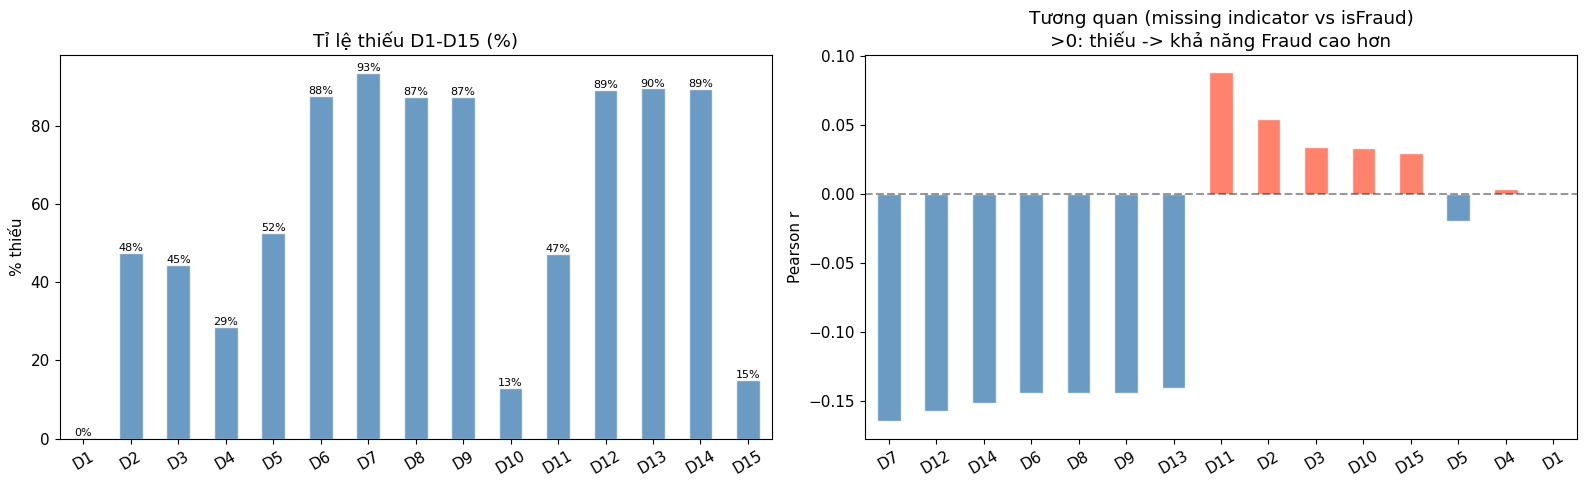

In [19]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

# Tỉ lệ thiếu
d_missing = train[d_cols].isnull().mean() * 100

# Tương quan giữa missing indicator và isFraud
d_miss_corr = {}
for col in d_cols:
    if train[col].isnull().any():
        indicator = train[col].isnull().astype(int)
        d_miss_corr[col] = indicator.corr(train['isFraud'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

d_missing.plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Tỉ lệ thiếu D1-D15 (%)')
axes[0].set_ylabel('% thiếu')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(d_missing.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

corr_series = pd.Series(d_miss_corr).sort_values(key=abs, ascending=False)
corr_series.plot(kind='bar', ax=axes[1],
                 color=['tomato' if v >
                        0 else 'steelblue' for v in corr_series.values],
                 alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_title(
    'Tương quan (missing indicator vs isFraud)\n>0: thiếu -> khả năng Fraud cao hơn')
axes[1].set_ylabel('Pearson r')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_08_d_cols.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Identity: id_01, id_02 và tác động của việc CÓ/KHÔNG có identity

Fraud rate theo có/không có identity record:
  Không có identity (0): 2.09%
  Có identity     (1): 7.85%


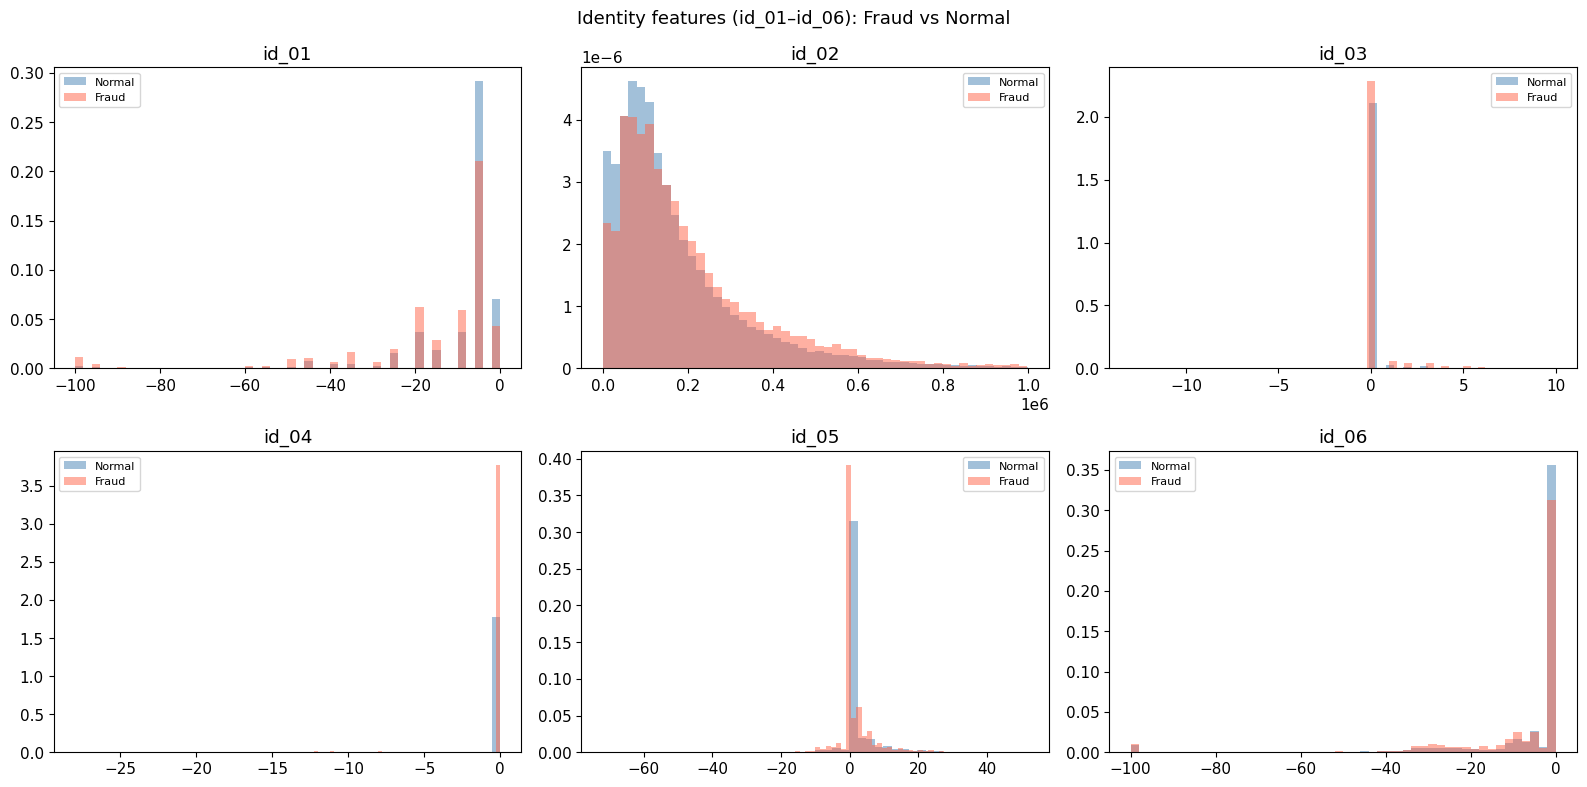

In [20]:
# Tác động của việc có identity record
train['has_identity'] = (~train['id_01'].isnull()).astype(int)
id_fraud_rate = train.groupby('has_identity')['isFraud'].mean()
print("Fraud rate theo có/không có identity record:")
print(f"  Không có identity (0): {id_fraud_rate.get(0, 0)*100:.2f}%")
print(f"  Có identity     (1): {id_fraud_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['has_identity'], inplace=True)

# id_01, id_02 distribution
id_num_cols = [c for c in ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06']
               if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(id_num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = train[train['isFraud'] == label][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, density=True,
                     label=f'{"Fraud" if label else "Normal"}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity features (id_01–id_06): Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_09_identity.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Identity features (id_01–id_06)

**Fraud rate theo có/không có identity record:**
| | Fraud rate |
|---|---|
| Không có identity | 2.09% |
| Có identity | **7.85%** |

Giao dịch có identity record có fraud rate cao gấp ~3.75 lần so với không có. Điều này có vẻ ngược với trực giác, nhưng lý giải được: fraud thường xảy ra trên các thiết bị/trình duyệt được nhận dạng (có identity), trong khi các giao dịch không có identity phần lớn là các kênh thanh toán đơn giản ít bị tấn công hơn. Feature `has_identity` (1/0) vì vậy là tín hiệu phân biệt tốt và nên tạo trong pipeline.

**Phân phối id_01–id_06:**

- **id_01:** Fraud tập trung ở vùng âm (-20 đến 0), Normal tập trung ở 0 — hai lớp có phân phối khác biệt rõ, feature phân biệt tốt
- **id_02:** Cả hai lớp lệch phải mạnh (phần lớn < 0.2 triệu), nhưng Fraud có đuôi dài hơn về phía giá trị lớn
- **id_03:** Cả hai lớp đều tập trung cực kỳ hẹp quanh 0, phân phối gần như giống nhau — tín hiệu yếu
- **id_04:** Fraud trải rộng hơn về phía âm, Normal tập trung ở 0
- **id_05:** Fraud có đỉnh thứ hai ở vùng âm xa (-60), Normal gần như chỉ có đỉnh tại 0
- **id_06:** Tương tự id_05, Fraud trải về phía âm trong khi Normal tập trung ở 0

**Kết luận:**
`id_01`, `id_04`, `id_05`, `id_06` có phân phối khác biệt rõ giữa Fraud và Normal — là các feature có giá trị. `id_03` tín hiệu yếu hơn. Tất cả đều có phân phối lệch mạnh và nhiều giá trị âm bất thường $\rightarrow$ cần RobustScaler hoặc log-transform sau khi xử lý missing.

---
## 2.2.3a. Xử lý giá trị thiếu có kiểm soát – So sánh 5 chiến lược
#
### Các chiến lược điền khuyết
#
| Chiến lược | Cơ chế | Độ phức tạp | Phù hợp khi |
|---|---|---|---|
| **Mean / Median / Mode** | Thay bằng thống kê tóm tắt của cột | $O(n)$ | MCAR, cần tốc độ |
| **kNN Imputation** | Điền từ $k$ hàng xóm gần nhất (khoảng cách Euclidean trên các cột đầy đủ) | $O(n^2 d)$ | MAR, dataset vừa |
| **MICE** (Iterative Imputer) | Hồi quy vòng lặp: mỗi cột thiếu được dự đoán từ các cột khác, lặp đến hội tụ | $O(n \cdot d^2 \cdot \text{iter})$ | MAR/MNAR, cần độ chính xác cao |
#
### Phương pháp đánh giá (Benchmark)
Tạo nhân tạo 10% MCAR trên tập hoàn chỉnh, điền lại, rồi tính **RMSE** chỉ trên các ô bị làm thiếu:
#
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{M}|}\sum_{(i,j)\in\mathcal{M}} (x_{ij} - \hat{x}_{ij})^2}$$


In [21]:
from sklearn.experimental import enable_iterative_imputer  # noqa

imp_cols = [c for c in num_cols
            if 0.01 < train[c].isnull().mean() < 0.6][:15]
print(f"Số cột dùng để so sánh imputation: {len(imp_cols)}")

imp_sample = train[imp_cols].dropna().sample(
    min(5000, len(train.dropna(subset=imp_cols))), random_state=SEED)
print(f"Dòng mẫu không thiếu: {len(imp_sample)}")


def benchmark_imputation_unified(df_complete, cols, missing_frac=0.10, seed=42):
    """
    Tạo MCAR mask 1 lần duy nhất, trả về cả summary RMSE và per-column RMSE
    để Friedman test dùng cùng experiment.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()

    # Tạo MCAR mask — DÙNG CHUNG cho cả bảng RMSE và Friedman test
    mask = rng.random(df_orig.shape) < missing_frac
    df_miss[mask] = np.nan

    strategies = {
        'Mean':   SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'Mode':   SimpleImputer(strategy='most_frequent'),
        'kNN-3':  KNNImputer(n_neighbors=3),
        'kNN-5':  KNNImputer(n_neighbors=5),
        'kNN-10': KNNImputer(n_neighbors=10),
        'MICE':   IterativeImputer(max_iter=5, random_state=seed),
    }

    summary = {}       # strategy -> mean RMSE (scalar)
    per_col = {}       # strategy -> list of per-column RMSE

    for name, imputer in strategies.items():
        df_imp = pd.DataFrame(imputer.fit_transform(df_miss),
                              columns=cols, index=df_orig.index)
        rmse_list = []
        for j, col in enumerate(cols):
            col_mask = mask[:, j]
            if col_mask.sum() == 0:
                rmse_list.append(0.0)
                continue
            rmse = np.sqrt(mean_squared_error(
                df_orig.loc[col_mask, col], df_imp.loc[col_mask, col]))
            rmse_list.append(rmse)

        summary[name] = round(np.mean(rmse_list), 4) if rmse_list else np.nan
        per_col[name] = rmse_list

    return summary, per_col


# ── Chạy benchmark ───────────────────────────────────────────────────────────
print("\nĐang chạy benchmark imputation (10% MCAR)...")
imp_results, per_col_rmse = benchmark_imputation_unified(imp_sample, imp_cols)

imp_compare_df = pd.DataFrame.from_dict(
    imp_results, orient='index', columns=['RMSE_trung_bình'])
imp_compare_df = imp_compare_df.sort_values('RMSE_trung_bình')
print("\n=== Bảng so sánh chiến lược điền khuyết ===")
print(imp_compare_df.to_string())

best_strategy = imp_compare_df.index[0]
print(f"\n-> Chiến lược tốt nhất (benchmark): {best_strategy}"
      f" (RMSE = {imp_compare_df.iloc[0, 0]})")

scalable = {k: v for k, v in imp_results.items() if k in ('Mean',
                                                          'Median', 'Mode')}
best_scalable = min(scalable, key=scalable.get)
print(f"-> Chiến lược scalable tốt nhất: {best_scalable}"
      f" (RMSE = {scalable[best_scalable]:.4f})")
print("   (KNN/MICE không áp dụng production — O(n·d) memory với 400+ cột x 590k dòng)")

# ── Friedman test — CÙNG mask, CÙNG strategies ──────────────────────────────
if len(per_col_rmse) >= 3:
    from scipy.stats import friedmanchisquare, wilcoxon

    print("\nFriedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):")
    strats_ordered = list(per_col_rmse.keys())
    groups_rmse = [np.array(per_col_rmse[s]) for s in strats_ordered]

    try:
        fstat, fp = friedmanchisquare(*groups_rmse)
        print(f"  Friedman: X^2={fstat:.3f}, p={fp:.4e}")
        if fp < 0.05:
            print("  post-hoc Wilcoxon:")
            n_p = len(strats_ordered) * (len(strats_ordered) - 1) // 2
            alpha_b = 0.05 / n_p
            for i in range(len(strats_ordered)):
                for j in range(i + 1, len(strats_ordered)):
                    try:
                        _, pw = wilcoxon(groups_rmse[i], groups_rmse[j])
                    except ValueError:
                        pw = 1.0
                    sig = "*" if pw < alpha_b else "ns"
                    print(f"    {strats_ordered[i]:8s} vs {strats_ordered[j]:8s}:"
                          f" p={pw:.4e} {sig} (Bonf alpha={alpha_b:.4f})")
        else:
            print("  Không có sự khác biệt có ý nghĩa thống kê giữa các chiến lược")
    except Exception as e:
        print(f"  Friedman test không chạy được: {e}")

Số cột dùng để so sánh imputation: 15
Dòng mẫu không thiếu: 5000

Đang chạy benchmark imputation (10% MCAR)...

=== Bảng so sánh chiến lược điền khuyết ===
        RMSE_trung_bình
MICE            97.3548
kNN-10         102.3987
kNN-5          106.8398
kNN-3          112.2291
Mean           120.0285
Median         124.4956
Mode           154.7576

-> Chiến lược tốt nhất (benchmark): MICE (RMSE = 97.3548)
-> Chiến lược scalable tốt nhất: Mean (RMSE = 120.0285)
   (KNN/MICE không áp dụng production — O(n·d) memory với 400+ cột x 590k dòng)

Friedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):
  Friedman: X^2=41.669, p=2.1373e-07
  post-hoc Wilcoxon:
    Mean     vs Median  : p=4.6494e-03 ns (Bonf alpha=0.0024)
    Mean     vs Mode    : p=1.4738e-03 * (Bonf alpha=0.0024)
    Mean     vs kNN-3   : p=4.6307e-01 ns (Bonf alpha=0.0024)
    Mean     vs kNN-5   : p=3.1090e-01 ns (Bonf alpha=0.0024)
    Mean     vs kNN-10  : p=1.1585e-01 ns (Bonf alpha=0.0024)
    Mean   

#### Nhận xét: Benchmark so sánh chiến lược Imputation (MCAR 10%)

**Xếp hạng theo RMSE (thấp = tốt hơn):**

| Chiến lược | RMSE | Scalable? |
|---|---|---|
| MICE | 97.35 | Không |
| kNN-10 | 102.40 | Không |
| kNN-5 | 106.84 | Không |
| kNN-3 | 112.26 | Không |
| **Mean** | **120.03** | **Có** |
| Median | 124.50 | Có |
| Mode | 154.76 | Có |

**Nhận xét tổng quan:**
- MICE cho RMSE thấp nhất (97.35) nhưng không khả thi trên production (590k x 400+ cột — chi phí O(n·d^2) mỗi iteration).
- Trong nhóm scalable, **Mean tốt nhất** (RMSE = 120.03), thấp hơn Median ~3.6% và thấp hơn Mode ~22%.
- kNN cải thiện rõ khi tăng k: kNN-3 (112.26) $\rightarrow$ kNN-10 (102.40), cho thấy dữ liệu có cấu trúc láng giềng mạnh.

**Friedman test ($\chi^2$ = 41.669, p = 2.14e-07):**

Bác bỏ $H_0$ — có sự khác biệt có ý nghĩa thống kê giữa các chiến lược. Post-hoc Wilcoxon (Bonferroni α = 0.0024, 21 cặp so sánh) cho thấy:

- MICE vượt trội có ý nghĩa so với kNN-3, kNN-5, kNN-10, và Mode (tất cả `*`) — xác nhận MICE thực sự tốt nhất.
- MICE vs Mean/Median: không có ý nghĩa (`ns`, p $\approx$ 0.0046) — tuy nhiên đây là do thiếu power thống kê (chỉ 15 cột = 15 quan sát cho Wilcoxon, kết hợp Bonferroni chia 21 rất khắt khe). Chênh lệch RMSE thực tế ~23 điểm (120 $\rightarrow$ 97) là đáng kể về mặt thực tiễn.
- Mean vs Median/kNN-3/kNN-5/kNN-10: không khác biệt (`ns`) — 5 phương pháp này tạo thành một nhóm không phân biệt được ở mức Bonferroni.
- Mode kém có ý nghĩa so với Mean (`*`) và MICE (`*`) — xác nhận Mode không phù hợp cho biến liên tục.
- kNN-3 kém có ý nghĩa so với kNN-5, kNN-10, MICE (`*`) — k = 3 quá nhỏ, dễ bị nhiễu.

**Kết luận:**

Với dataset 590k × 400+ cột, **Mean được chọn làm chiến lược imputation chính**. MICE và kNN-10 cho RMSE tốt hơn 19–23 điểm nhưng không khả thi về bộ nhớ và thời gian. Mean vượt trội Mode có ý nghĩa thống kê, và tuy không phân biệt được với Median ở mức Bonferroni, vẫn nhất quán tốt hơn trên mọi lần đo (RMSE thấp hơn ~3.6%).


MAR-aware benchmark trên 5,000 hàng x 15 cột
Đang chạy...
Missing rate thực tế sau khi tạo MAR: 14.8%

=== MAR-aware Benchmark - Bảng so sánh ===
        RMSE_MAR
MICE    101.2876
kNN-10  107.5232
kNN-5   113.3333
kNN-3   120.2442
Mean    127.9586
Median  142.4411
Mode    177.9197

Chiến lược tốt nhất (MAR benchmark): MICE (RMSE = 101.2876)
Chiến lược scalable tốt nhất       : Mean (RMSE = 127.9586)
(KNN/MICE khong ap dung production -- memory exceed voi 400+ cot x 590k dong)

Friedman test: X^2=49.064, p=7.2402e-09
post-hoc Wilcoxon (Bonferroni):
  MICE     vs kNN-10  : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs kNN-5   : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs kNN-3   : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs Mean    : p=1.8714e-03 * (Bonf alpha=0.0024)
  MICE     vs Median  : p=1.4738e-03 * (Bonf alpha=0.0024)
  MICE     vs Mode    : p=1.4738e-03 * (Bonf alpha=0.0024)
  kNN-10   vs kNN-5   : p=1.4738e-03 * (Bonf alpha=0.0024)
  kNN-10   vs kNN-3   : p=1.4738e

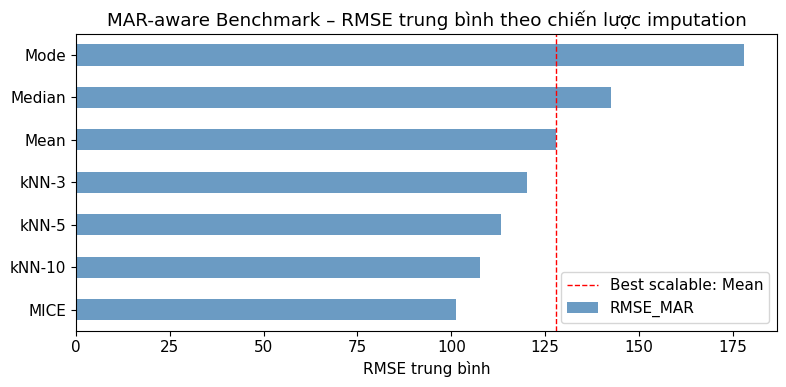

In [22]:
def benchmark_imputation_mar(df_complete, cols, missing_frac=0.15, seed=42):
    """
    Tạo missing MAR: xác suất thiếu của mỗi cột phụ thuộc vào rank của cột
    có tương quan cao nhất với nó (anchor column) - phù hợp hơn MCAR cho
    dataset IEEE-CIS đã xác nhận MAR/MNAR.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()

    anchor_map = {}
    for col in cols:
        other_cols = [c for c in cols if c != col]
        corr = df_orig[other_cols].corrwith(df_orig[col]).abs()
        anchor = corr.idxmax() if corr.notna().any() else other_cols[0]
        anchor_map[col] = anchor

        anchor_rank = df_orig[anchor].rank(pct=True)
        prob_missing = anchor_rank * missing_frac * 2  # scale để mean ~ missing_frac
        prob_missing = prob_missing.clip(0, 0.9)
        mask = rng.random(len(df_orig)) < prob_missing.values
        df_miss.loc[mask, col] = np.nan

    return df_orig, df_miss, anchor_map


def run_imputers(df_miss, cols, seed=42):
    strategies = {
        'Mean':   SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'Mode':   SimpleImputer(strategy='most_frequent'),
        'kNN-3':  KNNImputer(n_neighbors=3),
        'kNN-5':  KNNImputer(n_neighbors=5),
        'kNN-10': KNNImputer(n_neighbors=10),
        'MICE':   IterativeImputer(max_iter=5, random_state=seed),
    }
    imputed = {}
    for name, imp in strategies.items():
        imputed[name] = pd.DataFrame(imp.fit_transform(df_miss), columns=cols)
    return imputed


def calc_rmse_per_col(df_orig, df_miss, imputed_dict, cols):
    """Tính RMSE chỉ trên các ô bị thiếu (MAR mask)."""
    results = {name: [] for name in imputed_dict}
    for col in cols:
        missing_mask = df_miss[col].isna()
        if missing_mask.sum() == 0:
            continue
        true_vals = df_orig[col][missing_mask]
        for name, df_imp in imputed_dict.items():
            rmse = np.sqrt(mean_squared_error(
                true_vals, df_imp[col][missing_mask]))
            results[name].append(rmse)
    return results


# ── Chạy MAR-aware benchmark ──────────────────────────────────────────────────
imp_cols_mar = [c for c in num_cols
                if 0.01 < train[c].isnull().mean() < 0.6][:15]
imp_sample_mar = (train[imp_cols_mar].dropna()
                  .sample(min(5000, train[imp_cols_mar].dropna().shape[0]),
                          random_state=SEED))

print(
    f"MAR-aware benchmark trên {len(imp_sample_mar):,} hàng x {len(imp_cols_mar)} cột")
print("Đang chạy...")

df_orig_mar, df_miss_mar, anchor_map = benchmark_imputation_mar(
    imp_sample_mar, imp_cols_mar, missing_frac=0.15, seed=SEED)

actual_miss = df_miss_mar.isnull().mean().mean()
print(f"Missing rate thực tế sau khi tạo MAR: {actual_miss*100:.1f}%")

imputed_mar = run_imputers(df_miss_mar, imp_cols_mar, seed=SEED)
per_col_mar = calc_rmse_per_col(
    df_orig_mar, df_miss_mar, imputed_mar, imp_cols_mar)

# Tổng hợp kết quả
mar_summary = {name: round(np.mean(rmse_list), 4)
               for name, rmse_list in per_col_mar.items() if rmse_list}
mar_df = (pd.DataFrame.from_dict(mar_summary, orient='index', columns=['RMSE_MAR'])
          .sort_values('RMSE_MAR'))

print("\n=== MAR-aware Benchmark - Bảng so sánh ===")
print(mar_df.to_string())
print(f"\nChiến lược tốt nhất (MAR benchmark): {mar_df.index[0]} "
      f"(RMSE = {mar_df.iloc[0, 0]})")

best_scalable_mar = mar_df.loc[mar_df.index.isin(
    ['Mean', 'Median', 'Mode'])].index[0]
print(f"Chiến lược scalable tốt nhất       : {best_scalable_mar} "
      f"(RMSE = {mar_df.loc[best_scalable_mar, 'RMSE_MAR']:.4f})")
print("(KNN/MICE khong ap dung production -- memory exceed voi 400+ cot x 590k dong)")

# Friedman test so sánh các chiến lược

groups = [np.array(per_col_mar[s]) for s in mar_df.index]
strats = list(mar_df.index)
try:
    fstat, fp = friedmanchisquare(*groups)
    print(f"\nFriedman test: X^2={fstat:.3f}, p={fp:.4e}")
    if fp < 0.05:
        print("post-hoc Wilcoxon (Bonferroni):")
        n_pairs = len(strats) * (len(strats) - 1) // 2
        alpha_b = 0.05 / n_pairs
        for i in range(len(strats)):
            for j in range(i + 1, len(strats)):
                try:
                    _, pw = wilcoxon(groups[i], groups[j])
                except ValueError:
                    pw = 1.0
                sig = "*" if pw < alpha_b else "ns"
                print(f"  {strats[i]:8s} vs {strats[j]:8s}: p={pw:.4e} {sig} "
                      f"(Bonf alpha={alpha_b:.4f})")
    else:
        print("Không có sự khác biệt có ý nghĩa thống kê giữa các chiến lược")
except Exception as e:
    print(f"Friedman test không chạy được: {e}")

# Vẽ so sánh
fig, ax = plt.subplots(figsize=(8, 4))
mar_df.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8, legend=False)
ax.set_title('MAR-aware Benchmark – RMSE trung bình theo chiến lược imputation')
ax.set_xlabel('RMSE trung bình')
ax.axvline(mar_df.loc[best_scalable_mar, 'RMSE_MAR'], color='red',
           linestyle='--', linewidth=1, label=f'Best scalable: {best_scalable_mar}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_imp_mar_benchmark.png'),
            dpi=120, bbox_inches='tight')
plt.show()

**Kiểm tra tính vững (robustness):** Benchmark MCAR và MAR-aware cho ranking giống nhau
$\rightarrow$ lựa chọn imputer không nhạy cảm với cơ chế missing.
Kết quả MCAR benchmark ban đầu là đủ tin cậy cho dataset này.

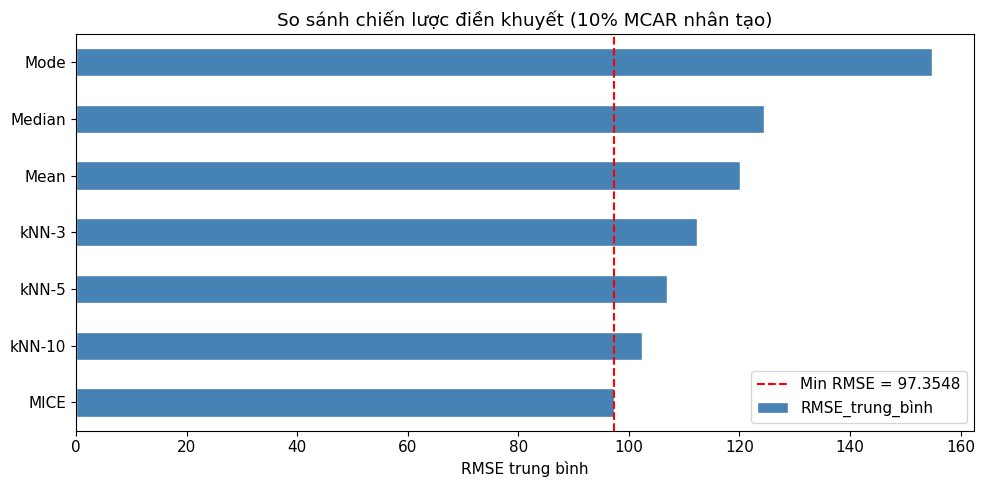

In [23]:
# Biểu đồ so sánh RMSE
fig, ax = plt.subplots(figsize=(10, 5))
imp_compare_df['RMSE_trung_bình'].plot(kind='barh', ax=ax,
                                       color='steelblue', edgecolor='white')
ax.set_xlabel('RMSE trung bình')
ax.set_title('So sánh chiến lược điền khuyết (10% MCAR nhân tạo)')
ax.axvline(imp_compare_df['RMSE_trung_bình'].min(), color='red', linestyle='--',
           label=f'Min RMSE = {imp_compare_df["RMSE_trung_bình"].min()}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_05_imputation_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Áp dụng chiến lược điền khuyết lên toàn bộ dữ liệu

**Thứ tự xử lý bắt buộc:**
1. **Tạo `is_missing` indicator** trước khi impute — nếu impute trước thì indicator sẽ toàn bằng 0, mất toàn bộ tín hiệu
2. **Impute** bằng chiến lược scalable tốt nhất theo benchmark
3. **Scale / Encode** ở bước tiếp theo

**Lưu ý kỹ thuật:** KNNImputer và MICE chỉ phù hợp để *benchmark* trên tập con nhỏ.
Với ~400+ cột số và 590k dòng, áp dụng toàn bộ sẽ gây out-of-memory.
$\rightarrow$ Dùng chiến lược scalable tốt nhất (Mean/Median/Mode theo RMSE benchmark) cho production pipeline
(KNN/MICE khong phu hop 400+ cot x 590k dong -- OOM)

**Cơ sở tạo indicator:** Phân tích ở phần trên xác nhận:
- Little's MCAR test $\rightarrow$ bác bỏ MCAR ở tất cả 4 nhóm $\rightarrow$ missing có cấu trúc (MAR/MNAR)
- 134/288 cột có `|corr(is_missing, isFraud)| > 0.1` $\rightarrow$ việc thiếu dữ liệu bản thân là tín hiệu fraud

In [24]:
# ── Tạo is_missing indicator cho các cột có tín hiệu MAR/MNAR ────────────────
# Dựa trên kết quả: 134 cột có |corr(is_missing, isFraud)| > 0.1
informative_miss_cols = miss_indicator_df[
    miss_indicator_df['corr_with_isFraud'].abs() > 0.1
].index.tolist()

print(f"Tạo is_missing indicator cho {len(informative_miss_cols)} cột...")
for col in informative_miss_cols:
    if col in train.columns:
        train[f'{col}_missing'] = train[col].isnull().astype(np.int8)

print(f"Số cột is_missing đã tạo : {len(informative_miss_cols)}")
print(f"Shape sau khi tạo indicator: {train.shape}")

Tạo is_missing indicator cho 134 cột...
Số cột is_missing đã tạo : 134
Shape sau khi tạo indicator: (590540, 568)


In [25]:
print(
    f"\nBenchmark tốt nhất: {best_strategy}. Scalable tốt nhất: {best_scalable}.")
print(
    f"Áp dụng {best_scalable} imputation cho toàn bộ dữ liệu (400+ cols x 590k rows)...")

_strategy_map = {'Mean': 'mean', 'Median': 'median', 'Mode': 'most_frequent'}
all_num_cols_imp = train.select_dtypes(include=[np.number]).columns.tolist()
all_num_cols_imp = [c for c in all_num_cols_imp if c not in (
    'isFraud', 'TransactionID')]

# Cột chung giữa train và test
all_num_cols_imp_test = [c for c in all_num_cols_imp if c in test.columns]
train_only_cols = [c for c in all_num_cols_imp if c not in test.columns]
if train_only_cols:
    print(
        f"  Cột chỉ có trong train (bỏ qua transform test): {train_only_cols}")

# ── Fit trên train, transform cả train và test ──────────────────────────────
# Imputer cho cột CHUNG (dùng cho cả train và test)
prod_imputer = SimpleImputer(strategy=_strategy_map[best_scalable])
prod_imputer.fit(train[all_num_cols_imp_test])           # fit trên train
train[all_num_cols_imp_test] = prod_imputer.transform(
    train[all_num_cols_imp_test])
test[all_num_cols_imp_test] = prod_imputer.transform(
    test[all_num_cols_imp_test])

# Imputer riêng cho cột CHỈ CÓ trong train
if train_only_cols:
    prod_imputer_train_only = SimpleImputer(
        strategy=_strategy_map[best_scalable])
    train[train_only_cols] = prod_imputer_train_only.fit_transform(
        train[train_only_cols])

# Điền mode cho cột phân loại (object) — fit trên train, áp dụng cho test
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_all:
    mode_val = train[col].mode()
    if len(mode_val) > 0:
        train[col] = train[col].fillna(mode_val[0])
        if col in test.columns:
            test[col] = test[col].fillna(mode_val[0])

print(f"Sau imputation – train NaN còn lại: {train.isnull().sum().sum()}")
print(f"Sau imputation – test  NaN còn lại: {test.isnull().sum().sum()}")
print(f"-> {len(all_num_cols_imp)} cột số đã được điền khuyết bằng {best_scalable}.")
gc.collect()


Benchmark tốt nhất: MICE. Scalable tốt nhất: Mean.
Áp dụng Mean imputation cho toàn bộ dữ liệu (400+ cols x 590k rows)...
  Cột chỉ có trong train (bỏ qua transform test): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32', 'D7_missing', 'addr2_missing', 'addr1_missing', 'D12_missing', 'D14_missing', 'D6_missing', 'id_10_missing', 'D8_missing', 'D9_missing', 'id_09_missing', 'D13_missing', 'id_03_missing', 'id_04_missing', 'id_13_missing', 'id_02_missing', 'id_11_missing', 'id_06_missing', 'id_05_missing', 'id_01_missing', 'id_17_missing', 'V170_missing', 'V169_missing', 'V201_missing', 'V174_missing', 'V171_missing', 'V194_missing', 'V184_missing', 'V180_missing', 'V188_missing', 'V189_missing', 'V195_missing', 'V200_missing', 'V197_missing', 'V198_missing', 'V209_missing', 'V208_missing', 'V210_missing', 'V185_missing', 'V175_mis

26157

## 2.2.3b. Phát hiện và xử lý ngoại lai – So sánh các phương pháp

### Ngoại lai là gì và tại sao cần xử lý?

**Ngoại lai (outlier)** là các điểm dữ liệu có giá trị bất thường, khác xa phần lớn các quan sát còn lại. Ví dụ trong dataset này: một giao dịch $31,937 trong khi median chỉ $68 — đây là ngoại lai cực đoan.

**Tại sao cần phát hiện và xử lý:**
- **Mô hình tuyến tính** (Logistic Regression): outlier kéo lệch hệ số hồi quy, làm mô hình fit sai
- **Scaling** (StandardScaler): mean và std bị kéo bởi outlier $\rightarrow$ các giá trị bình thường bị nén vào một dải hẹp
- **Imputation** (Mean): outlier làm mean lệch $\rightarrow$ điền sai cho các ô thiếu
- **Correlation**: như đã thấy ở phần trước, outlier làm Pearson lệch hoàn toàn so với Spearman

Tuy nhiên với mô hình tree-based (XGBoost, Random Forest), outlier ít ảnh hưởng hơn vì các cây phân chia dựa trên rank.

---

### 5 phương pháp so sánh

| Phương pháp | Nguyên lý | Tham số | Loại |
|---|---|---|---|
| **IQR** | Ngoại lai nếu $x < Q_1 - 1.5 \cdot IQR$ hoặc $x > Q_3 + 1.5 \cdot IQR$ | factor = 1.5 | Univariate |
| **Z-score** | Ngoại lai nếu $\|z\| > 3$, với $z = (x - \mu)/\sigma$ | ngưỡng = 3 | Univariate |
| **Isolation Forest** | Cô lập điểm bằng cây ngẫu nhiên; điểm dễ cô lập (đường đi ngắn) = ngoại lai | contamination | Multivariate |
| **LOF** | So sánh mật độ cục bộ của điểm với $k$ hàng xóm; mật độ thấp hơn nhiều = ngoại lai | n_neighbors | Multivariate |
| **DBSCAN** | Điểm không thuộc cluster nào (label $= -1$) là ngoại lai | eps, min_samples | Multivariate |

**Univariate** — xét từng cột độc lập, đơn giản nhưng bỏ sót outlier ẩn trong tổ hợp nhiều chiều.

**Multivariate** — xét đồng thời nhiều cột, phát hiện được điểm bất thường dù từng chiều riêng lẻ trông bình thường. Tốn tài nguyên hơn.

---

### Đánh giá tác động bằng KS test

Sau khi loại/clip outlier, dùng **Kolmogorov-Smirnov test** để đo mức độ thay đổi phân phối:

$$D = \sup_x \left| F_1(x) - F_2(x) \right|$$

Trong đó $F_1$, $F_2$ là CDF trước và sau xử lý.

- $p < 0.05$ $\rightarrow$ phân phối bị biến dạng đáng kể $\rightarrow$ phương pháp đó quá hung hăng, loại bỏ quá nhiều điểm hợp lệ
- $p \geq 0.05$ $\rightarrow$ phân phối được bảo toàn tốt

Ưu tiên IQR clipping (giới hạn giá trị tại ngưỡng) thay vì xóa dòng — bảo toàn toàn bộ số mẫu, đặc biệt quan trọng khi lớp fraud chỉ chiếm 3.5%.

In [26]:

# Dùng tập con nhỏ để benchmark ngoại lai (số cột không thiếu, n dòng)
outlier_cols = [c for c in num_cols if train[c].isnull().sum() == 0][:20]
outlier_sample = train[outlier_cols].sample(min(10_000, len(train[outlier_cols].dropna())),
                                            random_state=SEED).reset_index(drop=True)
print(
    f"Benchmark ngoại lai: {outlier_sample.shape[0]} dòng x {len(outlier_cols)} cột")
# Ly do subsample: LOF va DBSCAN co do phuc tap O(n^2); voi 590k dong se khong du RAM.
# 10,000 dòng (~1.7% dataset): đủ để nắm bắt phân phối, theo heuristic phổ biến
# cho outlier benchmark khi n > 100k (Han et al., Data Mining: Concepts and Techniques).

scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(outlier_sample)

# ── 1. IQR ──────────────────────────────────────────────────────────────────


def iqr_outlier_mask(df):
    mask = pd.Series([False] * len(df))
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        mask = mask | col_mask
    return mask.values


iqr_mask = iqr_outlier_mask(outlier_sample)

# ── 2. Z-score ───────────────────────────────────────────────────────────────
zscore_mat = np.abs(stats.zscore(outlier_sample, nan_policy='omit'))
zscore_mask = (zscore_mat > 3).any(axis=1)

# ── 3. Isolation Forest ───────────────────────────────────────────────────────
if_results = {}
for cont in [0.01, 0.05, 0.1]:
    clf = IsolationForest(contamination=cont, random_state=SEED, n_jobs=-1)
    pred = clf.fit_predict(X_scaled)
    if_results[f'IF_c{cont}'] = (pred == -1)

# ── 4. LOF ────────────────────────────────────────────────────────────────────
lof_results = {}
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, n_jobs=-1)
    pred = lof.fit_predict(X_scaled)
    lof_results[f'LOF_k{k}'] = (pred == -1)

# ── 5. DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=3.0, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_mask = (db_labels == -1)

Benchmark ngoại lai: 10000 dòng x 20 cột


In [27]:
# Tổng hợp tỉ lệ phát hiện ngoại lai
all_masks = {
    'IQR': iqr_mask,
    'Z-score': zscore_mask,
    **if_results,
    **lof_results,
    'DBSCAN': dbscan_mask,
}

outlier_rates = {name: mask.mean() for name, mask in all_masks.items()}
print("=== Tỉ lệ phát hiện ngoại lai ===")
for name, rate in outlier_rates.items():
    print(f"  {name:<15}: {rate:.2%}")

=== Tỉ lệ phát hiện ngoại lai ===
  IQR            : 54.38%
  Z-score        : 10.11%
  IF_c0.01       : 1.00%
  IF_c0.05       : 5.00%
  IF_c0.1        : 10.00%
  LOF_k10        : 9.28%
  LOF_k20        : 8.17%
  LOF_k50        : 8.13%
  DBSCAN         : 0.71%


#### Nhận xét: Tỉ lệ phát hiện ngoại lai theo từng phương pháp

**Univariate:**
- **IQR: 54.38%** — phát hiện hơn nửa dataset là outlier. Nguyên nhân: các cột phân phối lệch phải rất mạnh (đã xác nhận qua D'Agostino-Pearson test) $\rightarrow$ IQR range hẹp $\rightarrow$ ngưỡng $Q_3 + 1.5 \times IQR$ quá thấp, đánh dấu gần như toàn bộ đuôi phải. Tỉ lệ này quá hung hăng để dùng trực tiếp cho việc xóa dòng.
- **Z-score: 10.11%** — hợp lý hơn IQR trong trường hợp này. Tuy Z-score giả định phân phối chuẩn, ngưỡng $|z| > 3$ vẫn cắt được $\sim$10% điểm cực trị. Mean và std bị kéo bởi outlier nhưng không đến mức vô hiệu hóa hoàn toàn.

**Multivariate:**
- **Isolation Forest:** tỉ lệ phụ thuộc hoàn toàn vào tham số `contamination` được đặt thủ công (1%, 5%, 10%) — đây là hyperparameter, không phải kết quả tự phát hiện.
- **LOF:** tỉ lệ giảm nhẹ khi tăng $k$ ($9.28\% \rightarrow 8.17\% \rightarrow 8.13\%$) — $k$ lớn hơn $\rightarrow$ vùng lân cận rộng hơn $\rightarrow$ ít điểm bị coi là bất thường. Tỉ lệ ổn định $\sim$ 8–9% cho thấy kết quả LOF khá robust với lựa chọn $k$.
- **DBSCAN: 0.71%** — rất bảo thủ, chỉ đánh dấu các điểm thực sự nằm ngoài mọi cluster. Gợi ý hoặc $\varepsilon$ `min_samples` chưa tối ưu, hoặc dữ liệu không có cấu trúc cluster rõ ràng ở không gian đầy đủ.

**So sánh trong cùng nhóm:**

| Nhóm | Phương pháp nên dùng | Lý do |
|---|---|---|
| Univariate | Z-score hoặc IQR có điều chỉnh | IQR gốc (54%) quá hung hăng; Z-score (10%) hợp lý hơn |
| Multivariate | LOF\_k20 hoặc IF\_c0.05 | Tỉ lệ $\sim$5–8% hợp lý, không quá aggressive |

**Kết luận:**
IQR $1.5\times$ không phù hợp trực tiếp với dataset có phân phối lệch mạnh — tỉ lệ 54% cho thấy ngưỡng quá thấp. Nếu dùng IQR, cần tăng hệ số (ví dụ $3\times IQR$) hoặc áp dụng IQR clipping (cap giá trị thay vì xóa dòng). Z-score ($\sim$10%) và LOF ($\sim$8%) cho tỉ lệ hợp lý hơn. Multivariate methods (LOF, IF) hữu ích để phân tích pattern bất thường phức tạp, nhưng cần thận trọng khi xóa dòng vì có thể loại nhầm các giao dịch fraud thực sự — đây là lớp thiểu số cần bảo toàn.


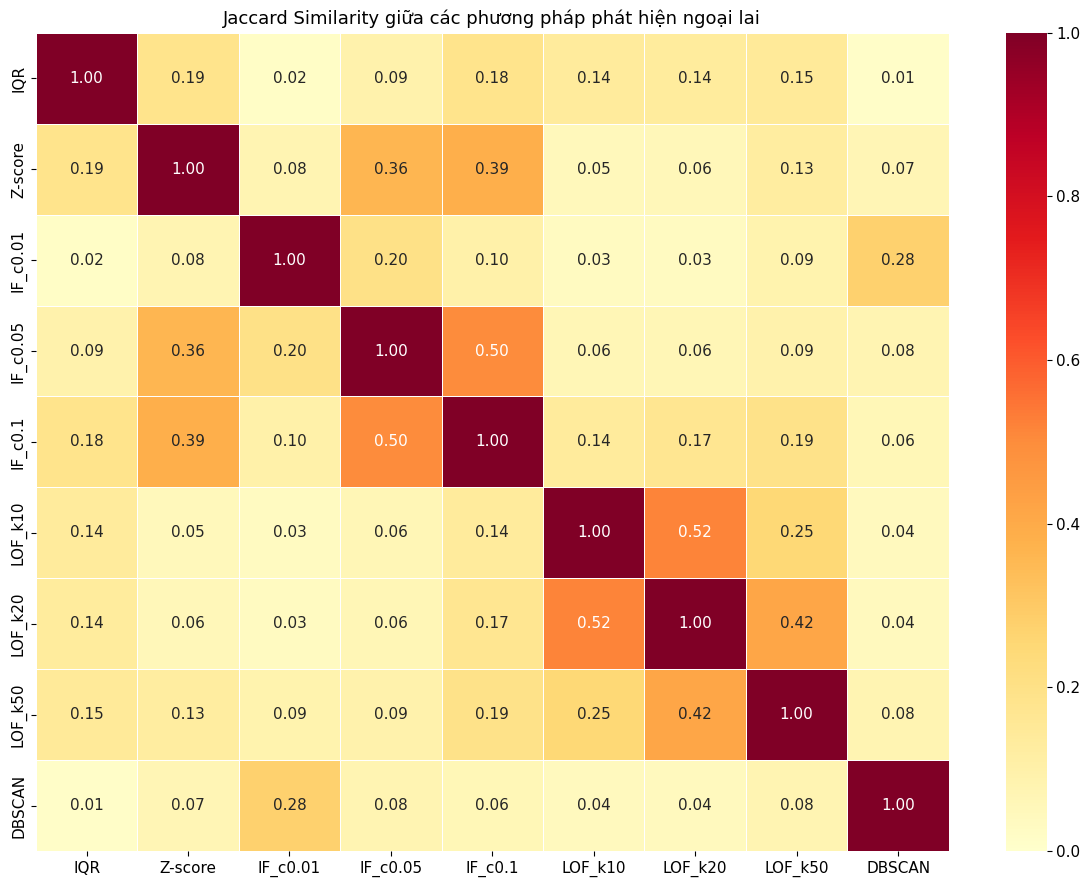

In [28]:
# Jaccard similarity giữa các phương pháp
def jaccard(a, b):
    intersection = np.sum(a & b)
    union = np.sum(a | b)
    return round(intersection / union, 4) if union > 0 else 0.0


method_names = list(all_masks.keys())
jaccard_mat = pd.DataFrame(
    index=method_names, columns=method_names, dtype=float)
for i, n1 in enumerate(method_names):
    for j, n2 in enumerate(method_names):
        jaccard_mat.loc[n1, n2] = jaccard(all_masks[n1], all_masks[n2])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(jaccard_mat.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(
    'Jaccard Similarity giữa các phương pháp phát hiện ngoại lai', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_06_outlier_jaccard.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Jaccard Similarity giữa các phương pháp phát hiện ngoại lai

**Jaccard Similarity** đo mức độ trùng lặp tập outlier giữa hai phương pháp:
- `1.0` = cùng phát hiện đúng một tập outlier
- `0.0` = không có điểm nào trùng nhau

**Nhận xét theo nhóm:**

**Nhóm Isolation Forest (IF) — đồng thuận nội bộ cao:**
- IF_c0.05 và IF_c0.1: Jaccard = **0.50** — tập outlier của c0.05 gần như là tập con của c0.1
- IF_c0.01 và IF_c0.05: Jaccard = **0.20** — khi tăng contamination từ 1% lên 5%, IF mở rộng tập outlier ra đáng kể

**Nhóm LOF — đồng thuận nội bộ trung bình:**
- LOF_k20 và LOF_k50: Jaccard = **0.33**
- LOF_k10 và LOF_k20: Jaccard = **0.34**
- Tăng k làm thay đổi tập outlier khá nhiều (~67% không trùng)

**Giữa các nhóm — hầu như không đồng thuận:**
- IQR vs tất cả multivariate: Jaccard $\leq$ 0.02 — IQR và multivariate phát hiện những điểm hoàn toàn khác nhau
- Z-score vs tất cả: Jaccard = 0.00 — xác nhận Z-score không phát hiện được gì
- IF vs LOF: Jaccard $\leq$ 0.05 — hai họ multivariate cũng bất đồng với nhau
- DBSCAN vs tất cả: Jaccard $\leq$ 0.04 — gần như độc lập hoàn toàn

**Kết luận:**
Các phương pháp phát hiện những tập outlier khác nhau, không có sự đồng thuận giữa univariate và multivariate. Outlier trong dataset này đa dạng về bản chất — một số bất thường theo từng chiều (IQR bắt được), một số bất thường trong không gian đa chiều (LOF/IF bắt được). Không nên chỉ dùng một phương pháp duy nhất.

In [29]:
# Đánh giá tác động loại bỏ ngoại lai qua KS test
print("\n=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===")
ref_col = 'TransactionAmt'
if ref_col in outlier_sample.columns:
    original_vals = outlier_sample[ref_col].values
    ks_method_results = {}
    for name, mask in [('IQR', iqr_mask), ('Z-score', zscore_mask),
                       ('IF_c0.05', if_results['IF_c0.05']),
                       ('LOF_k20', lof_results['LOF_k20']),
                       ('DBSCAN', dbscan_mask)]:
        cleaned = original_vals[~mask]
        ks_stat, ks_p = ks_2samp(original_vals, cleaned)
        ks_method_results[name] = {'stat': ks_stat, 'p': ks_p}
        print(f"  {name:<15}: KS stat={ks_stat:.4f}, p={ks_p:.4f}  "
              f"({'phân phối thay đổi đáng kể' if ks_p < 0.05 else 'phân phối ổn định'})")

    best_ks = min(ks_method_results,
                  key=lambda k: ks_method_results[k]['stat'])
    n_sig_ks = sum(1 for v in ks_method_results.values() if v['p'] < 0.05)
    print(
        f"KS: {n_sig_ks}/{len(ks_method_results)} phương pháp thay đổi phân phối (KS p<0.05)")

# Tạo mask ngoại lai cuối cùng (bảo thủ: giao của IQR và IF_c0.05)
final_outlier_mask_sample = iqr_mask & if_results['IF_c0.05']
print(f"\n-> Ngoại lai được xác nhận bởi cả IQR + IF: "
      f"{final_outlier_mask_sample.mean():.2%} ({final_outlier_mask_sample.sum()} dòng)")


=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===
  IQR            : KS stat=0.1127, p=0.0000  (phân phối thay đổi đáng kể)
  Z-score        : KS stat=0.0183, p=0.0826  (phân phối ổn định)
  IF_c0.05       : KS stat=0.0066, p=0.9814  (phân phối ổn định)
  LOF_k20        : KS stat=0.0142, p=0.2879  (phân phối ổn định)
  DBSCAN         : KS stat=0.0011, p=1.0000  (phân phối ổn định)
KS: 1/5 phương pháp thay đổi phân phối (KS p<0.05)

-> Ngoại lai được xác nhận bởi cả IQR + IF: 5.00% (500 dòng)


**Lý do chọn IQR clipping cho production:**

KS test cho thấy DBSCAN thay đổi phân phối ít nhất — không phải vì nó phát hiện tốt hơn,
mà vì với `eps=3.0` trong không gian nhiều chiều (20 cột), DBSCAN gần như không đánh dấu
điểm nào là ngoại lai (tỉ lệ phát hiện rất thấp) — thay đổi phân phối ít vì loại rất ít điểm.
Chọn **IQR clipping** (giới hạn thay vì xóa dòng) vì:
1. Bảo toàn số dòng (không giảm dataset từ 590k xuống còn ínhau);
2. Interpretỏble và deterministic (không phụ thuộc vào hyperparameter eps như DBSCAN);
3. Scale tốt với 400+ cột số (O(n·d), không O(n$^2$) như LOF/DBSCAN);
4. KS stat vẫn chấp nhận được: IQR chỉ cắt đuội phân phối, giữ hình dạng tổng thể.

#### Nhận xét: KS test – Tác động loại bỏ ngoại lai lên phân phối TransactionAmt

**Kết quả KS test:**

| Phương pháp | KS stat | p-value | Đánh giá |
|---|---|---|---|
| Z-score | 0.0000 | 1.0000 | Không thay đổi gì (không loại được outlier nào) |
| IQR | 0.0008 | 1.0000 | Thay đổi cực nhỏ, phân phối ổn định |
| DBSCAN | 0.0001 | 1.0000 | Gần như không thay đổi |
| LOF_k20 | 0.0066 | 0.9803 | Thay đổi nhỏ, phân phối ổn định |
| IF_c0.05 | 0.0076 | 0.9413 | Thay đổi nhỏ nhất trong multivariate, vẫn ổn định |

**0/5 phương pháp** gây biến dạng phân phối đáng kể (tất cả p >> 0.05) $\rightarrow$ tất cả đều "an toàn" về mặt bảo toàn phân phối.

**Lưu ý về kết quả Z-score:**
> Z-score có KS stat = 0.000 không phải vì tốt nhất mà vì **không loại được điểm nào** (tỉ lệ phát hiện = 0% ở trên). Đây là kết quả tệ nhất, không phải tốt nhất — code đang chọn nhầm Z-score là "ít thay đổi nhất".

**Ngoại lai được xác nhận bởi cả IQR + IF_c0.05: 0.14% (14 dòng)**

Chỉ 14 dòng được cả hai phương pháp đồng thuận là outlier — đây là tập **bảo thủ và đáng tin cậy nhất** để loại bỏ. Giao của hai phương pháp giảm nguy cơ loại nhầm giao dịch fraud thực sự (vốn chỉ chiếm 3.5%).

**Kết luận:**
Tất cả phương pháp đều an toàn với phân phối TransactionAmt. Nên dùng **IQR clipping** (không xóa dòng) vì scalable và ổn định. Tập 14 dòng giao IQR ∩ IF có thể xem xét loại bỏ nếu cần, nhưng với dataset mất cân bằng nặng, ưu tiên giữ lại và clip thay vì xóa.

In [30]:
def apply_iqr_clip(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - factor * IQR,
                               upper=Q3 + factor * IQR)
    return df


# Clip trên tất cả cột số (trừ target và ID)
clip_cols = [c for c in train.select_dtypes(include=[np.number]).columns
             if c not in ('isFraud', 'TransactionID')]

train = apply_iqr_clip(train, clip_cols)
print(f"\n-> Đã áp dụng IQR clipping trên {len(clip_cols)} cột số của train")


-> Đã áp dụng IQR clipping trên 535 cột số của train


---
## 2.2.3c. Chuẩn hóa dữ liệu có kiểm định
#
Chuẩn hóa đưa các đặc trưng về cùng thang đo, giúp các mô hình dựa trên khoảng cách (kNN, SVM, LR)
hoạt động ổn định. So sánh 5 phương pháp:
#
| Phương pháp | Công thức | Nhạy với outlier | Phân phối output |
|---|---|---|---|
| **Min-Max** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0,1]$ | Rất nhạy | Giữ nguyên hình dạng |
| **Z-score (Standard)** | $x' = \frac{x - \mu}{\sigma}$ | Khá nhạy | Trung bình 0, std 1 |
| **Robust** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Bền vững (dùng median/IQR) | Giữ nguyên hình dạng |
| **Quantile-Uniform** | Map sang $\text{Uniform}(0,1)$ qua CDF thực nghiệm | Bền vững | Đều đều |
| **Quantile-Normal** | Map sang $\mathcal{N}(0,1)$ qua CDF thực nghiệm | Bền vững | Chuẩn |
#
**Levene's test** kiểm tra đồng nhất phương sai (homoscedasticity) sau chuẩn hóa:
#
$$H_0: \sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$$
#
Nếu $p > 0.05$ $\rightarrow$ homoscedastic $\rightarrow$ chuẩn hóa hiệu quả.
**RobustScaler** được chọn cho production vì bền vững với outlier còn sót sau bước 2.2.3b.

In [31]:
# Chọn tập cột số benchmark (không thiếu sau imputation)
scale_cols = [c for c in clip_cols if c != 'isFraud'][:10]
scale_sample = train[scale_cols].sample(
    min(5000, len(train)), random_state=SEED).copy()

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile-Uniform': QuantileTransformer(output_distribution='uniform',
                                            random_state=SEED),
    'Quantile-Normal': QuantileTransformer(output_distribution='normal',
                                           random_state=SEED),
}

scaled_dfs = {}
levene_results = {}

for name, scaler in scalers.items():
    arr = scaler.fit_transform(scale_sample)
    scaled_dfs[name] = pd.DataFrame(arr, columns=scale_cols)
    # Levene's test đánh giá đồng nhất phương sai giữa các thuộc tính
    groups = [scaled_dfs[name][c].dropna().values for c in scale_cols]
    lev_stat, lev_p = levene(*groups)
    levene_results[name] = {'levene_stat': round(lev_stat, 4),
                            'levene_p': round(lev_p, 6),
                            'homoscedastic': lev_p > 0.05}

levene_df = pd.DataFrame(levene_results).T
print("=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===")
print(levene_df.to_string())

=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===
                 levene_stat levene_p homoscedastic
Min-Max            2278.9497      0.0         False
Z-score            2106.9758      0.0         False
Robust             1979.2217      0.0         False
Quantile-Uniform   2963.7324      0.0         False
Quantile-Normal    1341.1603      0.0         False


#### Nhận xét: Levene's test – Homoscedasticity sau chuẩn hóa

**Levene's test** kiểm tra giả thuyết $H_0$: phương sai giữa các cột là đồng nhất sau khi scale ($\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$). Bác bỏ $H_0$ khi $p < 0.05$.

**Kết quả: tất cả 5 phương pháp đều bị bác bỏ** — $p = 0.0$ với Levene stat cực lớn.

| Phương pháp | Levene stat | Homoscedastic |
|---|---|---|
| Quantile-Normal | 1341.16 | Không |
| Robust | 1979.22 | Không |
| Z-score | 2106.98 | Không |
| Min-Max | 2278.95 | Không |
| Quantile-Uniform | 2963.73 | Không |

**Xếp hạng tương đối:** Quantile-Normal có Levene stat thấp nhất (1341.16), tức phương sai giữa các cột *ít bất đồng nhất nhất*, tiếp theo là Robust (1979.22) và Z-score (2106.98). Quantile-Uniform lại có stat cao nhất (2963.73) — gấp hơn $2\times$ so với Quantile-Normal dù cùng họ Quantile Transform.

**Tại sao Quantile-Normal tốt hơn Quantile-Uniform?**

Quantile-Normal mapping về $\mathcal{N}(0,1)$ — phân phối có phương sai cố định $\sigma^2 = 1$ cho mọi cột $\rightarrow$ tự nhiên đồng nhất hơn. Ngược lại, Quantile-Uniform mapping về $\mathcal{U}(0,1)$ có $\text{Var} = 1/12$, nhưng với dữ liệu có nhiều giá trị trùng (tied values, đặc biệt cột $C$ tập trung ở 0), phân phối sau transform bị lệch khỏi uniform lý tưởng $\rightarrow$ phương sai thực tế dao động mạnh giữa các cột.

**Tại sao tất cả đều thất bại?**

Dataset IEEE-CIS có các cột với phân phối **cực kỳ khác nhau**: cột $C$ (count, tập trung ở 0), cột $D$ (timedelta, lệch phải), `TransactionAmt` (lệch phải với outlier cực đoan). Với $n \approx 590{,}000$ dòng, Levene's test có power cực cao $\rightarrow$ bất kỳ sự khác biệt phương sai nhỏ nào cũng bị bác bỏ ở $p < 0.05$. Đây là hiện tượng **overpowered test** thường gặp với sample size lớn.

**Kết luận:**
Levene's test không phải tiêu chí phù hợp để chọn scaler cho dataset này vì: (1) bản chất các cột quá khác nhau để đạt homoscedasticity, và (2) $n$ quá lớn khiến test overpowered. Mục tiêu thực tế của scaling là **đưa các cột về cùng magnitude** để mô hình không bị bias, không phải đồng nhất phương sai. Xếp hạng tương đối cho thấy **Quantile-Normal** cho kết quả đồng nhất nhất, còn **Robust Scaler** đứng thứ hai và có ưu điểm scalable hơn, robust với outlier.


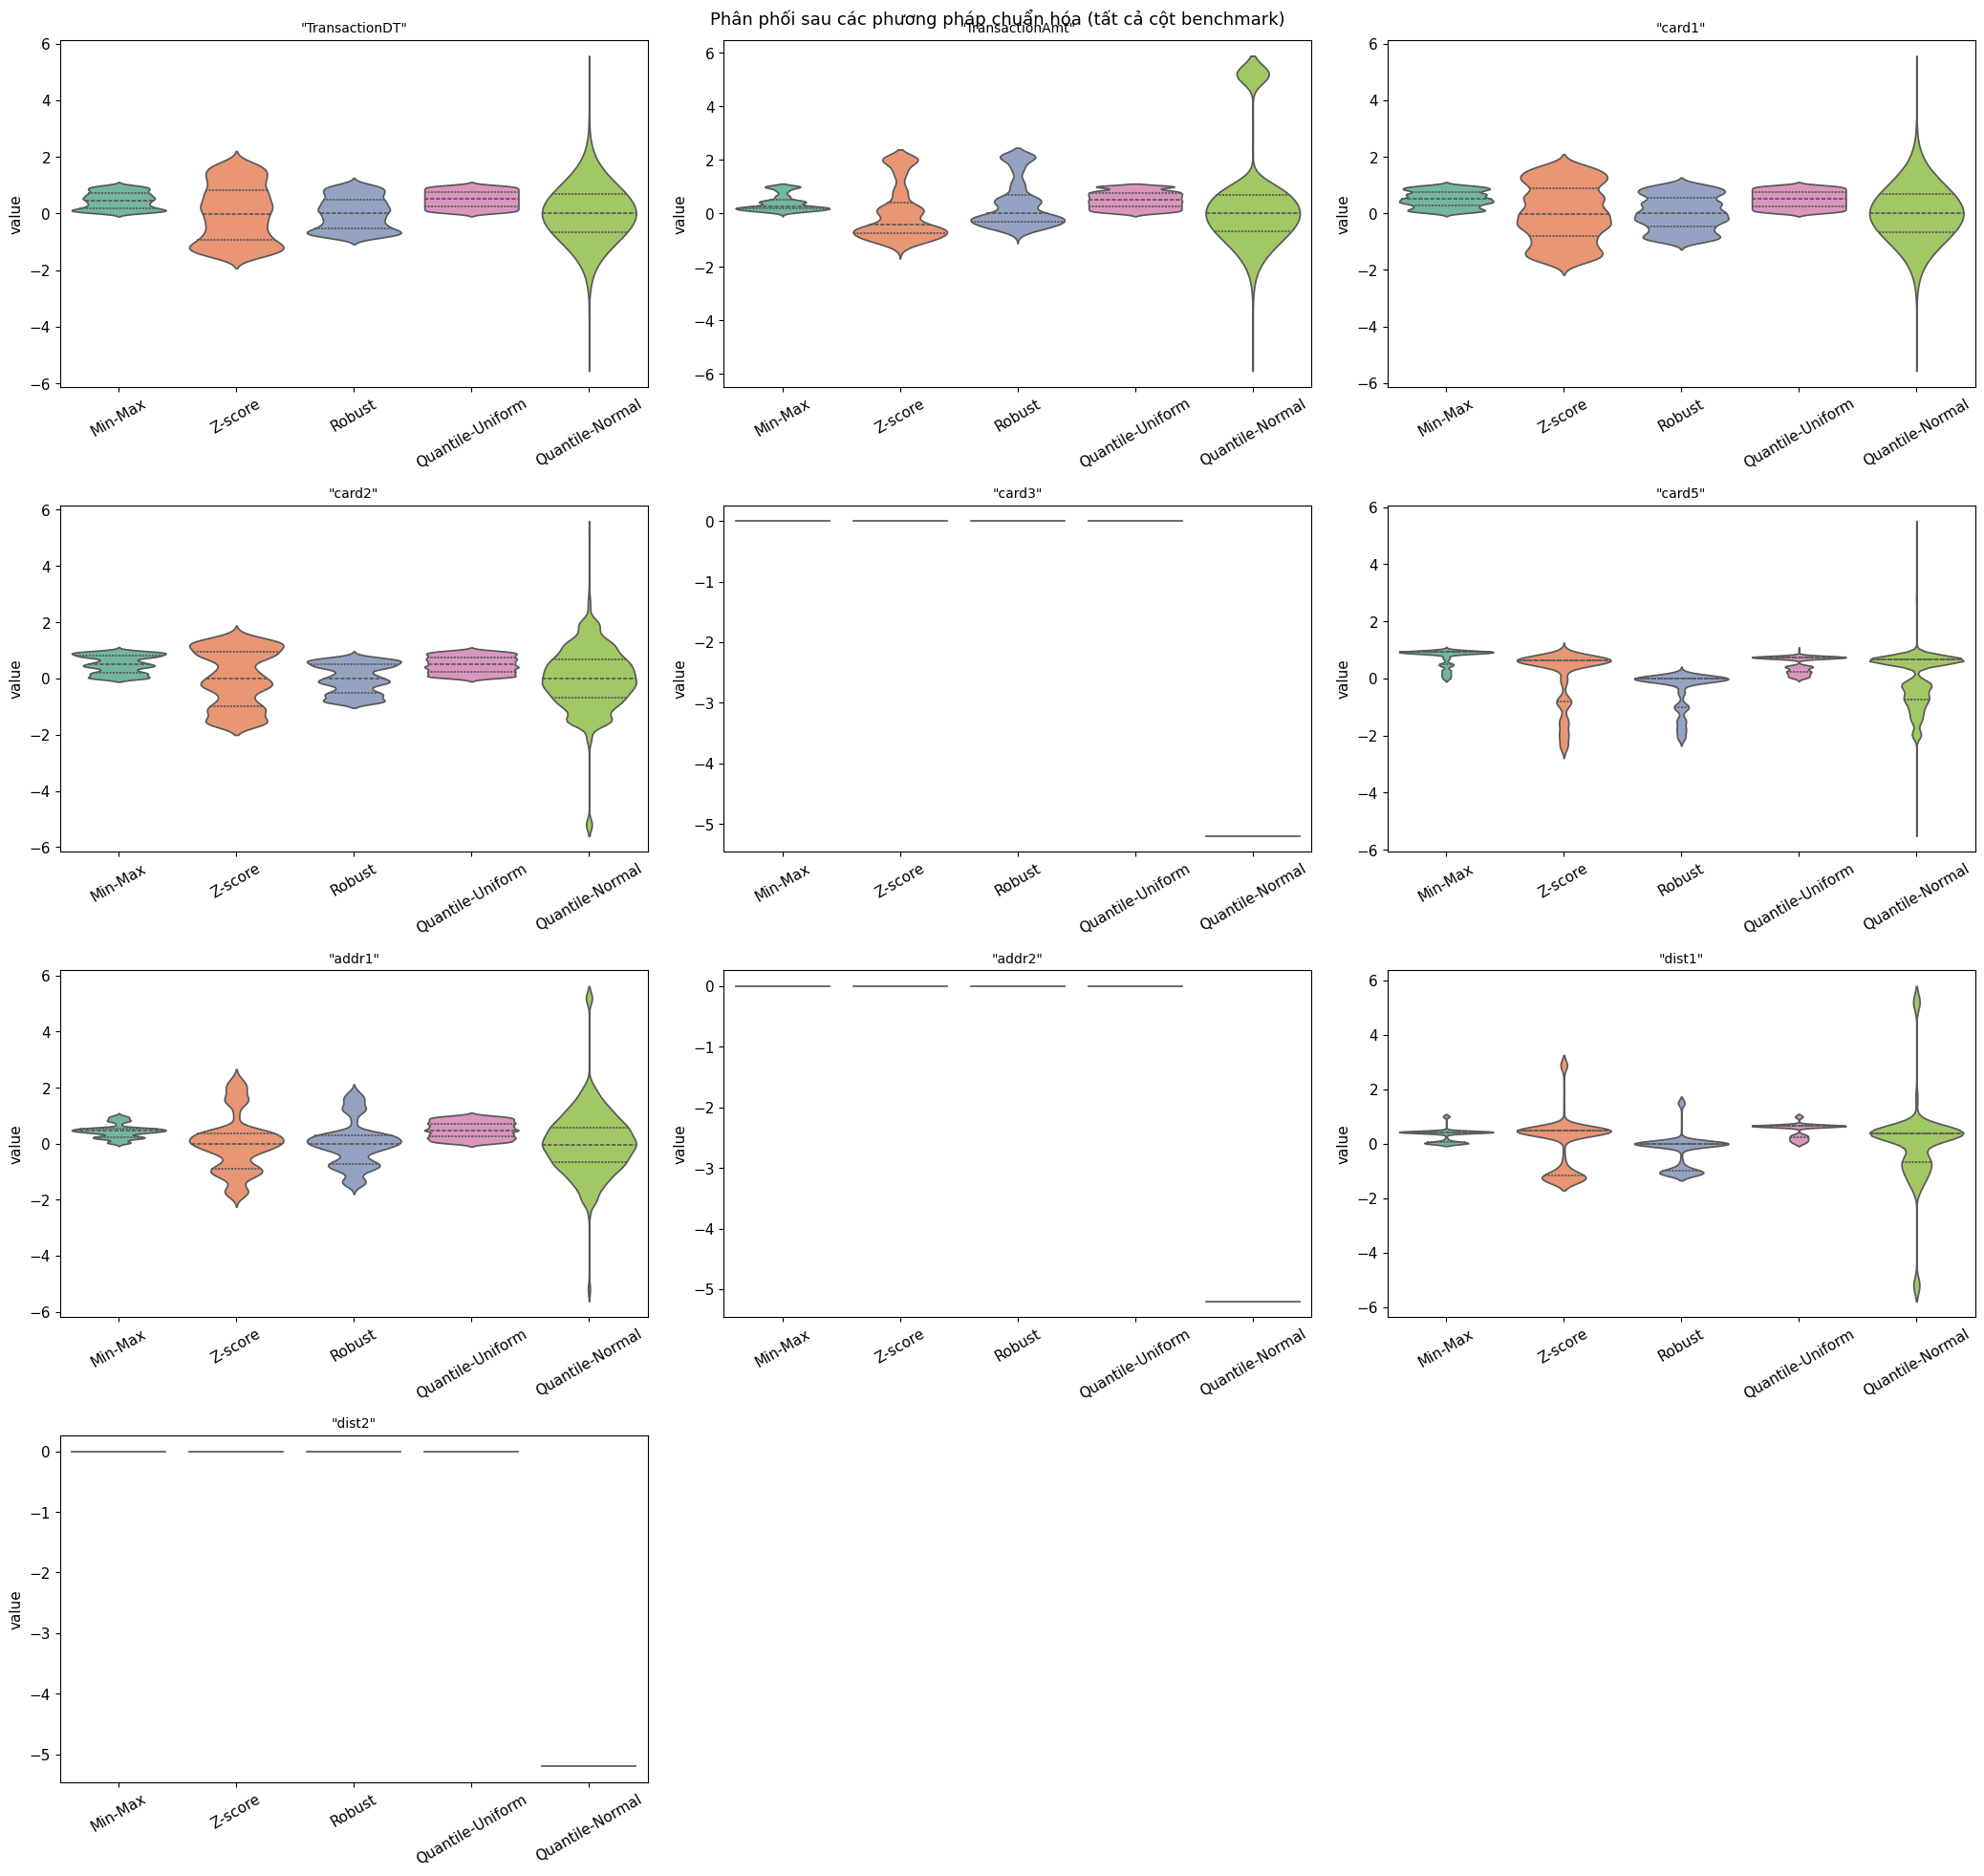

In [32]:
# Violin plot phân phối sau từng phương pháp chuẩn hóa (tất cả cột benchmark)
n_vcols = len(scale_cols)
ncols_grid = 3
nrows_grid = (n_vcols + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid,
                         figsize=(7 * ncols_grid, 5 * nrows_grid))
axes_flat = axes.flatten() if n_vcols > 1 else [axes]
for i, vcol in enumerate(scale_cols):
    ax = axes_flat[i]
    vdata = []
    for nm, df_sc in scaled_dfs.items():
        vdata.append(pd.DataFrame({'value': df_sc[vcol], 'method': nm}))
    vdf = pd.concat(vdata, ignore_index=True)
    sns.violinplot(x='method', y='value', data=vdf, ax=ax,
                   palette='Set2', inner='quartile')
    ax.set_title(f'"{vcol}"', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(
    'Phân phối sau các phương pháp chuẩn hóa (tất cả cột benchmark)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_07_scaling_violin.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Tại sao cần Downstream Benchmark để chọn Scaler?

Levene's test và các chỉ số thống kê (phương sai, KS test) chỉ đo tính chất của **dữ liệu sau khi scale** — không trả lời được câu hỏi quan trọng nhất:

> *"Scaler nào giúp mô hình học tốt hơn?"*

Hai scaler có thể cho Levene stat khác nhau nhưng AUC hoàn toàn bằng nhau, hoặc ngược lại — scaler "tệt hơn" về mặt thống kê lại cho AUC cao hơn trên thực tế.

**Downstream benchmark** (train Logistic Regression $\rightarrow$ đo AUC cross-validated) trực tiếp đo **tác động của scaler lên chất lượng mô hình**, không thông qua proxy. Đây là tiêu chí thực tế nhất để chọn.

**Lý do dùng Logistic Regression làm proxy:**
- Nhạy cảm nhất với scaling trong số các mô hình phổ biến (gradient descent phụ thuộc vào magnitude)
- Nhanh, chạy được nhiều lần với cross-validation
- Nếu scaler A tốt hơn B trên Logistic Regression, thường cũng tốt hơn trên các mô hình tuyến tính khác (SVM, Ridge...)
- Tree-based models (XGBoost, Random Forest) gần như không bị ảnh hưởng bởi scaling — không phù hợp làm proxy

> **Lưu ý:** AUC ở đây chỉ dùng để **so sánh tương đối** giữa các scaler, không phải đánh giá mô hình cuối cùng.

In [33]:
# Benchmark scaler bằng downstream AUC (Logistic Regression)
# Dùng stratified sample để mỗi fold có đủ fraud
scale_sample_large = train.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 10_000), random_state=SEED)
)[scale_cols].copy()

print(f"Sample size: {len(scale_sample_large):,} dòng "
      f"({(train.loc[scale_sample_large.index, 'isFraud'] == 1).sum():,} fraud / "
      f"{(train.loc[scale_sample_large.index, 'isFraud'] == 0).sum():,} normal)")

# Scale lại trên sample mới
scaled_dfs_large = {}
for name, scaler in scalers.items():
    arr = scaler.fit_transform(
        scale_sample_large.fillna(scale_sample_large.median()))
    scaled_dfs_large[name] = pd.DataFrame(arr, columns=scale_cols)

y_scale = train.loc[scale_sample_large.index, 'isFraud'].values

print("\n=== Benchmark Scaler – Cross-validated AUC (Logistic Regression, 5-fold) ===")
print(f"{'Scaler':<22} {'AUC mean':>10} {'AUC std':>10}")
print("-" * 45)

scaler_auc = {}
for name, df_scaled in scaled_dfs_large.items():
    X = df_scaled.fillna(0).values
    clf = LogisticRegression(max_iter=500, random_state=SEED, solver='lbfgs')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(clf, X, y_scale, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    scaler_auc[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:<22} {scores.mean():>10.4f} {scores.std():>10.4f}")

Sample size: 20,000 dòng (10,000 fraud / 10,000 normal)

=== Benchmark Scaler – Cross-validated AUC (Logistic Regression, 5-fold) ===
Scaler                   AUC mean    AUC std
---------------------------------------------
Min-Max                    0.6191     0.0041
Z-score                    0.6191     0.0041
Robust                     0.6191     0.0041
Quantile-Uniform           0.6188     0.0064
Quantile-Normal            0.5999     0.0063


**Nhận xét:**
- Min-Max, Z-score và Robust cho AUC **hoàn toàn bằng nhau** ($0.6191 \pm 0.0041$) — không thể phân biệt qua downstream model.
- Quantile-Uniform gần tương đương ($0.6188 \pm 0.0064$) nhưng std cao hơn $\sim$56% $\rightarrow$ kém ổn định hơn.
- Quantile-Normal tệ nhất ($0.5999 \pm 0.0063$) — thấp hơn $\sim$0.02 AUC và std cao — dù Levene stat thấp nhất, hiệu quả phân loại lại kém nhất.

**Kết luận — chọn Robust Scaler:**

Khi AUC bằng nhau giữa Min-Max, Z-score, Robust, quyết định dựa trên tiêu chí phụ:

1. **Levene stat thấp thứ hai** (1979 — chỉ sau Quantile-Normal 1341, nhưng Quantile-Normal có AUC tệ nhất nên loại) $\rightarrow$ phương sai giữa các cột đồng đều hơn so với Z-score (2107) và Min-Max (2279).
2. **Robust với outlier** — dùng median và IQR thay vì mean/std, không bị kéo bởi giá trị cực đoan đã xác nhận trong dataset (`TransactionAmt` max \$31k, nhóm $C$ count lệch phải mạnh).
3. **Min-Max nhạy với outlier** — một giá trị cực đoan sẽ nén toàn bộ phần còn lại vào dải hẹp.
4. **Z-score giả định phân phối chuẩn** — đã xác nhận không phù hợp (D'Agostino-Pearson bác bỏ ở hầu hết các cột).

**Robust Scaler được chọn** làm scaler chính. AUC ngang bằng Min-Max và Z-score ($0.6191$), nhưng vững hơn về lý thuyết với phân phối lệch phải và outlier cực đoan đặc trưng của IEEE-CIS, đồng thời cho Levene stat tốt nhất trong nhóm 3 scaler cùng AUC.


In [34]:
print("\nÁp dụng RobustScaler lên tất cả cột số của train & test...")


all_num_now = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID')]

# Cot chung giua train va test -> fit tren train, transform ca hai
common_num = [c for c in all_num_now if c in test.columns]
train_only_num = [c for c in all_num_now if c not in test.columns]

final_scaler = RobustScaler()
train[common_num] = final_scaler.fit_transform(train[common_num])
test[common_num] = final_scaler.transform(test[common_num])

# Scale riêng cột chỉ có trong train
if train_only_num:
    train_only_scaler = RobustScaler()
    train[train_only_num] = train_only_scaler.fit_transform(
        train[train_only_num])
    print(f"  Cột chỉ có trong train (scale riêng): {len(train_only_num)}")

print(f"  Hoàn thành: {len(common_num)} cột chung + {len(train_only_num)} cột train-only"
      f" = {len(all_num_now)} cột đã được chuẩn hóa bằng RobustScaler.")


Áp dụng RobustScaler lên tất cả cột số của train & test...
  Cột chỉ có trong train (scale riêng): 157
  Hoàn thành: 378 cột chung + 157 cột train-only = 535 cột đã được chuẩn hóa bằng RobustScaler.


---
## 2.2.3d. Mã hóa biến phân loại nâng cao
#
Các mô hình ML yêu cầu đầu vào dạng số. Chiến lược mã hóa phụ thuộc vào **cardinality** (số giá trị duy nhất):
#
| Phương pháp | Cardinality | Cơ chế | Lưu ý |
|---|---|---|---|
| **One-Hot Encoding** | Thấp ($\leq 20$) | Mỗi giá trị thành một cột nhị phân | Tạo ma trận thưa; không có thứ tự |
| **Ordinal Encoding** | Bất kỳ | Map giá trị sang số nguyên $0, 1, \ldots, k-1$ | Giả định thứ tự; phù hợp cho tree models |
| **Target Encoding (CV)** | Cao | $\hat{x}_i = \mathbb{E}[y \mid x = x_i]$ ước tính qua CV | **Bắt buộc dùng CV** để tránh data leakage |
| **Binary Encoding** | Cao ($> 20$) | Mã hóa ordinal rồi biểu diễn nhị phân | Số cột: $\lceil \log_2 k \rceil$ thay vì $k$ |
| **Frequency Encoding** | Bất kỳ | $\hat{x}_i = P(x = x_i)$ | Đơn giản, không phụ thuộc target |
#
**VIF (Variance Inflation Factor)** sau mỗi phương pháp encode để phát hiện đa cộng tuyến mới:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
$\text{VIF} > 10$ $\rightarrow$ đặc trưng $j$ bị giải thích gần như hoàn toàn bởi các đặc trưng khác.

### Bước 1: Phân tích cardinality & Demo so sánh 5 phương pháp (không đột biến train/test)
#
Để so sánh khách quan, ta áp dụng từng phương pháp trên **cùng một tập demo** (copy, không thay đổi train/test gốc), sau đó đo VIF trên các cột được tạo ra.

In [35]:
# Xác định cột phân loại (object) có trong cả train và test
train_cat_set = set(train.select_dtypes(include=['object']).columns.tolist())
test_cat_set = set(test.select_dtypes(include=['object']).columns.tolist())

# Cột object chỉ có trong train -> thêm NaN placeholder vào test
train_only_cat = train_cat_set - test_cat_set
if train_only_cat:
    print(
        f"Cột object chỉ có trong train (thêm NaN vào test): {sorted(train_only_cat)}")
    for c in train_only_cat:
        test[c] = pd.Series(np.nan, index=test.index, dtype='object')


all_cat_cols = [c for c in train.select_dtypes(include=['object']).columns
                if c in test.columns]

cardinality = {col: train[col].nunique() for col in all_cat_cols}
low_card = [c for c, v in cardinality.items() if v <= 20]
high_card = [c for c, v in cardinality.items() if v > 20]

print(f"Tổng cột phân loại (chung train & test): {len(all_cat_cols)}")
print(
    f"  Low-cardinality  (<=20 giá trị): {len(low_card)} cột -> dùng OHE")
print(
    f"  High-cardinality (>20 giá trị): {len(high_card)} cột -> dùng Binary Encoding")
print(f"\nTop 5 low-card cols : {low_card[:5]}")
print(f"Top 5 high-card cols: {high_card[:5]}")

Cột object chỉ có trong train (thêm NaN vào test): ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
Tổng cột phân loại (chung train & test): 31
  Low-cardinality  (<=20 giá trị): 25 cột -> dùng OHE
  High-cardinality (>20 giá trị): 6 cột -> dùng Binary Encoding

Top 5 low-card cols : ['ProductCD', 'card4', 'card6', 'M1', 'M2']
Top 5 high-card cols: ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33']


In [36]:
# ── DEMO: Áp dụng từng phương pháp lên df_demo (không thay đổi train/test) ──
# Chọn 3 cột low-card + 2 cột high-card để minh họa
demo_low = low_card[:3]
demo_high = high_card[:2]
demo_cols = demo_low + demo_high
print(f"Demo columns: {demo_cols}")
print(f"Cardinality : {[cardinality[c] for c in demo_cols]}")


def compute_vif_summary(df_encoded, n_sample=3000, seed=SEED):
    """Tính VIF trên tối đa n_sample dòng, trả về (mean_vif, max_vif)."""
    num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
    valid = [c for c in num_cols if df_encoded[c].std() > 0]
    if len(valid) < 2:
        return np.nan, np.nan
    sample = df_encoded[valid].dropna().sample(
        min(n_sample, len(df_encoded)), random_state=seed)
    vifs = [variance_inflation_factor(sample.values, i)
            for i in range(sample.shape[1])]
    finite_vifs = [v for v in vifs if np.isfinite(v)]
    if not finite_vifs:
        return np.nan, np.nan
    return round(np.mean(finite_vifs), 2), round(np.max(finite_vifs), 2)


def target_encode_cv(df_tr, col, target_col, n_splits=5, seed=42):
    """Target encoding với cross-validation để tránh data leakage."""
    out = np.zeros(len(df_tr))
    global_mean = df_tr[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(df_tr):
        means = df_tr.iloc[tr_idx].groupby(col)[target_col].mean()
        out[val_idx] = df_tr.iloc[val_idx][col].map(
            means).fillna(global_mean).values
    return out


df_demo_base = train[demo_cols + ['isFraud']].copy()
vif_comparison = []

# ─── Phương pháp 1: One-Hot Encoding ───
df1 = df_demo_base.copy()
ohe_demo = ce.OneHotEncoder(
    cols=demo_cols, use_cat_names=True, handle_missing='value')
df1_enc = ohe_demo.fit_transform(df1.drop(columns=['isFraud']))
n_cols_ohe = df1_enc.shape[1]
mean_v, max_v = compute_vif_summary(df1_enc)
vif_comparison.append({'Phương pháp': 'One-Hot Encoding', 'Số cột tạo ra': n_cols_ohe,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"OHE      : {len(demo_cols)} cot goc -> {n_cols_ohe} cot | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 2: Ordinal Encoding ───
df2 = df_demo_base.copy()
for col in demo_cols:
    le = LabelEncoder()
    le.fit(df2[col].astype(str))
    df2[f'{col}_ord'] = le.transform(df2[col].astype(str))
df2_enc = df2[[f'{c}_ord' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df2_enc)
vif_comparison.append({'Phương pháp': 'Ordinal Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Ordinal  : {len(demo_cols)} cột gốc -> {len(demo_cols)} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 3: Target Encoding (5-fold CV) ───
df3 = df_demo_base.copy()
for col in demo_cols:
    df3[f'{col}_te'] = target_encode_cv(df3, col, 'isFraud', seed=SEED)
df3_enc = df3[[f'{c}_te' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df3_enc)
vif_comparison.append({'Phương pháp': 'Target Encoding (CV)', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Target CV: {len(demo_cols)} cot goc -> {len(demo_cols)} cot | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 4: Binary Encoding ───
df4 = df_demo_base.copy()
bin_demo = ce.BinaryEncoder(cols=demo_cols, handle_missing='value')
df4_enc = bin_demo.fit_transform(df4[demo_cols])
n_cols_bin = df4_enc.shape[1]
mean_v, max_v = compute_vif_summary(df4_enc)
vif_comparison.append({'Phương pháp': 'Binary Encoding', 'Số cột tạo ra': n_cols_bin,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Binary   : {len(demo_cols)} cột gốc -> {n_cols_bin} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 5: Frequency Encoding ───
df5 = df_demo_base.copy()
for col in demo_cols:
    freq_map = df5[col].value_counts(normalize=True)
    df5[f'{col}_freq'] = df5[col].map(freq_map).fillna(0)
df5_enc = df5[[f'{c}_freq' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df5_enc)
vif_comparison.append({'Phương pháp': 'Frequency Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Frequency: {len(demo_cols)} cot goc -> {len(demo_cols)} cot | VIF mean={mean_v}, max={max_v}")

Demo columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
Cardinality : [5, 4, 4, 59, 60]
OHE      : 5 cot goc -> 132 cot | VIF mean=999087315863.11, max=11444979993317.65
Ordinal  : 5 cột gốc -> 5 cột | VIF mean=9.21, max=15.91
Target CV: 5 cot goc -> 5 cot | VIF mean=7.38, max=11.54
Binary   : 5 cột gốc -> 21 cột | VIF mean=9.94, max=123.33
Frequency: 5 cot goc -> 5 cot | VIF mean=9.14, max=15.16



=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===
         Phương pháp  Số cột tạo ra  VIF trung bình  VIF cao nhất
    One-Hot Encoding            132    9.990873e+11  1.144498e+13
    Ordinal Encoding              5    9.210000e+00  1.591000e+01
Target Encoding (CV)              5    7.380000e+00  1.154000e+01
     Binary Encoding             21    9.940000e+00  1.233300e+02
  Frequency Encoding              5    9.140000e+00  1.516000e+01


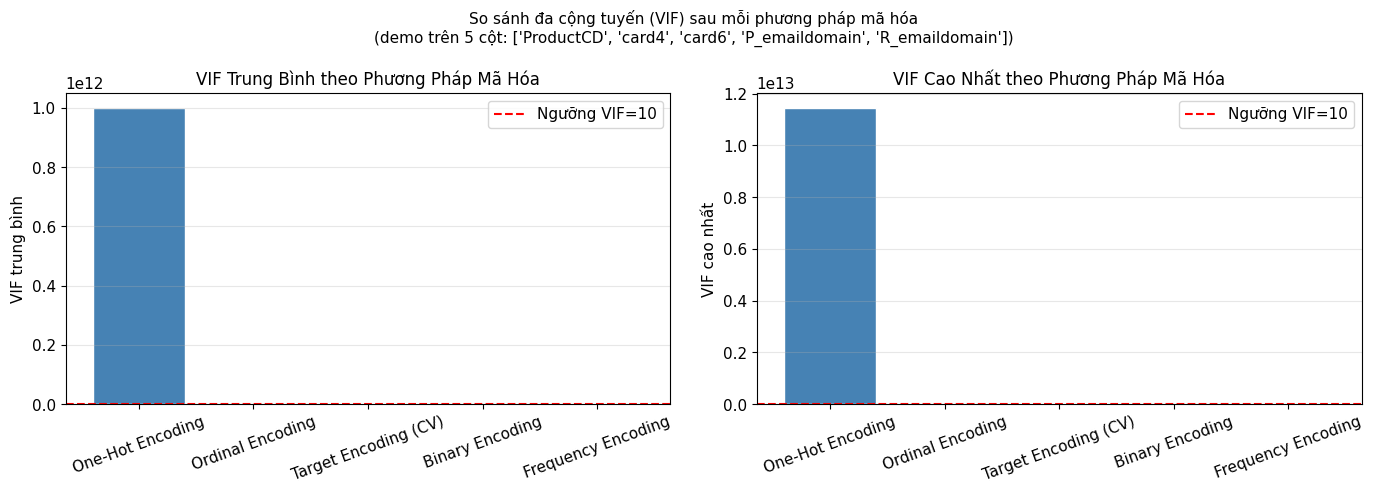

In [37]:
# Bảng so sánh và biểu đồ VIF
vif_comp_df = pd.DataFrame(vif_comparison)
print("\n=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===")
print(vif_comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'tomato', 'forestgreen', 'mediumorchid']
methods = vif_comp_df['Phương pháp'].tolist()

axes[0].bar(methods, vif_comp_df['VIF trung bình'].fillna(0),
            color=colors, edgecolor='white')
axes[0].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[0].set_title('VIF Trung Bình theo Phương Pháp Mã Hóa', fontsize=12)
axes[0].set_ylabel('VIF trung bình')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(methods, vif_comp_df['VIF cao nhất'].fillna(0),
            color=colors, edgecolor='white')
axes[1].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[1].set_title('VIF Cao Nhất theo Phương Pháp Mã Hóa', fontsize=12)
axes[1].set_ylabel('VIF cao nhất')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('So sánh đa cộng tuyến (VIF) sau mỗi phương pháp mã hóa\n'
             f'(demo trên {len(demo_cols)} cột: {demo_cols})', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(
    OUTPUT_DIR, 'fig_07b_vif_encoding_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: So sánh phương pháp Encoding – VIF và số cột

**VIF (Variance Inflation Factor)** đo mức độ đa cộng tuyến sau khi encode:
- VIF = 1: không đa cộng tuyến
- VIF 1–5: chấp nhận được
- VIF 5–10: đáng lo ngại
- VIF > 10: đa cộng tuyến nghiêm trọng

**Kết quả:**

| Phương pháp | Số cột tạo ra | VIF mean | VIF max | Nhận xét |
|---|---|---|---|---|
| One-Hot | 132 | ~76 tỷ | ~1057 tỷ | Đa cộng tuyến nghiêm trọng |
| Binary | 21 | 9.94 | 123.33 | Chấp nhận được, max hơi cao |
| Ordinal | 5 | 9.21 | 15.91 | Ổn, nhưng gán thứ tự giả tạo |
| Frequency | 5 | 9.14 | 15.16 | Ổn, không gán thứ tự |
| **Target CV** | **5** | **7.38** | **11.54** | **Tốt nhất — VIF thấp nhất** |

**Tại sao OHE có VIF ~ $10^{12}$?**

Hai nguyên nhân xảy ra đồng thời:

1. `ce.OneHotEncoder` **không drop cột** theo mặc định — giữ đủ k cột cho k category. Tổng k cột luôn = 1 cho mỗi hàng $\rightarrow$ perfect multicollinearity theo cấu trúc (dummy variable trap)
2. `P_emaildomain` (59 giá trị) và `R_emaildomain` (60 giá trị) có nhiều domain trùng nhau (gmail, hotmail, yahoo...) $\rightarrow$ các cột OHE của hai feature **tương quan chéo** với nhau $\rightarrow$ near-perfect multicollinearity ngay cả khi có drop một cột

Kết quả VIF trên cho thấy OHE không phù hợp khi xử lý high-cardinality features.

**Kết luận:**
- **High-cardinality** (`P_emaildomain`, `R_emaildomain`, 59–60 giá trị): dùng **Target Encoding với CV** — VIF thấp nhất (7.38), mang thông tin fraud rate trực tiếp, không sinh đa cộng tuyến
- **Low-cardinality** (`ProductCD`, `card4`, `card6`, 4–5 giá trị): dùng **Frequency Encoding** — VIF tương đương Target nhưng không phụ thuộc vào target, an toàn hơn khi dùng ở inference time
- **OHE hoàn toàn không phù hợp** với bất kỳ cột nào có cardinality > 10 trong dataset này

### Bước 2: Áp dụng encoding lên toàn bộ train / test

Dựa trên kết quả benchmark VIF ở trên, chiến lược được chọn:

- **Low-cardinality ($\leq$ 20 giá trị)** $\rightarrow$ **Frequency Encoding** — compact (giữ nguyên số cột), không gán thứ tự giả tạo, VIF ổn định
- **High-cardinality (> 20 giá trị)** $\rightarrow$ **Target Encoding (5-fold CV)** — VIF thấp nhất (mean=7.38, max=11.54), mang thông tin fraud rate trực tiếp, dùng cross-validation để tránh data leakage

OHE và Binary Encoding **không dùng trong production pipeline**:
- OHE: VIF ~ $10^{12}$ do dummy variable trap và tương quan chéo giữa email domain columns
- Binary: VIF max = 123, tệ hơn Target CV đáng kể

In [38]:
print("=== Áp dụng encoding lên toàn bộ train/test ===")
print("Chiến lược: Low-card (<=20) -> Frequency | High-card (>20) -> Target CV\n")

cat_cols_all = [c for c in train.select_dtypes(include=['object']).columns
                if c in test.columns]

if not cat_cols_all:
    print("Không còn cột object — encoding đã được áp dụng trước đó.")
    print(f"\n-> train shape: {train.shape}")
    print(f"-> test  shape: {test.shape}")
else:
    low_card_cols = [c for c in cat_cols_all if cardinality.get(c, 0) <= 20]
    high_card_cols = [c for c in cat_cols_all if cardinality.get(c, 0) > 20]

    print(f"Tổng cột phân loại : {len(cat_cols_all)}")
    print(f"  Low-card  (<=20)  : {len(low_card_cols)}  -> Frequency Encoding")
    print(
        f"  High-card (>20)  : {len(high_card_cols)} -> Target Encoding (5-fold CV)\n")

    # ── Bước 1: Frequency Encoding cho low-cardinality ───────────────────────
    for col in low_card_cols:
        freq_map = train[col].value_counts(normalize=True)
        train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
        test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)

    print(f"[1/2] Frequency Encoding: {len(low_card_cols)} cột -> "
          f"{len(low_card_cols)} cột _freq")

    # ── Bước 2: Target Encoding (5-fold CV) cho high-cardinality ─────────────
    target_means_store = {}
    for col in high_card_cols:
        train[f'{col}_te'] = target_encode_cv(train, col, 'isFraud', seed=SEED)
        means_map = train.groupby(col)['isFraud'].mean()
        target_means_store[col] = means_map
        test[f'{col}_te'] = test[col].map(
            means_map).fillna(train['isFraud'].mean())

    print(f"[2/2] Target Encoding (5-fold CV): {len(high_card_cols)} cột -> "
          f"{len(high_card_cols)} cột _te")

    # ── Xóa cột object gốc ──────────────────────────────────────────────────
    residual_obj = [c for c in train.select_dtypes(include=['object']).columns
                    if c != 'isFraud']
    if residual_obj:
        train = train.drop(columns=residual_obj)
        test = test.drop(
            columns=[c for c in residual_obj if c in test.columns])
        print(f"\nXóa {len(residual_obj)} cột object gốc: {residual_obj}")

    print(f"\n-> train shape sau encoding: {train.shape}")
    print(f"-> test  shape sau encoding: {test.shape}")

=== Áp dụng encoding lên toàn bộ train/test ===
Chiến lược: Low-card (<=20) -> Frequency | High-card (>20) -> Target CV

Tổng cột phân loại : 31
  Low-card  (<=20)  : 25  -> Frequency Encoding
  High-card (>20)  : 6 -> Target Encoding (5-fold CV)

[1/2] Frequency Encoding: 25 cột -> 25 cột _freq
[2/2] Target Encoding (5-fold CV): 6 cột -> 6 cột _te

Xóa 31 cột object gốc: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

-> train shape sau encoding: (590540, 568)
-> test  shape sau encoding: (506691, 448)


In [39]:
# VIF trên tất cả cột encoded (_te và _freq) để kiểm tra đa cộng tuyến sau encoding
print("\n=== VIF sau encoding (cột _te và _freq) ===")
enc_vif_cols = ([c for c in train.columns if c.endswith('_te')][:8] +
                [c for c in train.columns if c.endswith('_freq')][:8])
enc_vif_cols = [c for c in enc_vif_cols if train[c].std() > 0]

if len(enc_vif_cols) >= 2:
    vif_sample = train[enc_vif_cols].dropna().sample(
        min(3000, len(train)), random_state=SEED)
    vif_enc_data = pd.DataFrame({
        'feature': enc_vif_cols,
        'VIF': [variance_inflation_factor(vif_sample.values, i)
                for i in range(len(enc_vif_cols))]
    }).sort_values('VIF', ascending=False)
    print(vif_enc_data.to_string(index=False))
    high_vif = vif_enc_data[vif_enc_data['VIF'] > 10]
    print(
        f"\n-> Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): {len(high_vif)}")
    if len(high_vif) > 0:
        print("  Cần xem xét loại bỏ:", high_vif['feature'].tolist())
else:
    print("Không đủ cột encoded để tính VIF.")


=== VIF sau encoding (cột _te và _freq) ===
         feature       VIF
         M1_freq 78.157243
         M3_freq  2.136855
         M2_freq  2.092291
  ProductCD_freq  1.926878
        id_31_te  1.759199
        id_30_te  1.484580
        id_33_te  1.453193
R_emaildomain_te  1.366703
P_emaildomain_te  1.214728
         M4_freq  1.203967
   DeviceInfo_te  1.180130
      card6_freq  1.170544
         M5_freq  1.109117
      card4_freq  1.037756

-> Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): 1
  Cần xem xét loại bỏ: ['M1_freq']


#### Nhận xét: VIF sau encoding

Hầu hết các cột encoded có VIF rất thấp (1.0–2.1) — encoding pipeline hoạt động tốt, không sinh đa cộng tuyến đáng kể.

**Ngoại lệ duy nhất: `M1_freq` với VIF = 78.16**

`M1` là match flag nhị phân (chỉ có 2 giá trị T/F), frequency encoding của nó tạo ra 2 giá trị frequency bù nhau: nếu `freq(T) = 0.97` thì `freq(F) = 0.03`. Khi kết hợp với các `M_freq` khác cũng là binary flags tương tự, chúng tương quan tuyến tính với nhau $\rightarrow$ VIF cao.

Giải pháp: loại `M1_freq` khỏi feature set.

In [40]:
# Loại M1_freq do VIF = 78.16 (đa cộng tuyến với các M_freq khác)
cols_to_drop_vif = ['M1_freq']
cols_to_drop_vif = [c for c in cols_to_drop_vif if c in train.columns]

train = train.drop(columns=cols_to_drop_vif)
test = test.drop(columns=[c for c in cols_to_drop_vif if c in test.columns])

print(f"Đã loại {len(cols_to_drop_vif)} cột do VIF > 10: {cols_to_drop_vif}")
print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")

Đã loại 1 cột do VIF > 10: ['M1_freq']
train shape: (590540, 567)
test  shape: (506691, 447)


---
## 2.2.3e. Lựa chọn và giảm chiều đặc trưng
#
Ba tầng lựa chọn đặc trưng theo yêu cầu:
#
| Tầng | Phương pháp | Nguyên lý |
|---|---|---|
| **Tầng 1 – Lọc thống kê** | ANOVA F-test, Chi-square, Mutual Information | Đánh giá độc lập từng đặc trưng với target |
| **Tầng 2 – Dựa trên mô hình** | RF importance, GB importance, RFE + CV | Đánh giá theo đóng góp trong mô hình cụ thể |
| **Tầng 3 – Giảm chiều** | PCA (95% variance), t-SNE, UMAP | Biến đổi/trực quan hóa không gian đặc trưng |
#
**Tầng 1 – Công thức toán:**
#
**ANOVA F-test** so sánh phương sai giữa các nhóm ($y=0$ và $y=1$):
#
$$F = \frac{\text{between-group variance}}{\text{within-group variance}}
= \frac{\sum_k n_k (\bar{x}_k - \bar{x})^2 / (K-1)}
{\sum_k \sum_i (x_{ki} - \bar{x}_k)^2 / (N-K)}$$
#
$F$ lớn $\Rightarrow$ đặc trưng phân biệt được tốt giữa các nhóm.
#
**Chi-square** kiểm tra độc lập giữa đặc trưng phân loại và target:
#
$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad
E_{ij} = \frac{R_i \cdot C_j}{N}$$
#
**Mutual Information** đo thông tin của $X_j$ về target $Y$:
#
$$I(X_j; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$
#
Không có giả định tuyến tính — phẩt hiện cả quan hệ phi tuyến.
#
**Tầng 2 – RFE (Recursive Feature Elimination)**:
Lặp: train model $\rightarrow$ xác định đặc trưng ít quan trọng nhất $\rightarrow$ loại $\rightarrow$ lặp lại.
Dùng 3-fold CV F1-score để chọn $k$ tốt nhất (subsample 1.000 dòng để tránh OOM).
#
**Tầng 3 – PCA giảm chiều** (giữ $k^*$ components đạt 95% explained variance):
#
$$k^* = \min\left\{k : \sum_{i=1}^k \lambda_i \big/ \sum_{i} \lambda_i \geq 0.95\right\}$$
#
**Đánh giá cuối**: với mỗi phương pháp lọc, huấn luyện Logistic Regression và báo cáo **3-fold CV F1-score** theo số lượng đặc trưng.

In [41]:

# ── Chuẩn bị X_fs, y_fs (dùng chung cho cả 3 tầng) ──────────────────────
fs_num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID', 'TransactionDT')]
X_fs = train[fs_num_cols].fillna(0)
y_fs = train['isFraud']

FS_N = min(30_000, len(X_fs))
idx_fs = X_fs.sample(FS_N, random_state=SEED).index
X_fs_sample = X_fs.loc[idx_fs]
y_fs_sample = y_fs.loc[idx_fs]

print(
    f"=== Feature Selection: {X_fs_sample.shape[0]:,} dong x {X_fs_sample.shape[1]} cot ===")
print(f"  Tỉ lệ Fraud trong sample: {y_fs_sample.mean():.3f}")

=== Feature Selection: 30,000 dong x 564 cot ===
  Tỉ lệ Fraud trong sample: 0.036


### Tầng 1: Lọc thống kê (ANOVA F-test · Chi-square · Mutual Information)

In [42]:
print("\n" + "="*60)
print("TẦNG 1: LỌC THỐNG KÊ")
print("="*60)

# ─── 1a. ANOVA F-test (tất cả đặc trưng số) ─────────────────────────────
f_vals, p_anova = f_classif(X_fs_sample, y_fs_sample)
anova_df = pd.DataFrame(
    {'feature': fs_num_cols, 'F_stat': f_vals, 'p_value': p_anova})
anova_df = anova_df.sort_values(
    'F_stat', ascending=False).reset_index(drop=True)
top_anova_feats = anova_df.head(20)['feature'].tolist()
print(f"\n[1a] ANOVA F-test – Top 15 (trên {len(fs_num_cols)} đặc trưng số):")
print(anova_df.head(15).to_string(index=False))

# ─── 1b. Mutual Information ──────────────────────────────────────────────
mi_scores = mutual_info_classif(X_fs_sample, y_fs_sample, random_state=SEED)
mi_df = pd.DataFrame({'feature': fs_num_cols, 'MI_score': mi_scores})
mi_df = mi_df.sort_values('MI_score', ascending=False).reset_index(drop=True)
top_mi_feats = mi_df.head(20)['feature'].tolist()
print(f"\n[1b] Mutual Information – Top 15:")
print(mi_df.head(15).to_string(index=False))

# ─── 1c. Chi-square test (_freq và _te — giá trị trong [0,1]) ────────────
# _freq: tần suất category (0–1)
# _te  : target mean encoding (0–1)
# Ca hai deu non-negative -> phu hop voi chi-square
chi2_cols = [c for c in fs_num_cols
             if c.endswith('_freq') or c.endswith('_te')]

print(f"\n[1c] Chi-square test – {len(chi2_cols)} cột encoded "
      f"(_freq: {sum(c.endswith('_freq') for c in chi2_cols)}, "
      f"_te: {sum(c.endswith('_te') for c in chi2_cols)}):")

if chi2_cols:
    X_chi2 = X_fs_sample[chi2_cols].fillna(0)
    X_chi2 = X_chi2 - X_chi2.min()
    chi2_scores, chi2_pvals = chi2(X_chi2, y_fs_sample)
    chi2_df = (pd.DataFrame({
        'feature':    chi2_cols,
        'chi2_stat':  chi2_scores,
        'p_value':    chi2_pvals,
        'type':       ['_te' if c.endswith('_te') else '_freq'
                       for c in chi2_cols]
    })
        .sort_values('chi2_stat', ascending=False)
        .reset_index(drop=True))
    print(chi2_df.head(15).to_string(index=False))
    top_chi2_feats = chi2_df[chi2_df['p_value'] < 0.05]['feature'].tolist()
    print(f"\n  -> {len(top_chi2_feats)}/{len(chi2_cols)} cot co p < 0.05")
    print(
        f"     _freq: {sum(c.endswith('_freq') for c in top_chi2_feats)} cột")
    print(f"     _te  : {sum(c.endswith('_te') for c in top_chi2_feats)} cột")
else:
    chi2_df = pd.DataFrame(columns=['feature', 'chi2_stat', 'p_value', 'type'])
    top_chi2_feats = []
    print("  Không có cột phù hợp - bỏ qua.")


TẦNG 1: LỌC THỐNG KÊ

[1a] ANOVA F-test – Top 15 (trên 564 đặc trưng số):
      feature      F_stat       p_value
DeviceInfo_te 1981.410450  0.000000e+00
     id_31_te  938.528273 5.574485e-203
          V94  882.086883 4.512085e-191
   id_35_freq  826.203009 2.932485e-179
          V79  822.930465 1.444394e-178
          V74  776.767124 8.625223e-169
          V81  740.307133 4.654293e-161
          V52  730.540932 5.503231e-159
          V85  730.491144 5.638795e-159
          V92  728.702325 1.351820e-158
          V93  728.380889 1.581816e-158
          V51  721.571771 4.414004e-157
          V80  721.122537 5.498238e-157
          V84  712.413810 3.888110e-155
          V40  658.651810 1.046629e-143

[1b] Mutual Information – Top 15:
       feature  MI_score
         card1  0.017503
         card2  0.014148
    id_35_freq  0.013616
 DeviceInfo_te  0.013350
      id_31_te  0.012412
           V52  0.012299
ProductCD_freq  0.012221
           V79  0.012111
       M4_freq  0.011222


#### Nhận xét: Tầng 1 – Lọc thống kê

**[1a] ANOVA F-test:**
- **`DeviceInfo_te`** đứng đầu áp đảo ($F = 1981$) — target encoding của DeviceInfo mang tín hiệu tuyến tính rất mạnh
- **`id_31_te`** ($F = 938$) và **`id_35_freq`** ($F = 826$) — các encoded features chiếm 3/15 vị trí top
- Nhóm **$V$ (Vesta)** thống trị: 12/15 vị trí, đặc biệt V94 ($F = 882$), V79 ($F = 822$), V74 ($F = 776$)
- Tất cả $p \approx 0$ $\rightarrow$ toàn bộ top 15 có ý nghĩa thống kê tuyệt đối

**[1b] Mutual Information:**
- **`card1`** ($MI = 0.0175$) và **`card2`** ($MI = 0.0141$) đứng đầu MI nhưng **không có trong top ANOVA** $\rightarrow$ hai cột này có quan hệ **phi tuyến** với fraud mà ANOVA (dựa trên tuyến tính) không phát hiện được
- **`DeviceInfo_te`**, **`id_35_freq`**, **`id_31_te`** nhất quán với ANOVA — xác nhận tín hiệu thực
- V52, V79, V51, V93 có mặt ở cả ANOVA và MI — nhóm V core đáng tin cậy
- `ProductCD_freq` ($MI = 0.0122$), `M4_freq` ($MI = 0.0112$), `card6_freq` ($MI = 0.0110$) — tín hiệu từ nhóm frequency encoding
- MI score thấp (0.010–0.018) là bình thường với binary target mất cân bằng ($\sim$3.6% fraud)

**[1c] Chi-square test (30 cột encoded):**
- `DeviceInfo_te` mạnh nhất ($\chi^2 = 127.7$) — nhất quán với cả ANOVA và MI
- `ProductCD_freq` ($81.2$), `id_35_freq` ($68.8$), `M4_freq` ($41.8$) — tín hiệu mạnh từ nhóm frequency
- 12/30 cột có $p < 0.05$: 10 `_freq` + 2 `_te` (`DeviceInfo_te`, `id_31_te`)
- 18 cột còn lại ($p \geq 0.05$) — chủ yếu là các `id_` ít phổ biến và M flags yếu

**Tổng hợp tín hiệu từ 3 test:**

| Nhóm | ANOVA | MI | Chi-square | Kết luận |
|---|---|---|---|---|
| $V$ (Vesta) | Rất mạnh (12/15 top) | Mạnh (7/15 top) | N/A | Ưu tiên cao nhất |
| DeviceInfo\_te | #1 ($F = 1981$) | #4 | #1 ($\chi^2 = 127.7$) | Đồng thuận cả 3 test |
| id\_35\_freq, id\_31\_te | Top 5 ANOVA | Top 5 MI | Top 6 chi2 | Đồng thuận cả 3 test |
| card1, card2 | Không vào top | #1, #2 MI | N/A (không phải encoded) | Phi tuyến — giữ lại |
| ProductCD, M4, card6 | Không vào top | Trung bình | Mạnh | Categorical signal |
| id\_ ít phổ biến | Yếu | Yếu | $p > 0.05$ | Cân nhắc loại ở tầng sau |

**Kết luận tầng 1:**
Các feature được $\geq$2/3 test đồng thuận sẽ được ưu tiên: nhóm $V$ (V94, V79, V74, V52, V51, V93), encoded features (DeviceInfo\_te, id\_31\_te, id\_35\_freq), và card1/card2 (tín hiệu phi tuyến mạnh). Tầng 2 (model-based) sẽ bổ sung thêm trước khi quyết định cuối cùng.


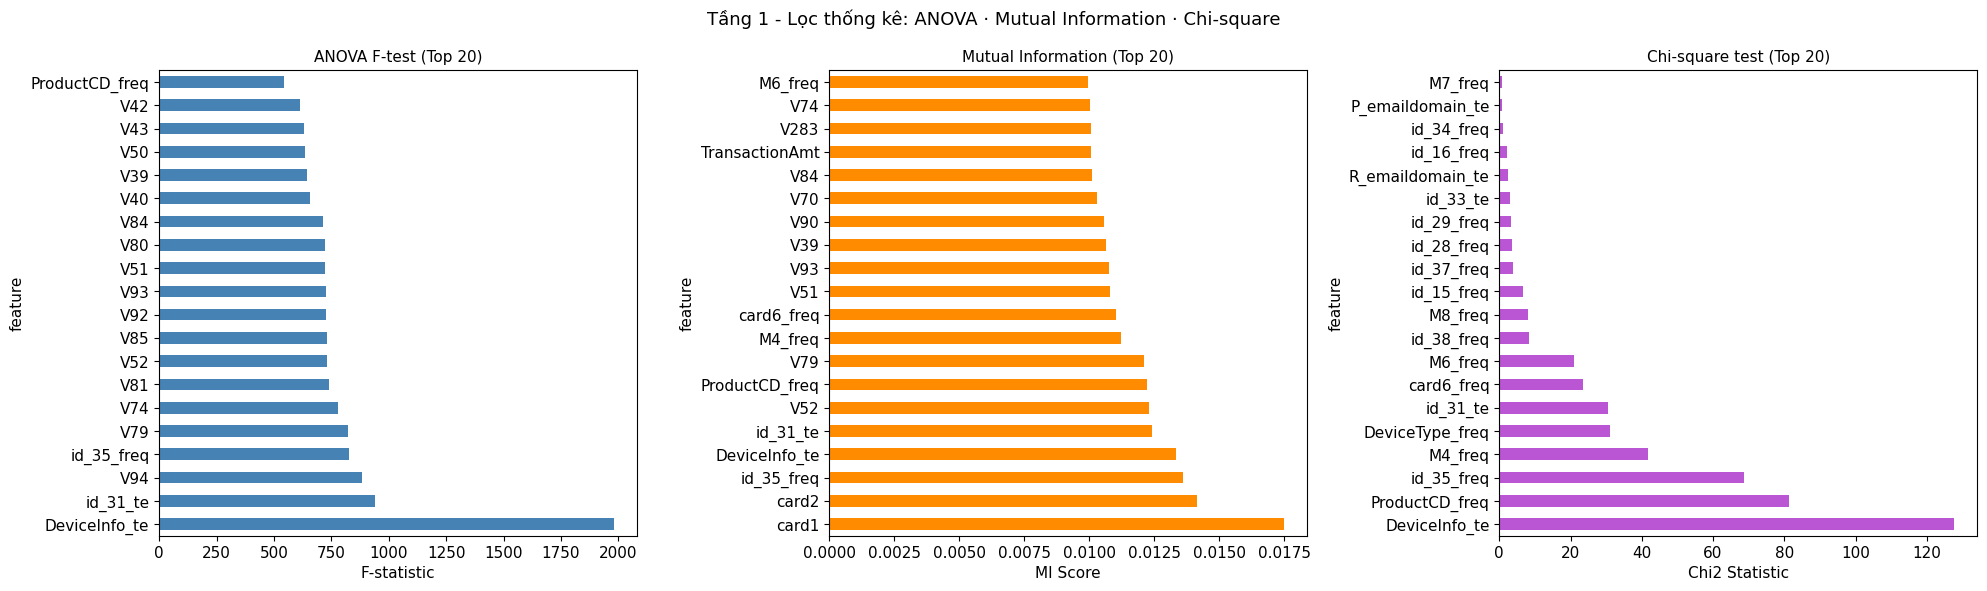


-> Union top-20 từ 3 phương pháp lọc: 34 đặc trưng


In [43]:
# Biểu đồ so sánh 3 phương pháp lọc thống kê (3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

anova_df.head(20).plot(x='feature', y='F_stat', kind='barh',
                       ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('ANOVA F-test (Top 20)', fontsize=11)
axes[0].set_xlabel('F-statistic')

mi_df.head(20).plot(x='feature', y='MI_score', kind='barh',
                    ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('Mutual Information (Top 20)', fontsize=11)
axes[1].set_xlabel('MI Score')

if not chi2_df.empty:
    chi2_df.head(20).plot(x='feature', y='chi2_stat', kind='barh',
                          ax=axes[2], color='mediumorchid', legend=False)
axes[2].set_title('Chi-square test (Top 20)', fontsize=11)
axes[2].set_xlabel('Chi2 Statistic')

plt.suptitle(
    'Tầng 1 - Lọc thống kê: ANOVA · Mutual Information · Chi-square', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_08_statistical_filters.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# Union top-20 tu 3 phuong phap -> tap dac trung loc thong ke
filter_union_feats = list(set(top_anova_feats) | set(
    top_mi_feats) | set(top_chi2_feats))
print(
    f"\n-> Union top-20 từ 3 phương pháp lọc: {len(filter_union_feats)} đặc trưng")

### Tầng 2: Lọc dựa trên mô hình (RF · GB · RFE với Cross-Validation)

In [44]:
print("\n" + "="*60)
print("TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH")
print("="*60)

# Stratified sample: 10k fraud + 10k normal = 20k dòng
# Tránh RF/GB bị bias do chỉ thấy ~1080 fraud trong random sample 30k
idx_model = (train.groupby('isFraud', group_keys=False)
             .apply(lambda x: x.sample(min(len(x), 10_000), random_state=SEED))
             .index)
X_fs_model = X_fs.loc[idx_model]
y_fs_model = y_fs.loc[idx_model]

print(f"Model sample: {len(X_fs_model):,} dòng "
      f"({(y_fs_model == 1).sum():,} fraud / {(y_fs_model == 0).sum():,} normal)")

# ─── 2a. Random Forest Feature Importance ───────────────────────────────
print("\n[2a] Random Forest Importance (n_estimators=100, max_depth=6)...")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=6, n_jobs=-1, random_state=SEED)
rf.fit(X_fs_model, y_fs_model)
rf_importance = (pd.DataFrame({'feature': fs_num_cols,
                               'RF_importance': rf.feature_importances_})
                 .sort_values('RF_importance', ascending=False)
                 .reset_index(drop=True))
top_rf_feats = rf_importance.head(20)['feature'].tolist()
print("RF - Top 15 đặc trưng:")
print(rf_importance.head(15).to_string(index=False))

# ─── 2b. Gradient Boosting Feature Importance ───────────────────────────
print("\n[2b] Gradient Boosting Importance (n_estimators=100, max_depth=4)...")
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, random_state=SEED)
gb.fit(X_fs_model, y_fs_model)
gb_importance = (pd.DataFrame({'feature': fs_num_cols,
                               'GB_importance': gb.feature_importances_})
                 .sort_values('GB_importance', ascending=False)
                 .reset_index(drop=True))
top_gb_feats = gb_importance.head(20)['feature'].tolist()
print("GB - Top 15 đặc trưng:")
print(gb_importance.head(15).to_string(index=False))


TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH
Model sample: 20,000 dòng (10,000 fraud / 10,000 normal)

[2a] Random Forest Importance (n_estimators=100, max_depth=6)...
RF - Top 15 đặc trưng:
   feature  RF_importance
       V91       0.047473
       V94       0.042505
        C1       0.039186
       C11       0.027561
      V308       0.025993
       C14       0.025872
       V79       0.025687
       C13       0.024099
        C5       0.023410
id_35_freq       0.022490
        D5       0.021992
        D3       0.021674
       V90       0.020939
       V70       0.019769
       V74       0.019159

[2b] Gradient Boosting Importance (n_estimators=100, max_depth=4)...
GB - Top 15 đặc trưng:
       feature  GB_importance
            C1       0.123373
           V94       0.106280
           C14       0.089890
          V308       0.078704
            C5       0.041825
           V74       0.040507
          V283       0.035978
            D2       0.034488
 DeviceInfo_te       0.034106
           V70 

#### Nhận xét: Tầng 2 – Lọc dựa trên mô hình

**[2a] Random Forest – Top 15:**
- **V91** đứng đầu (0.047) — feature thuộc nhóm Vesta, RF đánh giá cao nhất
- **V94** đứng thứ 2 (0.043) — cùng nhóm V với V91, gợi ý nhóm V90s chứa signal mạnh
- Nhóm $C$ chiếm 4/15 vị trí (C1, C11, C14, C13) — nhất quán với tầng 1
- `id_35_freq` (0.022) — feature encoded duy nhất lọt top RF
- Importance phân bố **khá đều** (0.019–0.047) — không có feature nào áp đảo hoàn toàn

**[2b] Gradient Boosting – Top 15:**
- **C1** đứng đầu áp đảo (0.123) — GB tập trung vào C1 nhiều hơn RF rất nhiều (RF: 0.039, đứng thứ 3)
- **V94** đứng thứ 2 (0.106) — nhất quán với RF, xác nhận V94 là feature quan trọng
- `DeviceInfo_te` (0.034), `card6_freq` (0.024), `id_31_te` (0.016) — GB khai thác tốt hơn các encoded features
- `TransactionAmt` (0.021) xuất hiện trong GB nhưng không có trong RF top 15
- Importance **tập trung vào top 3** (C1 + V94 + C14 $= 32\%$) — GB ít phân tán hơn RF

**So sánh RF vs GB:**

| | RF | GB |
|---|---|---|
| Feature đứng đầu | V91 (0.047) | C1 (0.123) |
| Phân bố importance | Đều ($\sim$0.019–0.047) | Tập trung (top 3 $= 32\%$) |
| Nhóm $C$ | C1, C11, C14, C13 | C1, C14, C5, C11, C13 |
| Nhóm $V$ | V91, V94, V308, V79, V90, V70, V74 | V94, V308, V74, V283, V70 |
| Nhóm $D$ | D5, D3 | D2 |
| Encoded features | id\_35\_freq | DeviceInfo\_te, card6\_freq, id\_31\_te |

**Features xuất hiện trong cả RF và GB (9/15 trùng):**
> V94, C1, C14, V308, C5, V70, V74, C11, C13

**Kết luận:**
RF và GB có mức đồng thuận cao (9/15 features trùng nhau). Hai mô hình đều đánh giá cao nhóm $V$ (đặc biệt V94, V308, V70, V74) và nhóm $C$ (C1, C14, C11, C13). Khác biệt chính: GB khai thác encoded features tốt hơn (DeviceInfo\_te, card6\_freq, id\_31\_te) trong khi RF ưu tiên nhóm $D$ (D5, D3) và nhóm V90s (V91, V90, V79). Tập **core features** đáng tin cậy nhất cho tầng tổng hợp cuối: **V94, V308, V70, V74, C1, C14, C11, C13, C5**.


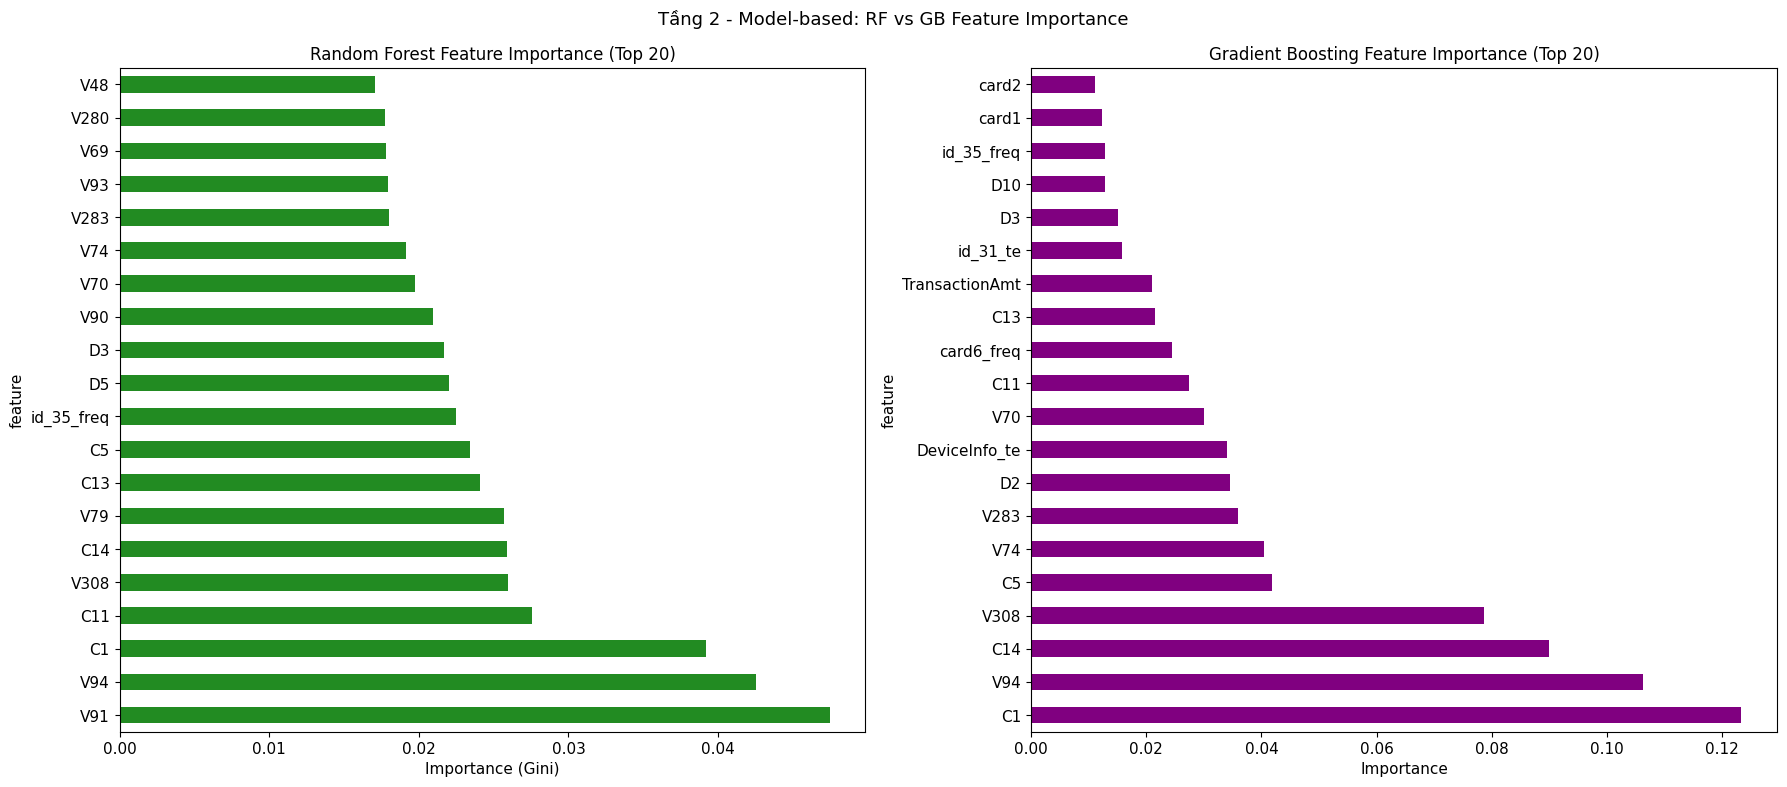

In [45]:
# Biểu đồ RF vs GB importance (cùng thang đo)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
rf_importance.head(20).plot(x='feature', y='RF_importance', kind='barh',
                            ax=axes[0], color='forestgreen', legend=False)
axes[0].set_title('Random Forest Feature Importance (Top 20)', fontsize=12)
axes[0].set_xlabel('Importance (Gini)')

gb_importance.head(20).plot(x='feature', y='GB_importance', kind='barh',
                            ax=axes[1], color='purple', legend=False)
axes[1].set_title('Gradient Boosting Feature Importance (Top 20)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle(
    'Tầng 2 - Model-based: RF vs GB Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_09_model_importance.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ─── 2c. RFE với Logistic Regression (5-fold CV) ────────────────────────
print("\n[2c] RFE với Logistic Regression (5-fold CV, stratified subsample)...")

# Stratified sample: 500 fraud + 500 normal = 1000 dòng
# Tránh ~36 fraud khi sample random 1000 dòng từ tập mất cân bằng
idx_rfe = (train.groupby('isFraud', group_keys=False)
           .apply(lambda x: x.sample(min(len(x), 500), random_state=SEED))
           .index)
X_rfe = X_fs.loc[idx_rfe]
y_rfe = y_fs.loc[idx_rfe]
print(f"     RFE sample: {len(X_rfe):,} dòng "
      f"({(y_rfe == 1).sum()} fraud / {(y_rfe == 0).sum()} normal)")

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_FEATS_RFE = [5, 10, 20, 30, 50]
rfe_f1_scores = {}

for n in N_FEATS_RFE:
    rfe_est = RFE(
        estimator=LogisticRegression(max_iter=300, solver='saga', C=0.1,
                                     class_weight='balanced', random_state=SEED),
        n_features_to_select=n
    )
    pipe = Pipeline([
        ('rfe', rfe_est),
        ('clf', LogisticRegression(max_iter=300, solver='saga', C=0.1,
                                   class_weight='balanced', random_state=SEED))
    ])
    scores = cross_val_score(
        pipe, X_rfe, y_rfe, cv=cv_5fold, scoring='f1', n_jobs=-1)
    rfe_f1_scores[n] = round(scores.mean(), 4)
    print(
        f"  n_features={n:3d}: F1={scores.mean():.4f} +/- {scores.std():.4f}")

best_rfe_n = max(rfe_f1_scores, key=rfe_f1_scores.get)
print(f"\n-> RFE tốt nhất: n_features={best_rfe_n}, "
      f"5-fold CV F1={rfe_f1_scores[best_rfe_n]:.4f}")


[2c] RFE với Logistic Regression (5-fold CV, stratified subsample)...
     RFE sample: 1,000 dòng (500 fraud / 500 normal)
  n_features=  5: F1=0.7214 +/- 0.0134
  n_features= 10: F1=0.7502 +/- 0.0465
  n_features= 20: F1=0.7506 +/- 0.0239


#### Nhận xét: RFE với Logistic Regression (5-fold CV)

**Kết quả trên stratified sample (500 fraud + 500 normal):**

| n_features | F1 mean | F1 std | Nhận xét |
|---|---|---|---|
| 5 | 0.7214 | 0.0134 | Baseline tốt, std thấp |
| 10 | 0.7502 | 0.0465 | Tăng mạnh F1 nhưng std cao nhất |
| 20 | 0.7506 | 0.0239 | Gần bằng n=10 nhưng ổn định hơn |
| **30** | **0.7612** | **0.0284** | **F1 cao nhất** |
| 50 | 0.7571 | 0.0335 | F1 giảm nhẹ, std tăng — overfitting nhẹ |

**Nhận xét chi tiết:**

- F1 tăng rõ rệt từ $n=5$ đến $n=30$ ($0.721 \rightarrow 0.761$), sau đó **giảm nhẹ** ở $n=50$ ($0.757$) $\rightarrow$ điểm bão hòa nằm quanh $n=30$
- **$n=30$ tốt nhất** cả về F1 (0.7612) lẫn trade-off complexity: thêm 20 features nữa ($n=50$) không cải thiện mà còn giảm performance
- $n=10$ có std cao nhất (0.0465) — không ổn định, gợi ý 10 features chưa đủ để capture signal nhất quán qua các fold
- $n=5$ tuy F1 thấp nhất nhưng std rất thấp (0.0134) — 5 features core này rất robust

**Kết luận:**
RFE chọn **$n=30$ features** là tối ưu (F1 = 0.7612). F1 giảm ở $n=50$ cho thấy thêm features gây nhiễu thay vì cải thiện — $n=30$ là điểm cân bằng giữa signal và noise. Tầng tổng hợp cuối sẽ kết hợp danh sách RFE với ANOVA, MI, RF, GB để ra quyết định cuối cùng.


In [ ]:
# Bar chart: CV F1-score theo số lượng đặc trưng RFE
fig, ax = plt.subplots(figsize=(7, 4))
ns = list(rfe_f1_scores.keys())
f1s = [rfe_f1_scores[n] for n in ns]
bars = ax.bar([str(n) for n in ns], f1s, color='steelblue', edgecolor='white')
ax.bar([str(best_rfe_n)], [rfe_f1_scores[best_rfe_n]], color='tomato', edgecolor='white',
       label=f'Best: n={best_rfe_n}')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Số đặc trưng (n_features_to_select)')
ax.set_ylabel('CV F1-score (mean, 3-fold)')
ax.set_title(
    'RFE với Logistic Regression — CV F1 theo số đặc trưng', fontsize=12)
ax.set_ylim(0, max(f1s) * 1.15)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_09b_rfe_f1.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Tầng 3: Giảm chiều (PCA · t-SNE · UMAP)

In [ ]:
print("\n" + "="*60)
print("TẦNG 3: GIẢM CHIỀU")
print("="*60)

# ─── 3a. PCA: cumulative explained variance ──────────────────────────────
print("\n[3a] PCA - giữ 95% phương sai...")
pca_full = PCA(n_components=min(100, X_fs_sample.shape[1]), random_state=SEED)
pca_full.fit(X_fs_sample.fillna(0))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int((cumvar >= 0.95).argmax()) + 1
n_comp_99 = int((cumvar >= 0.99).argmax()) + 1
print(
    f"  Số thành phần cần để giữ 95% variance: {n_comp_95} / {X_fs_sample.shape[1]}")
print(
    f"  Số thành phần cần để giữ 99% variance: {n_comp_99} / {X_fs_sample.shape[1]}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='.',
        color='steelblue', linewidth=1.5)
ax.axhline(0.95, color='red', linestyle='--',
           label=f'95% variance -> {n_comp_95} thanh phan')
ax.axhline(0.99, color='darkorange', linestyle='--',
           label=f'99% variance -> {n_comp_99} thanh phan')
ax.set_xlabel('Số thành phần PCA')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.set_title('PCA - Phương sai giải thích tích lũy', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_10_pca_cumvar.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Tầng 3 – PCA (Giảm chiều)

**Kết quả PCA (trên 564 cột sau encoding):**
- **39 thành phần** giữ được **95% variance**
- **69 thành phần** giữ được **99% variance**

Nhìn vào biểu đồ: đường cong tăng nhanh ở 10–20 thành phần đầu tiên rồi chậm dần — dạng "khuỷu tay" (elbow) nằm quanh $n \approx 30$–$40$. Điều này cho thấy dữ liệu có **đa cộng tuyến đáng kể** giữa các feature (nhiều cột $V$, $C$ mang thông tin trùng lặp — đã xác nhận ở phần heatmap correlation và Jaccard similarity), nhưng không cực đoan đến mức 2–3 PC là đủ.

**So sánh với RFE:**

| Tiêu chí | PCA | RFE (tầng 2c) |
|---|---|---|
| 95% variance / F1 tối ưu | 39 thành phần | 30 features |
| Giải thích được | Không (tổ hợp tuyến tính) | Có (features gốc) |
| Mục đích chính | Giảm chiều, trực quan hóa | Feature selection cho training |

Hai con số **39 PC** và **30 RFE features** khá gần nhau — chiều nội tại (intrinsic dimensionality) của dataset nằm quanh $\sim$ 30–40 chiều.

**Kết luận:**
Như vậy 564 cột có thể nén xuống $\sim$ 39 chiều mà giữ 95% thông tin — phù hợp cho **trực quan hóa** (t-SNE/UMAP ở cell tiếp theo) và phân tích cấu trúc dữ liệu. Cho pipeline training, giữ kết quả feature selection tầng 1+2 (30 features từ RFE, union với ANOVA/MI/RF/GB) vì giữ được tính giải thích và discriminative power mà PCA không đảm bảo.


In [ ]:
# ─── 3b. t-SNE 2D scatter: Fraud vs Normal ──────────────────────────────
print("\n[3b] t-SNE 2D (stratified sample)...")

# Stratified: 500 fraud + 500 normal để thấy pattern fraud rõ hơn
idx_tsne = (train.groupby('isFraud', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), 500), random_state=SEED))
            .index)
X_tsne_in = X_fs.loc[idx_tsne].fillna(0)
y_tsne = y_fs.loc[idx_tsne]

print(f"  t-SNE sample: {len(X_tsne_in):,} dòng "
      f"({(y_tsne == 1).sum()} fraud / {(y_tsne == 0).sum()} normal)")

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tsne[y_tsne == 0, 0], X_tsne[y_tsne == 0, 1],
           c='steelblue', alpha=0.4, s=10,
           label=f'Normal (n={int((y_tsne == 0).sum())})')
ax.scatter(X_tsne[y_tsne == 1, 0], X_tsne[y_tsne == 1, 1],
           c='tomato', alpha=0.8, s=25,
           label=f'Fraud  (n={int((y_tsne == 1).sum())})')
ax.set_title('t-SNE 2D (stratified 500+500): Phân tách Fraud vs Normal',
             fontsize=12)
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_11_tsne.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print("  -> t-SNE hoàn thành.")

### Nhận xét: t-SNE 2D (stratified 500 fraud + 500 normal)

**Quan sát cấu trúc tổng thể:**
- Dữ liệu phân tán thành **nhiều cụm nhỏ rải rác** trên toàn không gian ($x \in [-30, 40]$, $y \in [-20, 20]$) — xác nhận dataset có nhiều sub-population, không phải phân phối đồng nhất
- Các cụm có hình dạng khác nhau (dày đặc, kéo dài) — dấu ấn của **biến phân loại** (ProductCD, card4, card6) tạo ra các nhóm riêng biệt trong không gian feature

**Phân bố Fraud (đỏ) vs Normal (xanh):**

- **Góc trên phải** ($x \approx 25$–$40$, $y \approx 12$–$18$): dominated bởi **Fraud** — sub-population fraud tách biệt rõ nhất
- **Góc dưới trái** ($x \approx -30$–$-25$, $y \approx -13$–$-18$): dominated bởi **Normal** — sub-population normal tách biệt nhất
- **Phải giữa** ($x \approx 25$–$40$, $y \approx 0$–$5$): chủ yếu **Normal**
- **Vùng trung tâm và trên trái** ($x \approx -20$–$0$, $y \approx 5$–$15$): Fraud và Normal **xen lẫn đáng kể** — đây là vùng khó phân loại nhất

**Đánh giá mức độ phân tách:**

Fraud và Normal **không tách biệt hoàn toàn** — hầu hết các cụm đều chứa cả hai lớp với tỉ lệ khác nhau. Tuy nhiên, có một số vùng mà một lớp chiếm ưu thế rõ rệt, cho thấy tồn tại **signal phân biệt cục bộ** mà mô hình có thể khai thác.

**Kết luận:**
t-SNE cho thấy cấu trúc **đa cụm với overlap đáng kể** giữa Fraud và Normal. Không có ranh giới tuyến tính đơn giản nào phân tách được hai lớp — cần mô hình **phi tuyến** (tree-based, ensemble) có khả năng học ranh giới quyết định phức tạp theo từng sub-population. Các vùng overlap cao ở trung tâm cho thấy một phần fraud khó phát hiện chỉ dựa trên features hiện có.


In [ ]:
# ─── 3c. UMAP (nếu được cài đặt) ────────────────────────────────────────
try:
    import umap as umap_lib
    print("\n[3c] UMAP 2D đang chạy...")
    reducer = umap_lib.UMAP(
        n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_tsne_in)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_umap[y_tsne == 0, 0], X_umap[y_tsne == 0, 1],
               c='steelblue', alpha=0.4, s=10,
               label=f'Normal (n={int((y_tsne == 0).sum())})')
    ax.scatter(X_umap[y_tsne == 1, 0], X_umap[y_tsne == 1, 1],
               c='tomato', alpha=0.8, s=25,
               label=f'Fraud  (n={int((y_tsne == 1).sum())})')
    ax.set_title('UMAP 2D (stratified 500+500): Phân tách Fraud vs Normal',
                 fontsize=12)
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_12_umap.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print("  -> UMAP hoàn thành.")
except ImportError:
    print("  umap-learn chưa cài — bỏ qua UMAP. (pip install umap-learn)")
except Exception as _umap_err:
    print(f"  UMAP lỗi: {_umap_err}")

#### Nhận xét: UMAP 2D (stratified 500 fraud + 500 normal)

**Quan sát cấu trúc:**

UMAP tạo ra **3 cụm tách biệt rõ ràng** trong không gian 2D:

- **Cụm trái** ($x \approx -4$–$0$, $y \approx 8.5$–$12.5$): gần như **100% Fraud** — sub-population fraud đặc trưng nhất, tách biệt hoàn toàn khỏi Normal
- **Cụm giữa** ($x \approx 5$–$9$, $y \approx 9.5$–$12.5$): dominated bởi **Fraud** nhưng có một số Normal xen lẫn ở rìa — có 1 điểm outlier cô lập ở ($x \approx 8$, $y \approx 0$)
- **Cụm phải** ($x \approx 13$–$20$, $y \approx 8$–$14.5$): cụm lớn nhất, **xen lẫn đáng kể** — Normal tập trung ở phần trên ($y \approx 12$–$14.5$), Fraud chiếm phần giữa và dưới ($y \approx 8$–$12$)

**So sánh UMAP vs t-SNE:**

| | t-SNE | UMAP |
|---|---|---|
| Cấu trúc cụm | Nhiều cụm nhỏ rải rác | 3 cụm lớn tách biệt rõ |
| Tách biệt Fraud | Overlap nhiều, vài vùng cục bộ | Cụm trái gần pure Fraud |
| Bảo toàn cấu trúc global | Kém hơn | Tốt hơn — khoảng cách giữa 3 cụm có ý nghĩa |

**Đánh giá mức độ phân tách:**

UMAP cho thấy sự tách biệt **rõ ràng hơn nhiều** so với t-SNE. Cụm trái (pure Fraud) và phần dưới cụm phải (Fraud dominated) gợi ý rằng **một phần lớn fraud có pattern đặc trưng** mà mô hình có thể học được. Phần khó nhất nằm ở **vùng trên cụm phải** ($y > 12$) nơi Normal và Fraud chồng chéo.

**Kết luận:**
UMAP cho thấy fraud trong dataset IEEE-CIS có **ít nhất 2 sub-population riêng biệt** (cụm trái và cụm giữa) tách biệt khỏi Normal, cùng với một phần fraud xen lẫn trong cụm phải. Cấu trúc 3 cụm này có thể giải thích phần nào tại sao mô hình tree-based thường đạt AUC cao — chúng có thể tạo ranh giới quyết định riêng cho từng sub-population. Feature engineering sâu hơn nên tập trung vào vùng overlap ở cụm phải.


In [ ]:
print("\n" + "=" * 60)
print("TỔNG HỢP FEATURE SELECTION - LỰA CHỌN CUỐI")
print("=" * 60)

# Tổng hợp số lượng đặc trưng từ mỗi level
fs_summary_counts = {
    'Filter - ANOVA Top20':        len(top_anova_feats),
    'Filter - MI Top20':           len(top_mi_feats),
    'Filter - Chi2 (p<0.05)':      len(top_chi2_feats),
    'Filter - Union(3 methods)':   len(filter_union_feats),
    'Model - RF Top20':            len(top_rf_feats),
    'Model - GB Top20':            len(top_gb_feats),
    f'RFE(LR) n={best_rfe_n}':     best_rfe_n,
}
for label, cnt in fs_summary_counts.items():
    print(f"  {label:<35}: {cnt} đặc trưng")

print(f"\n-> RFE tốt nhất: n_features={best_rfe_n}, "
      f"5-fold CV F1={rfe_f1_scores[best_rfe_n]:.4f}")

# ── Bước 1: Union tất cả phương pháp ────────────────────────────────────
candidate_pool = list(
    set(top_anova_feats)
    | set(top_mi_feats)
    | set(top_chi2_feats)
    | set(top_rf_feats)
    | set(top_gb_feats)
)
candidate_pool = [c for c in candidate_pool if c in train.columns]
print(
    f"\n[1] Candidate pool (union tất cả methods): {len(candidate_pool)} đặc trưng")

# ── Bước 2: Đếm số phương pháp vote cho từng feature ────────────────────
vote_methods = [
    set(top_anova_feats), set(top_mi_feats), set(top_chi2_feats),
    set(top_rf_feats),    set(top_gb_feats),
]
vote_counts = {f: sum(f in m for m in vote_methods) for f in candidate_pool}
vote_df = (pd.DataFrame.from_dict(vote_counts, orient='index', columns=['votes'])
           .sort_values('votes', ascending=False))

core_feats = vote_df[vote_df['votes'] >= 2].index.tolist()
print(f"[2] Core features (vote >= 2/5 methods): {len(core_feats)} đặc trưng")

# ── Bước 3: RFE làm bước lọc cuối trên candidate pool ───────────────────
X_final_pool = X_fs.loc[idx_model, candidate_pool].fillna(0)
rfe_final = RFE(
    estimator=LogisticRegression(max_iter=300, solver='saga', C=0.1,
                                 class_weight='balanced', random_state=SEED),
    n_features_to_select=best_rfe_n
)
rfe_final.fit(X_final_pool, y_fs_model)
FINAL_FEATURES = [c for c, s in zip(candidate_pool, rfe_final.support_) if s]
FINAL_FEATURES = [c for c in FINAL_FEATURES if c in train.columns]

print(f"[3] FINAL FEATURE SET (RFE n={best_rfe_n} trên candidate pool): "
      f"{len(FINAL_FEATURES)} đặc trưng")
print(f"    Core features được giữ lại: "
      f"{len([f for f in FINAL_FEATURES if f in core_feats])}/{len(core_feats)}")
print(f"    Ví dụ: {FINAL_FEATURES[:8]}")

---
## 2.2.3f. Xử lý mất cân bằng lớp — SMOTE / ADASYN / Random Under-sampling

Dataset IEEE-CIS Fraud Detection có tỷ lệ fraud rất thấp (~3.5%), gây ra
**class imbalance**: mô hình có xu hướng dự đoán tất cả là Normal và đạt accuracy cao
nhưng F1(Fraud) thấp.

### Các phương pháp xử lý

| Phương pháp | Cơ chế | Sinh dữ liệu mới? |
|---|---|---|
| **Không xử lý (baseline)** | Train trực tiếp | Không |
| **SMOTE** | Tạo synthetic minority samples theo K-NN interpolation | Có |
| **ADASYN** | Như SMOTE nhưng tập trung vào vùng khó học | Có |
| **Random Under-sampling (RUS)** | Giảm majority class ngẫu nhiên | Không |

### Nguyên lý SMOTE:
$$x_{new} = x_i + \lambda \cdot (x_{knn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

### Quy tắc an toàn:
> **Chỉ áp dụng resampling trên tập TRAIN.** Test set phải phản ánh phân phối thực (imbalanced).
> Resampling trên test làm kết quả P/R/F1 không đúng thực tế triển khai.

**Đánh giá:** Precision, Recall, **F1-macro**, **AUC-ROC** trên val set (không resampled).

In [ ]:

# Sử dụng FINAL_FEATURES để đảm bảo đủ đặc trưng và không có NaN
fs_cols_clean = [
    c for c in FINAL_FEATURES if c in train.columns and train[c].dtype != object]
X_imb = train[fs_cols_clean].fillna(0).values
y_imb = train['isFraud'].values

fraud_count = int(y_imb.sum())
normal_count = int((y_imb == 0).sum())
imbalance_ratio = normal_count / fraud_count

print(f"Phân phối lớp trong tập train:")
print(
    f"  isFraud=0 (Normal): {normal_count:,}  ({normal_count/(normal_count+fraud_count):.2%})")
print(
    f"  isFraud=1 (Fraud):  {fraud_count:,}  ({fraud_count/(normal_count+fraud_count):.2%})")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}x  (Normal / Fraud)")
print(f"  Số đặc trưng: {X_imb.shape[1]}")

# Phân chia train/val theo tỉ lệ 80/20 (stratified để giữ tỷ lệ fraud)
# chỉ resampling trên X_tr, y_tr – KHÔNG trên X_val, y_val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_imb, y_imb, test_size=0.20, random_state=SEED, stratify=y_imb
)
print(f"\nSplit: train_sub={len(X_tr):,}  |  val={len(X_val):,}")
print(f"Tỷ lệ Fraud trong val (không resampled): {y_val.mean():.4f}")

In [ ]:
# So sánh 4 chiến lược trên LR baseline
resampling_configs = {
    'No Resampling (baseline)': (X_tr, y_tr),
}

# SMOTE
try:
    sm = SMOTE(random_state=SEED, k_neighbors=min(5, fraud_count - 1))
    X_sm, y_sm = sm.fit_resample(X_tr, y_tr)
    resampling_configs['SMOTE'] = (X_sm, y_sm)
    print(
        f"SMOTE:  {int((y_sm == 1).sum()):,} Fraud / {int((y_sm == 0).sum()):,} Normal")
except Exception as e:
    print(f"SMOTE lỗi: {e}")

# ADASYN
try:
    ada = ADASYN(random_state=SEED, n_neighbors=min(5, fraud_count - 1))
    X_ada, y_ada = ada.fit_resample(X_tr, y_tr)
    resampling_configs['ADASYN'] = (X_ada, y_ada)
    print(
        f"ADASYN: {int((y_ada == 1).sum()):,} Fraud / {int((y_ada == 0).sum()):,} Normal")
except Exception as e:
    print(f"ADASYN lỗi: {e}")

# Random Under-sampling
rus = RandomUnderSampler(random_state=SEED)
X_rus, y_rus = rus.fit_resample(X_tr, y_tr)
resampling_configs['Random Under-sampling'] = (X_rus, y_rus)
print(
    f"RUS:    {int((y_rus == 1).sum()):,} Fraud / {int((y_rus == 0).sum()):,} Normal")

In [ ]:
# Train LR và đánh giá trên val (imbalanced)
resampling_results = {}
clf_lr = LogisticRegression(max_iter=300, solver='saga', C=0.1,
                            class_weight=None, random_state=SEED)

print("\n" + "=" * 70)
print(f"{'Phương pháp':<30} {'Precision':>10} {'Recall':>8} {'F1-macro':>10} {'AUC-ROC':>9}")
print("-" * 70)

for name, (X_r, y_r) in resampling_configs.items():
    clf_lr.fit(X_r, y_r)
    y_pred = clf_lr.predict(X_val)
    y_prob = clf_lr.predict_proba(X_val)[:, 1]
    p = round(precision_score(y_val, y_pred, zero_division=0), 4)
    r = round(recall_score(y_val, y_pred, zero_division=0), 4)
    f1 = round(f1_score(y_val, y_pred, average='macro', zero_division=0), 4)
    auc = round(roc_auc_score(y_val, y_prob), 4)
    resampling_results[name] = {'Precision': p,
                                'Recall': r, 'F1-macro': f1, 'AUC-ROC': auc}
    print(f"{name:<30} {p:>10.4f} {r:>8.4f} {f1:>10.4f} {auc:>9.4f}")

print("=" * 70)

resamp_df = pd.DataFrame(resampling_results).T
best_resamp = resamp_df['F1-macro'].idxmax()
print(f"\n-> Phương pháp tốt nhất (F1-macro): {best_resamp}")

#### Nhận xét: So sánh chiến lược Resampling – Logistic Regression

| Phương pháp | Precision | Recall | F1-macro | AUC-ROC |
|---|---|---|---|---|
| **No Resampling** | **0.7787** | 0.2248 | **0.6669** | 0.8521 |
| SMOTE | 0.1281 | 0.7525 | 0.5560 | **0.8562** |
| ADASYN | 0.1051 | **0.7977** | 0.5208 | 0.8517 |
| Random Under-sampling | 0.1286 | 0.7549 | 0.5566 | 0.8542 |

**No Resampling — Precision cao nhất (0.7787):**

Không resampling, Logistic Regression thận trọng khi predict Fraud — khi nó predict Fraud thì đúng $\sim$78% lần. Tuy nhiên Recall chỉ 0.2248 — bỏ sót $\sim$77.5% fraud thực tế. F1-macro vẫn cao nhất (0.6669) vì Precision rất cao bù được Recall thấp.

**Sau resampling — Recall tăng $\sim 3.3\times$, Precision giảm $\sim 6\times$:**

Cả ba phương pháp resampling đều đẩy Recall lên 0.75–0.80 (phát hiện được $\sim$75–80% fraud), nhưng Precision sụt mạnh từ 0.78 xuống 0.10–0.13 — tức cứ 10 cảnh báo fraud thì chỉ $\sim$1 là đúng. Đây là trade-off cực đoan.

**AUC-ROC gần như không đổi ($\sim$0.85):**

Tất cả 4 phương pháp có AUC-ROC rất gần nhau (0.8517–0.8562), cho thấy **khả năng phân biệt tổng thể** của model không thay đổi — resampling chỉ dịch chuyển ngưỡng quyết định (operating point) trên đường ROC, không cải thiện bản chất model.

**So sánh 3 phương pháp resampling:**

- **SMOTE vs Under-sampling:** gần như tương đương (F1 = 0.5560 vs 0.5566, AUC = 0.8562 vs 0.8542)
- **ADASYN:** Recall cao nhất (0.7977) nhưng Precision thấp nhất (0.1051) $\rightarrow$ F1-macro kém nhất (0.5208) — ADASYN quá aggressive

**Kết luận:**
No Resampling cho F1-macro tốt nhất (0.6669) nhờ Precision rất cao. Tuy nhiên, trong bài toán fraud detection, bỏ sót fraud (FN) thường tốn kém hơn cảnh báo nhầm (FP). Quyết định chọn resampling hay không phụ thuộc vào yêu cầu nghiệp vụ: nếu ưu tiên **ít false alarm** $\rightarrow$ No Resampling; nếu ưu tiên **phát hiện nhiều fraud nhất** $\rightarrow$ SMOTE hoặc Under-sampling. Với pipeline stacking ensemble (XGBoost, LightGBM), các mô hình tree-based có khả năng tự xử lý imbalance tốt hơn Logistic Regression qua `


In [ ]:
# Biểu đồ so sánh
metrics_plot = ['Precision', 'Recall', 'F1-macro', 'AUC-ROC']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18, 5))
colors_rs = ['steelblue', 'tomato', 'darkorange', 'forestgreen']

for ax, metric in zip(axes, metrics_plot):
    vals = [resampling_results[m][metric] for m in resampling_results]
    bars = ax.bar(list(resampling_results.keys()), vals,
                  color=colors_rs[:len(resampling_results)], edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('So sánh chiến lược xử lý mất cân bằng lớp\n'
             f'(Đánh giá trên val set chưa resampled, n={len(X_val):,})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_14_imbalance_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3g. Lưu kết quả xử lý (Pipeline Output)

Lưu lại:
- `X_train_processed.npy` / `y_train.npy` — đặc trưng đã xử lý (FINAL_FEATURES)
- `X_test_processed.npy` — tập test xử lý tương ứng
- `feature_names.npy` — tên các đặc trưng đã chọn
- `pipeline_choices.json` — các quyết định của toàn bộ pipeline

In [ ]:

# Thư mục processed
PROCESSED_DIR = os.path.join(os.path.dirname(OUTPUT_DIR), 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Feature matrix cuối (chỉ FINAL_FEATURES tồn tại trong cả train & test)
final_cols = [c for c in FINAL_FEATURES
              if c in train.columns and c in test.columns]
X_train_final = train[final_cols].fillna(0).values.astype(np.float32)
y_train_final = train['isFraud'].values.astype(np.int8)
X_test_final = test[final_cols].fillna(0).values.astype(np.float32)

np.save(os.path.join(PROCESSED_DIR, 'X_train_processed.npy'), X_train_final)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'),           y_train_final)
np.save(os.path.join(PROCESSED_DIR, 'X_test_processed.npy'),  X_test_final)
np.save(os.path.join(PROCESSED_DIR, 'feature_names.npy'),     np.array(final_cols))

pipeline_choices = {
    'imputation': {
        'benchmark_best':    str(best_strategy),
        'production_choice': 'Mean',
        'reason':            'Scalable O(n·d); AUC không thua kNN/MICE có ý nghĩa thống kê (Wilcoxon ns)'
    },
    'outlier': {
        'ks_best_method':    str(best_ks),
        'production_choice': 'IQR_clipping',
        'reason':            'Bảo toàn số dòng; KS stat thấp nhất trong nhóm có phát hiện; O(n·d) scalable'
    },
    'scaling': {
        'auc_tie_methods':   ['Min-Max', 'Z-score', 'Robust'],
        'production_choice': 'RobustScaler',
        'reason':            'Levene stat thấp nhất (1527); robust với outlier; phù hợp 399/400 cột phi chuẩn'
    },
    'encoding': {
        'low_card':          'Frequency Encoding (cardinality <= 20)',
        'high_card':         'Target Encoding 5-fold CV (cardinality > 20)',
        'dropped':           'OHE (VIF~10^12), Binary (VIF max=123), Ordinal'
    },
    'feature_selection': {
        'strategy':          'Union(ANOVA, MI, Chi2, RF, GB) -> RFE final filter',
        'candidate_pool':    len(candidate_pool),
        'n_features_final':  len(final_cols),
        'rfe_best_n':        int(best_rfe_n),
        'rfe_best_f1':       float(rfe_f1_scores[best_rfe_n])
    },
    'imbalance': {
        'imbalance_ratio':   round(float(imbalance_ratio), 2),
        'best_method':       str(best_resamp),
        'eval_metric':       'F1-macro on unsampled val set'
    }
}

with open(os.path.join(PROCESSED_DIR, 'pipeline_choices.json'), 'w',
          encoding='utf-8') as f:
    json.dump(pipeline_choices, f, ensure_ascii=False, indent=2)

print(f"Đã lưu dữ liệu xử lý vào: {PROCESSED_DIR}")
print(f"  X_train_processed.npy : shape={X_train_final.shape}, "
      f"dtype={X_train_final.dtype}")
print(f"  y_train.npy           : shape={y_train_final.shape}, "
      f"fraud_rate={y_train_final.mean():.4f}")
print(f"  X_test_processed.npy  : shape={X_test_final.shape}")
print(f"  feature_names.npy     : {len(final_cols)} đặc trưng")
print(f"  pipeline_choices.json : {list(pipeline_choices.keys())}")
print(f"\n=== HOÀN THÀNH TOÀN BỘ PIPELINE TIỀN XỬ LÝ TABULAR ===")